<a href="https://colab.research.google.com/github/youma-code/qqq/blob/main/%E9%96%8B%E7%99%BA1.8.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import numpy as np
import pandas as pd
import yfinance as yf
import time

# ======================
# データ取得
# ======================
ticker = "SOXX"
start_date = "2020-01-01"
end_date = pd.to_datetime("today").strftime("%Y-%m-%d")

def download_data(ticker, start, end):
    for _ in range(5):
        df = yf.download(ticker, start=start, end=end)
        if not df.empty:
            return df
        time.sleep(3)
    return pd.DataFrame()

df = download_data(ticker, start_date, end_date)

# ======================
# 整形
# ======================
if isinstance(df.columns, pd.MultiIndex):
    df = df[['Close', 'High', 'Low', 'Volume']].droplevel(1, axis=1)
else:
    df = df[['Close', 'High', 'Low', 'Volume']].copy()

df.columns = ['Close', 'High', 'Low', 'Volume']
df.dropna(inplace=True)

# ======================
# 特徴量作成（強化版）
# ======================

# --- SMA系 ---
df["SMA_5"] = df["Close"].rolling(5).mean()
df["SMA_25"] = df["Close"].rolling(25).mean()
df["SMA_50"] = df["Close"].rolling(50).mean()
df["SMA_200"] = df["Close"].rolling(200).mean()
df["SMA_diff_pct"] = (df["SMA_5"] - df["SMA_25"]) / df["SMA_25"]
df["SMA_50_200_pct"] = (df["SMA_50"] - df["SMA_200"]) / df["SMA_200"]

# --- Target ---
future_return = df["Close"].shift(-10) / df["Close"] - 1
df["Target"] = (future_return > 0.03).astype(int)

# --- RSI ---
delta = df["Close"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / (loss + 1e-9)
df["RSI"] = 100 - (100 / (1 + rs))

# --- MACD ---
ema12 = df["Close"].ewm(span=12).mean()
ema26 = df["Close"].ewm(span=26).mean()
df["MACD"] = ema12 - ema26
df["Signal_Line"] = df["MACD"].ewm(span=9).mean()
df["MACD_Hist"] = df["MACD"] - df["Signal_Line"]

# --- ボラ・リターン ---
df["Daily_Return"] = df["Close"].pct_change()
df["Volatility_Short"] = df["Daily_Return"].rolling(5).std()
# --- Volatility Expansion Ratio ---
df["Volatility_Expansion_Ratio"] = df["Daily_Return"].rolling(5).std() / df["Daily_Return"].rolling(window=20, min_periods=1).mean()

# --- ATR ---
tr = pd.concat([
    df["High"] - df["Low"],
    abs(df["High"] - df["Close"].shift()),
    abs(df["Low"] - df["Close"].shift())
], axis=1).max(axis=1)

df["ATR"] = tr.rolling(14).mean()

# ======================
# 🔥追加強化特徴量
# ======================
df["MOMENTUM_pct"] = df["Close"].pct_change(5)
df["RETURN_1"] = df["Close"].pct_change(1)

# ボラ構造
df["VOL_10"] = df["Daily_Return"].rolling(10).std()
df["VOL_20"] = df["Daily_Return"].rolling(20).std()
df["VOL_RATIO"] = df["VOL_10"] / (df["VOL_20"] + 1e-9)

# レンジ度
df["RANGE_SCORE"] = abs(df["RSI"] - 50)

# ======================
# cleanup
# ======================
df = df.dropna()

# ======================
# ADX（ここが重要）
# ======================
window = 14

plus_dm = df["High"].diff()
minus_dm = -df["Low"].diff()

plus_dm = plus_dm.clip(lower=0)
minus_dm = minus_dm.clip(lower=0)

tr = pd.concat([
    df["High"] - df["Low"],
    (df["High"] - df["Close"].shift()).abs(),
    (df["Low"] - df["Close"].shift()).abs()
], axis=1).max(axis=1)

atr = tr.rolling(window).mean()

plus_di = 100 * (plus_dm.rolling(window).mean() / (atr + 1e-9))
minus_di = 100 * (minus_dm.rolling(window).mean() / (atr + 1e-9))

dx = (abs(plus_di - minus_di) / (plus_di + minus_di + 1e-9)) * 100

df["ADX"] = dx.rolling(window).mean()

# ======================
# 追加特徴量（ADX後にやる！）
# ======================
# ★ここで初めて作る
df["TREND_STRENGTH"] = df["ADX"] * df["MACD_Hist"]

# --- BB ---
ma = df["Close"].rolling(20).mean()
std = df["Close"].rolling(20).std()

df["Upper_BB"] = ma + 2 * std
df["Lower_BB"] = ma - 2 * std
df["BB_Width"] = (df["Upper_BB"] - df["Lower_BB"]) / (ma + 1e-9)

# --- lag ---
for lag in range(1, 6):
    df[f"Close_Lag_{lag}"] = df["Close"].shift(lag)

# ======================
# 🔥新規追加: レジーム分離と正規化ADX、市場レジーム
# ======================
regime_score = df["SMA_diff_pct"].abs() * df["ADX"] / 100

df["market_regime"] = np.where(
    regime_score > 0.02, "uptrend",
    np.where(regime_score < 0.01, "sideways", "downtrend")
)

# ======================
# Add conditional variables for market regimes
# ======================
df['cond_sideways'] = (df['market_regime'] == 'sideways')
df['cond_uptrend'] = (df['market_regime'] == 'uptrend')
df['cond_downtrend'] = (df['market_regime'] == 'downtrend')

# ======================
# Market Regime One-Hot Encoding
# ======================
df = pd.get_dummies(df, columns=["market_regime"])

# cleanup
df.dropna(inplace=True)

print("完了:", df.shape)

# ======================
# Verification Print Statements
# ======================
print("\nMarket Regime Distribution:")
display(df[['market_regime_uptrend', 'market_regime_downtrend', 'market_regime_sideways']].sum().rename('Count'))

print("\nLast 20 entries of market regime and Close price:")
display(df.tail(20)[[
    'market_regime_uptrend',
    'market_regime_downtrend',
    'market_regime_sideways',
    'Close'
]])

print("\n===== Calculation of SMA_diff_pct ====")
print("df[\"SMA_diff_pct\"] = (df[\"SMA_5\"] - df[\"SMA_25\"]) / df[\"SMA_25\"]")
print("\n===== Calculation of MOMENTUM_pct ====")
print("df[\"MOMENTUM_pct\"] = df[\"Close"].pct_change(5)")

SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' (1660417729.py, line 186)

In [2]:
def apply_adx_filter(adx, regime):
    if regime == "uptrend":
        return adx >= 35
    elif regime == "downtrend":
        return adx >= 25
    elif regime == "sideways":
        return adx <= 20
    return True

In [3]:
# ======================
# 特徴量リスト（固定）
# ======================

features = [
    'SMA_5', 'SMA_25', 'SMA_diff_pct', 'SMA_50_200_pct', # Added: SMA_diff_abs to features
    'RSI', 'MACD', 'Signal_Line', 'MACD_Hist',
    'ATR',
    'Upper_BB', 'Lower_BB', 'BB_Width',
    'Volatility_Short',
    'Volatility_Expansion_Ratio', # Added feature
    'ADX',
    'MOMENTUM_pct', 'RETURN_1',
    'TREND_STRENGTH'
]
# ラグ特徴量（セル1で作ったやつに対応）
for lag in range(1, 6):
    features.append(f'Close_Lag_{lag}')

# 存在しない列があったら弾く（安全対策）
if 'df' not in globals():
    print("エラー: DataFrame 'df' が定義されていません。このセルを実行する前に、データをロードしてdfを作成する前のセルを実行してください。")
    raise NameError("DataFrame 'df' is not defined. Please run the data preparation cells above.")

# NOTE: Market_Regime will be one-hot encoded later on the full df.
# The encoded columns will be added to the features list dynamically.

features = [f for f in features if f in df.columns]

print("使用特徴量数:", len(features))
print(features[:10])

使用特徴量数: 23
['SMA_5', 'SMA_25', 'SMA_diff_pct', 'SMA_50_200_pct', 'RSI', 'MACD', 'Signal_Line', 'MACD_Hist', 'ATR', 'Upper_BB']


In [4]:
import pandas as pd

# ======================
# X, y 作成
# ======================

# 念のためチェック
assert 'Target' in df.columns, "Target列が存在しません"

# Market_Regime はすでに前のセルでワンホットエンコーディング済み
df_encoded = df.copy() # df_encoded は df と同じデータフレームを指す

# --- START: Explicit check and addition for Volatility_Expansion_Ratio to df_encoded ---
# Ensure df_encoded explicitly contains 'Volatility_Expansion_Ratio' if df has it but df_encoded somehow lost it.
if "Volatility_Expansion_Ratio" in df.columns and "Volatility_Expansion_Ratio" not in df_encoded.columns:
    df_encoded["Volatility_Expansion_Ratio"] = df["Volatility_Expansion_Ratio"]
# --- END: Explicit check and addition for Volatility_Expansion_Ratio to df_encoded ---

# --- START: Explicit check and addition for SMA_diff_abs to df_encoded ---
# Ensure df_encoded explicitly contains 'SMA_diff_abs' if df has it but df_encoded somehow lost it.
if "SMA_diff_abs" in df.columns and "SMA_diff_abs" not in df_encoded.columns:
    df_encoded["SMA_diff_abs"] = df["SMA_diff_abs"]
# --- END: Explicit check and addition for SMA_diff_abs to df_encoded ---

# One-hot encodedされたMarket_Regimeの列名を動的に取得
# ユーザーのリクエストに従い、すべてのMarket_Regime関連列を取得する
encoded_market_regime_cols = [col for col in df_encoded.columns if col.startswith('market_regime_')]

# ② feature_columnsは既存の特徴量とエンコードされたMarket_Regimeの列を結合
# Ensure 'Volatility_Expansion_Ratio' is in features for final_features construction
# The 'features' list is expected to be a global variable from an earlier cell.
if 'Volatility_Expansion_Ratio' in df_encoded.columns and 'Volatility_Expansion_Ratio' not in features:
    features.append('Volatility_Expansion_Ratio')

# Ensure 'SMA_diff_abs' is in features for final_features construction
# The 'features' list is expected to be a global variable from an earlier cell.
if 'SMA_diff_abs' in df_encoded.columns and 'SMA_diff_abs' not in features:
    features.append('SMA_diff_abs')

final_features = features + encoded_market_regime_cols

# Xとyをこのエンコード済みデータから作る
X = df_encoded[final_features].copy()
y = df_encoded['Target'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target分布:")
print(y.value_counts(normalize=True))

X shape: (1397, 27)
y shape: (1397,)
Target分布:
Target
0    0.619184
1    0.380816
Name: proportion, dtype: float64


In [5]:
def detect_regime(df_slice, strategy_params):
    """
    DataFrameスライスと戦略パラメータに基づいて市場レジームを検出します。

    Args:
        df_slice (pd.DataFrame): ADX, SMA_50, SMA_200, SMA_diff_abs を含むDataFrameスライス。
        strategy_params (dict): adx_sideways_th, trend_strength_sideways_th を含む戦略パラメータ辞書。

    Returns:
        pd.Series: 各インデックスに対応する市場レジーム（'uptrend', 'downtrend', 'sideways'）。
    """
    adx_series = df_slice["ADX"]
    sma_50_series = df_slice["SMA_50"]
    sma_200_series = df_slice["SMA_200"]
    # sma_diff_abs_series = df_slice["SMA_diff_abs"] # This is no longer used for cond_sideways
    trend_strength_series = df_slice["TREND_STRENGTH"]

    market_regime_str = pd.Series('', index=df_slice.index)

    # レンジ相場条件
    cond_sideways = trend_strength_series < strategy_params['trend_strength_sideways_th']

    market_regime_str.loc[cond_sideways] = 'sideways'

    # レンジ相場ではない期間について、上昇トレンドと下降トレンドを判定
    # (sma_50_series > sma_200_series) が True の場合は uptrend、そうでない場合は downtrend
    cond_uptrend = ~cond_sideways & (sma_50_series > sma_200_series)
    market_regime_str.loc[cond_uptrend] = 'uptrend'

    cond_downtrend = ~cond_sideways & (sma_50_series <= sma_200_series)
    market_regime_str.loc[cond_downtrend] = 'downtrend'

    return market_regime_str

In [6]:
# This cell is superseded by the logic in cauDYW8ZZ2xR, where X and y are created
# from the one-hot encoded DataFrame (df_encoded) using final_features.
# Leaving this as a placeholder to indicate it's no longer used.
# Original content:
X = df[features]
y = df['Target']
print(f"X and y defined. Feature matrix shape: {X.shape}")

X and y defined. Feature matrix shape: (1397, 24)


In [7]:
# ==========================================
# アブレーションテスト用機能フラグ
# ==========================================
# ① レジーム別サイズ調整（Bullで大きく、Bearで小さく）False
ENABLE_REGIME_SIZING = True

# ② レジーム別エントリー閾値（Bullは閾値低め、Bearは厳格化）
ENABLE_REGIME_THRESHOLD = False

# ③ Alpha重視の評価関数（Buy&Holdリターンに対する超過リターンを最大化）
ENABLE_ALPHA_SCORING = False

print(f"--- 適用中の機能 ---")
print(f"REGIME_SIZING   : {ENABLE_REGIME_SIZING}")
print(f"REGIME_THRESHOLD: {ENABLE_REGIME_THRESHOLD}")
print(f"ALPHA_SCORING   : {ENABLE_ALPHA_SCORING}")

--- 適用中の機能 ---
REGIME_SIZING   : True
REGIME_THRESHOLD: False
ALPHA_SCORING   : False


In [8]:
import numpy as np
import pandas as pd

def apply_adx_filter(adx_value, regime):
    if regime == "uptrend":
        return adx_value >= 35
    elif regime == "downtrend":
        return adx_value >= 25
    elif regime == "sideways":
        return adx_value <= 20
    return True

def run_backtest(
    df, X_test, signal_multipliers,
    df_trade_info,
    initial_balance=100000,
    atr_sl_multiplier_uptrend=1.2, atr_sl_multiplier_downtrend=1.2, atr_sl_multiplier_sideways=1.0,
    trail_ratio=0.5, min_hold_bars=1, max_hold_bars=10,
    initial_sl_hold_bars=0, # エントリー後、この期間はSLを緩和/無効化
    atr_sl_multiplier_initial_uptrend=2.0, atr_sl_multiplier_initial_downtrend=2.0, atr_sl_multiplier_initial_sideways=1.5,
    slippage_rate=0.0001, fee_rate=0.0001,
    size_bull=1.0, size_bear=1.0
):
    df_bt = df.loc[X_test.index].copy()
    required_cols = ['Close', 'High', 'Low', 'ATR'] # Added High and Low
    df_bt = df_bt.dropna(subset=required_cols)

    signal_multipliers = signal_multipliers.loc[df_bt.index]
    df_trade_info = df_trade_info.loc[df_bt.index]

    balance = initial_balance
    equity_curve = []

    # --- 評価用 Buy & Hold リターン計算 ---
    if len(df_bt) > 0:
        buy_hold_start_price = df_bt.iloc[0]['Close']
        buy_hold_end_price = df_bt.iloc[-1]['Close']
        buy_hold_return = ((buy_hold_end_price / buy_hold_start_price) - 1) * 100
    else:
        buy_hold_return = 0.0

    position_size_units, position_direction, entry_price, entry_atr = 0.0, 0, 0, 0
    bars_held, max_favorable_excursion, max_adverse_excursion = 0, 0, 0
    current_price_for_pnl = 0.0 # Initialize to prevent UnboundLocalError

    trade_count, win_count, trade_pnls, trade_log = 0, 0, [], []

    for i in range(len(df_bt) - 1):
        row = df_bt.iloc[i]
        next_row = df_bt.iloc[i + 1]

        current_close = next_row['Close']
        next_close = next_row['Close'] # Keep this for entry price calculation clarity
        current_high = next_row['High']
        current_low = next_row['Low']
        current_atr = row['ATR']
        current_signal_multiplier = signal_multipliers.iloc[i]

        # Retrieve market regime and ADX for the current bar
        current_regime = df_trade_info.iloc[i]['Market_Regime']
        current_adx = df_bt.iloc[i].get('ADX', 0) # Get ADX from df_bt
        current_proba = df_trade_info.iloc[i]['proba']
        current_entry_score = df_trade_info.iloc[i]['entry_score']

        # レジーム別SL & 初期SL緩和の適用
        if bars_held <= initial_sl_hold_bars:
            if current_regime == 'uptrend':
                current_atr_sl_multiplier_active = atr_sl_multiplier_initial_uptrend
            elif current_regime == 'downtrend':
                current_atr_sl_multiplier_active = atr_sl_multiplier_initial_downtrend
            else:
                current_atr_sl_multiplier_active = atr_sl_multiplier_initial_sideways
        else:
            if current_regime == 'uptrend':
                current_atr_sl_multiplier_active = atr_sl_multiplier_uptrend
            elif current_regime == 'downtrend':
                current_atr_sl_multiplier_active = atr_sl_multiplier_downtrend
            else:
                current_atr_sl_multiplier_active = atr_sl_multiplier_sideways

        # レジーム別TP (削除済み)
        if current_regime == 'uptrend':
            current_size_mult = size_bull
        elif current_regime == 'downtrend':
            current_size_mult = size_bear
        else:
            current_size_mult = 1.0

        # --- エントリー ---
        if position_direction == 0 and current_signal_multiplier != 0:
            if pd.isna(current_atr) or current_atr == 0:
                equity_curve.append(balance)
                continue

            # Apply ADX filter, entry_score filter, and proba filter
            if not apply_adx_filter(current_adx, current_regime): # ADXフィルター
                equity_curve.append(balance)
                continue

            if current_entry_score < 15: # Entry Scoreフィルター
                equity_curve.append(balance)
                continue

            if current_proba < 0.07: # Probaフィルター
                equity_curve.append(balance)
                continue


            risk_per_trade = 0.01
            risk_amount = balance * risk_per_trade

            if current_signal_multiplier > 0:
                entry_price = next_close * (1 + slippage_rate + fee_rate)
                stop_distance = current_atr * current_atr_sl_multiplier_active # 活性化されたSL乗数を使用
                position_direction = 1
                current_price_for_pnl = next_close # Added to ensure it's defined on entry
            else:
                entry_price = next_close * (1 - slippage_rate - fee_rate)
                stop_distance = current_atr * current_atr_sl_multiplier_active # 活性化されたSL乗数を使用
                position_direction = -1
                current_price_for_pnl = next_close # Added to ensure it's defined on entry

            if stop_distance == 0:
                equity_curve.append(balance)
                continue

            # --- アップデート①：レジーム別サイズ調整の適用 ---
            position_size_units = (risk_amount / stop_distance) * abs(current_signal_multiplier) * current_size_mult

            entry_atr = current_atr
            bars_held = 0
            max_favorable_excursion, max_adverse_excursion = 0, 0

            proba_at_trade = df_trade_info.iloc[i]['proba']
            entry_score = df_trade_info.iloc[i]['entry_score']
            trade_entry_date = df_bt.index[i+1]
            trade_count += 1

        # --- ポジション管理 ---
        elif position_direction != 0:
            # Use next_close for PnL calculation, but current_high/low for SL check
            current_price_for_pnl = next_close
            bars_held += 1
            exit_flag = False
            exit_type = None
            pnl = 0
            trade_exit_date = None
            original_position_value = entry_price * position_size_units

            # 再度、現在の保有期間に基づいてアクティブなSL乗数を決定
            if bars_held <= initial_sl_hold_bars:
                current_atr_sl_multiplier_active = atr_sl_multiplier_initial_uptrend if current_regime == 'uptrend' \
                                                   else atr_sl_multiplier_initial_downtrend if current_regime == 'downtrend' \
                                                   else atr_sl_multiplier_initial_sideways
            else:
                current_atr_sl_multiplier_active = atr_sl_multiplier_uptrend if current_regime == 'uptrend' \
                                                   else atr_sl_multiplier_downtrend if current_regime == 'downtrend' \
                                                   else atr_sl_multiplier_sideways

            if position_direction == 1: # Long
                max_favorable_excursion = max(max_favorable_excursion, current_high)
                current_adverse_excursion = (entry_price - current_low) / entry_price
                max_adverse_excursion = max(max_adverse_excursion, current_adverse_excursion)

                stop_price_sl = entry_price - (entry_atr * current_atr_sl_multiplier_active)

                current_trailing_stop = max_favorable_excursion - (entry_atr * trail_ratio)
                unrealized_pnl = (current_price_for_pnl - entry_price) * position_size_units

                if bars_held > min_hold_bars: # SL/TP/TSの有効化はmin_hold_bars後
                    if current_low <= stop_price_sl: # Changed from current_price
                        exit_flag, exit_type, current_price_for_pnl = True, 'stop_loss', stop_price_sl * (1 - slippage_rate - fee_rate)
                    elif current_low <= current_trailing_stop: # Changed from current_price
                        exit_flag, exit_type, current_price_for_pnl = True, 'trailing_stop', current_trailing_stop * (1 - slippage_rate - fee_rate)
                    elif bars_held > max_hold_bars and unrealized_pnl <= 0:
                        exit_flag, exit_type, current_price_for_pnl = True, 'time_stop', current_price_for_pnl * (1 - slippage_rate - fee_rate)

                if exit_flag:
                    pnl = (current_price_for_pnl - entry_price) * position_size_units
                    trade_exit_date = df_bt.index[i+1]

            elif position_direction == -1: # Short
                max_favorable_excursion = min(max_favorable_excursion, current_low)
                current_adverse_excursion = (current_high - entry_price) / entry_price
                max_adverse_excursion = max(max_adverse_excursion, current_adverse_excursion)

                stop_price_sl = entry_price + (entry_atr * current_atr_sl_multiplier_active)

                current_trailing_stop = max_favorable_excursion + (entry_atr * trail_ratio)
                unrealized_pnl = (entry_price - current_price_for_pnl) * position_size_units

                if bars_held > min_hold_bars: # SL/TP/TSの有効化はmin_hold_bars後
                    if current_high >= stop_price_sl: # Changed from current_price
                        exit_flag, exit_type, current_price_for_pnl = True, 'stop_loss', stop_price_sl * (1 + slippage_rate + fee_rate)
                    elif current_high >= current_trailing_stop: # Changed from current_price
                        exit_flag, exit_type, current_price_for_pnl = True, 'trailing_stop', current_trailing_stop * (1 + slippage_rate + fee_rate)
                    elif bars_held > max_hold_bars and unrealized_pnl <= 0:
                        exit_flag, exit_type, current_price_for_pnl = True, 'time_stop', current_price_for_pnl * (1 + slippage_rate - fee_rate)

                if exit_flag:
                    pnl = (entry_price - current_price_for_pnl) * position_size_units
                    trade_exit_date = df_bt.index[i+1]

            if exit_flag:
                balance += pnl
                trade_pnls.append(pnl)
                win_flag = pnl > 0
                if win_flag: win_count += 1

                trade_log.append({
                    'pnl': pnl, 'win': win_flag, 'proba': proba_at_trade,
                    'market_regime': current_regime, 'entry_score': entry_score,
                    'max_adverse_excursion': max_adverse_excursion, 'exit_type': exit_type,
                    'position_direction': position_direction, 'entry_price': entry_price,
                    'position_size_units': position_size_units, 'atr_at_entry': entry_atr,
                    'trade_return_pct': pnl / original_position_value if original_position_value != 0 else 0,
                    'bars_held': bars_held, 'entry_date': trade_entry_date, 'exit_date': trade_exit_date
                })

                position_direction, position_size_units, bars_held = 0, 0.0, 0
                max_favorable_excursion, max_adverse_excursion = 0, 0

        # --- equity ---
        if position_direction != 0:
            if position_direction == 1:
                unrealized = (current_price_for_pnl * (1 - slippage_rate - fee_rate) - entry_price) * position_size_units
            else:
                unrealized = (entry_price - current_price_for_pnl * (1 + slippage_rate - fee_rate)) * position_size_units
            equity_curve.append(balance + unrealized)
        else:
            equity_curve.append(balance)

    # --- 指標計算 ---
    final_trades_count = len(trade_log)
    final_win_count = len([t for t in trade_log if t['win']])
    win_rate = (final_win_count / final_trades_count * 100) if final_trades_count > 0 else 0
    total_return = (balance / initial_balance - 1) * 100

    equity = np.array(equity_curve)
    if len(equity) == 0:
        return {
            "Total Return": 0.0, "Buy & Hold Return": buy_hold_return, "Alpha": -buy_hold_return,
            "Total Trades": 0, "Win Rate (%)": 0.0, "PF": 0.0, "Max DD": 0.0, "Sharpe": 0.0
        }, [], [], []

    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    returns = np.diff(equity) / (equity[:-1] + 1e-9)
    sharpe = np.mean(returns) / (np.std(returns) + 1e-9) * np.sqrt(252)

    gains_sum = returns[returns > 0].sum()
    losses_sum = -returns[returns < 0].sum()
    pf = gains_sum / (losses_sum + 1e-9)

    # --- アップデート③：Alphaの算出 ---
    alpha = total_return - buy_hold_return

    results = {
        "Total Return": total_return,
        "Buy & Hold Return": buy_hold_return,
        "Alpha": alpha,
        "Total Trades": final_trades_count,
        "Win Rate (%)": win_rate,
        "PF": pf,
        "Max DD": max_dd,
        "Sharpe": sharpe
    }

    return results, equity_curve, trade_pnls, trade_log

In [9]:
import numpy as np
import pandas as pd

def run_backtest_original(
    df, X_test, signal_multipliers, df_trade_info,
    initial_balance=100000,
    atr_sl_multiplier_uptrend=1.2, atr_sl_multiplier_downtrend=1.2, atr_sl_multiplier_sideways=1.0,
    trail_ratio=0.5, min_hold_bars=1, max_hold_bars=10,
    initial_sl_hold_bars=0, # エントリー後、この期間はSLを緩和/無効化
    atr_sl_multiplier_initial_uptrend=2.0, atr_sl_multiplier_initial_downtrend=2.0, atr_sl_multiplier_initial_sideways=1.5,
    slippage_rate=0.0001, fee_rate=0.0001,
    size_bull=1.0, size_bear=1.0
):
    df_bt = df.loc[X_test.index].copy()
    required_cols = ['Close', 'High', 'Low', 'ATR'] # Added High and Low
    df_bt = df_bt.dropna(subset=required_cols)

    signal_multipliers = signal_multipliers.loc[df_bt.index]
    df_trade_info = df_trade_info.loc[df_bt.index]

    balance = initial_balance
    equity_curve = []

    # --- 評価用 Buy & Hold リターン計算 ---
    if len(df_bt) > 0:
        buy_hold_start_price = df_bt.iloc[0]['Close']
        buy_hold_end_price = df_bt.iloc[-1]['Close']
        buy_hold_return = ((buy_hold_end_price / buy_hold_start_price) - 1) * 100
    else:
        buy_hold_return = 0.0

    position_size_units, position_direction, entry_price, entry_atr = 0.0, 0, 0, 0
    bars_held, max_favorable_excursion, max_adverse_excursion = 0, 0, 0

    trade_count, win_count, trade_pnls, trade_log = 0, 0, [], []

    for i in range(len(df_bt) - 1):
        row = df_bt.iloc[i]
        next_row = df_bt.iloc[i + 1]

        current_close = next_row['Close'] # Modified: Assign from next_row
        next_close = next_row['Close']
        current_high = next_row['High'] # Added current_high
        current_low = next_row['Low']   # Added current_low
        current_atr = row['ATR']
        current_signal_multiplier = signal_multipliers.iloc[i]
        current_regime = df_trade_info.iloc[i]['Market_Regime']

        # レジーム別SL & 初期SL緩和の適用
        if bars_held <= initial_sl_hold_bars:
            if current_regime == 'uptrend':
                current_atr_sl_multiplier_active = atr_sl_multiplier_initial_uptrend
            elif current_regime == 'downtrend':
                current_atr_sl_multiplier_active = atr_sl_multiplier_initial_downtrend
            else:
                current_atr_sl_multiplier_active = atr_sl_multiplier_initial_sideways
        else:
            if current_regime == 'uptrend':
                current_atr_sl_multiplier_active = atr_sl_multiplier_uptrend
            elif current_regime == 'downtrend':
                current_atr_sl_multiplier_active = atr_sl_multiplier_downtrend
            else:
                current_atr_sl_multiplier_active = atr_sl_multiplier_sideways

        # レジーム別TP (削除済み)
        if current_regime == 'uptrend':
            current_size_mult = size_bull
        elif current_regime == 'downtrend':
            current_size_mult = size_bear
        else:
            current_size_mult = 1.0

        # --- エントリー ---
        if position_direction == 0 and current_signal_multiplier != 0:
            if pd.isna(current_atr) or current_atr == 0:
                equity_curve.append(balance)
                continue

            risk_per_trade = 0.01
            risk_amount = balance * risk_per_trade

            if current_signal_multiplier > 0:
                entry_price = next_close * (1 + slippage_rate + fee_rate)
                stop_distance = current_atr * current_atr_sl_multiplier_active # 活性化されたSL乗数を使用
                position_direction = 1
            else:
                entry_price = next_close * (1 - slippage_rate - fee_rate)
                stop_distance = current_atr * current_atr_sl_multiplier_active # 活性化されたSL乗数を使用
                position_direction = -1

            if stop_distance == 0:
                equity_curve.append(balance)
                continue

            # --- アップデート①：レジーム別サイズ調整の適用 ---
            position_size_units = (risk_amount / stop_distance) * abs(current_signal_multiplier) * current_size_mult

            entry_atr = current_atr
            bars_held = 0
            max_favorable_excursion, max_adverse_excursion = 0, 0

            proba_at_trade = df_trade_info.iloc[i]['proba']
            entry_score = df_trade_info.iloc[i]['entry_score']
            trade_entry_date = df_bt.index[i+1]
            trade_count += 1

        # --- ポジション管理 ---
        elif position_direction != 0:
            current_price_for_pnl = next_close # Use next_close for PnL calculation
            bars_held += 1
            exit_flag = False
            exit_type = None
            pnl = 0
            trade_exit_date = None
            original_position_value = entry_price * position_size_units

            # 再度、現在の保有期間に基づいてアクティブなSL乗数を決定
            if bars_held <= initial_sl_hold_bars:
                current_atr_sl_multiplier_active = atr_sl_multiplier_initial_uptrend if current_regime == 'uptrend' \
                                                   else atr_sl_multiplier_initial_downtrend if current_regime == 'downtrend' \
                                                   else atr_sl_multiplier_initial_sideways
            else:
                current_atr_sl_multiplier_active = atr_sl_multiplier_uptrend if current_regime == 'uptrend' \
                                                   else atr_sl_multiplier_downtrend if current_regime == 'downtrend' \
                                                   else atr_sl_multiplier_sideways

            if position_direction == 1: # Long
                max_favorable_excursion = max(max_favorable_excursion, current_high) # Use current_high
                current_adverse_excursion = (entry_price - current_low) / entry_price # Use current_low
                max_adverse_excursion = max(max_adverse_excursion, current_adverse_excursion)

                stop_price_sl = entry_price - (entry_atr * current_atr_sl_multiplier_active)

                current_trailing_stop = max_favorable_excursion - (entry_atr * trail_ratio)
                unrealized_pnl = (current_price_for_pnl - entry_price) * position_size_units

                if bars_held > min_hold_bars: # SL/TP/TSの有効化はmin_hold_bars後
                    if current_low <= stop_price_sl: # Changed from current_price
                        exit_flag, exit_type, current_price_for_pnl = True, 'stop_loss', stop_price_sl * (1 - slippage_rate - fee_rate)
                    elif current_low <= current_trailing_stop: # Changed from current_price
                        exit_flag, exit_type, current_price_for_pnl = True, 'trailing_stop', current_trailing_stop * (1 - slippage_rate - fee_rate)
                    elif bars_held > max_hold_bars and unrealized_pnl <= 0:
                        exit_flag, exit_type, current_price_for_pnl = True, 'time_stop', current_price_for_pnl * (1 - slippage_rate - fee_rate)

                if exit_flag:
                    pnl = (current_price_for_pnl - entry_price) * position_size_units
                    trade_exit_date = df_bt.index[i+1]

            elif position_direction == -1: # Short
                max_favorable_excursion = min(max_favorable_excursion, current_low) # Use current_low
                current_adverse_excursion = (current_high - entry_price) / entry_price # Use current_high
                max_adverse_excursion = max(max_adverse_excursion, current_adverse_excursion)

                stop_price_sl = entry_price + (entry_atr * current_atr_sl_multiplier_active)

                current_trailing_stop = max_favorable_excursion + (entry_atr * trail_ratio)
                unrealized_pnl = (entry_price - current_price_for_pnl) * position_size_units

                if bars_held > min_hold_bars: # SL/TP/TSの有効化はmin_hold_bars後
                    if current_high >= stop_price_sl: # Changed from current_price
                        exit_flag, exit_type, current_price_for_pnl = True, 'stop_loss', stop_price_sl * (1 + slippage_rate + fee_rate)
                    elif current_high >= current_trailing_stop: # Changed from current_price
                        exit_flag, exit_type, current_price_for_pnl = True, 'trailing_stop', current_trailing_stop * (1 + slippage_rate + fee_rate)
                    elif bars_held > max_hold_bars and unrealized_pnl <= 0:
                        exit_flag, exit_type, current_price_for_pnl = True, 'time_stop', current_price_for_pnl * (1 + slippage_rate - fee_rate)

                if exit_flag:
                    pnl = (entry_price - current_price_for_pnl) * position_size_units
                    trade_exit_date = df_bt.index[i+1]

            if exit_flag:
                balance += pnl
                trade_pnls.append(pnl)
                win_flag = pnl > 0
                if win_flag: win_count += 1

                trade_log.append({
                    'pnl': pnl, 'win': win_flag, 'proba': proba_at_trade,
                    'market_regime': current_regime, 'entry_score': entry_score,
                    'max_adverse_excursion': max_adverse_excursion, 'exit_type': exit_type,
                    'position_direction': position_direction, 'entry_price': entry_price,
                    'position_size_units': position_size_units, 'atr_at_entry': entry_atr,
                    'trade_return_pct': pnl / original_position_value if original_position_value != 0 else 0,
                    'bars_held': bars_held, 'entry_date': trade_entry_date, 'exit_date': trade_exit_date
                })

                position_direction, position_size_units, bars_held = 0, 0.0, 0
                max_favorable_excursion, max_adverse_excursion = 0, 0

        # --- equity ---
        if position_direction != 0:
            if position_direction == 1:
                unrealized = (current_price_for_pnl * (1 - slippage_rate - fee_rate) - entry_price) * position_size_units
            else:
                unrealized = (entry_price - current_price_for_pnl * (1 + slippage_rate - fee_rate)) * position_size_units
            equity_curve.append(balance + unrealized)
        else:
            equity_curve.append(balance)

    # --- 指標計算 ---
    final_trades_count = len(trade_log)
    final_win_count = len([t for t in trade_log if t['win']])
    win_rate = (final_win_count / final_trades_count * 100) if final_trades_count > 0 else 0
    total_return = (balance / initial_balance - 1) * 100

    equity = np.array(equity_curve)
    if len(equity) == 0:
        return {
            "Total Return": 0.0, "Buy & Hold Return": buy_hold_return, "Alpha": -buy_hold_return,
            "Total Trades": 0, "Win Rate (%)": 0.0, "PF": 0.0, "Max DD": 0.0, "Sharpe": 0.0
        }, [], [], []

    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    returns = np.diff(equity) / (equity[:-1] + 1e-9)
    sharpe = np.mean(returns) / (np.std(returns) + 1e-9) * np.sqrt(252)

    gains_sum = returns[returns > 0].sum()
    losses_sum = -returns[returns < 0].sum()
    pf = gains_sum / (losses_sum + 1e-9)

    # --- アップデート③：Alphaの算出 ---
    alpha = total_return - buy_hold_return

    results = {
        "Total Return": total_return,
        "Buy & Hold Return": buy_hold_return,
        "Alpha": alpha,
        "Total Trades": final_trades_count,
        "Win Rate (%)": win_rate,
        "PF": pf,
        "Max DD": max_dd,
        "Sharpe": sharpe,
    }

    return results, equity_curve, trade_pnls, trade_log

In [10]:
# ======================
# 評価関数 (Updated to include Sharpe Ratio explicitly)
# ======================
def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        return { "PF": 0.0, "Expectancy": 0.0, "Max DD": 0.0, "Sharpe": 0.0, "Sortino": 0.0, "Stability": 0.0 }

    returns = np.diff(equity) / (equity[:-1] + 1e-9)

    # PF
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum() # Note: losses here are positive sum of negative returns

    pf = gains / (losses + 1e-9)

    # Expectancy
    expectancy = returns.mean()

    # Max DD
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / (peak + 1e-9) # Use (peak + 1e-9) to avoid division by zero
    max_dd = dd.min()

    # Stability (inverse of volatility)
    vol = returns.std() + 1e-9
    stability = 1 / vol

    # Sharpe
    sharpe = expectancy / vol * np.sqrt(252) # Assuming daily returns for 252 trading days

    # Sortino (assuming risk-free rate is 0)
    downside = returns[returns < 0]

    if len(downside) < 3: # Need at least 3 values for meaningful std, or more for robust estimation
        sortino = 0.0   # Set to 0 if not enough data for downside deviation
    else:
        sortino = np.mean(returns) / (np.std(downside) + 1e-9) # Use np.std on downside only

    return {
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Stability": stability
    }

In [11]:
try:
    import optuna
except ImportError:
    %pip install optuna
    import optuna

print("Optuna has been successfully imported or installed.")

Optuna has been successfully imported or installed.


In [12]:
def objective_light(trial, X_full, y_full, df_encoded_full, df_original_full):
    import numpy as np
    import pandas as pd
    import random
    from sklearn.preprocessing import StandardScaler
    from xgboost import XGBClassifier
    from sklearn.model_selection import TimeSeriesSplit
    from imblearn.over_sampling import SMOTE

    seed = 42
    np.random.seed(seed)
    random.seed(seed)

    # モデルパラメータ (簡易版なので一部絞り込み)
    model_params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
    }

    # 戦略パラメータ (広範囲に探索)
    strategy_params = {
        'w_trend': trial.suggest_float('w_trend', -1.0, 2.0),
        'w_vol': trial.suggest_float('w_vol', 0.1, 0.8),
        'w_mom': trial.suggest_float('w_mom', 0.7, 1.5),
        'adx_th': trial.suggest_float('adx_th', 18.0, 22.0),
        'proba_th': trial.suggest_float('proba_th', 0.03, 0.08),
        'trend_strength_min_abs': trial.suggest_float('trend_strength_min_abs', 2.0, 5.0),
        'aggressive_size': trial.suggest_float('aggressive_size', 1.2, 2.5),
        'conservative_size': trial.suggest_float('conservative_size', 0.8, 1.5),
        'volatility_filter_threshold': trial.suggest_float('volatility_filter_threshold', 1.3, 1.7),
        'trail_ratio': trial.suggest_float('trail_ratio', 0.4, 0.7),
        'min_hold_bars': trial.suggest_int('min_hold_bars', 1, 3),
        'max_hold_bars': trial.suggest_int('max_hold_bars', 5, 15), # New: Max bars to hold a trade
        'proba_filter_type': trial.suggest_categorical('proba_filter_type', ['threshold', 'quantile']),
        'exclude_sideways_regime': trial.suggest_categorical('exclude_sideways_regime', [True, False]),
        'adx_sideways_th': trial.suggest_float('adx_sideways_th', 15.0, 30.0), # For detect_regime in this objective_light
        'trend_strength_sideways_th': trial.suggest_float('trend_strength_sideways_th', 1.0, 4.0), # For detect_regime in this objective_light
        'atr_sl_multiplier_uptrend': trial.suggest_float('atr_sl_multiplier_uptrend', 1.0, 3.0), # New: Regime-specific SL multipliers
        'atr_sl_multiplier_downtrend': trial.suggest_float('atr_sl_multiplier_downtrend', 1.0, 3.0), # New: Regime-specific SL multipliers
        'atr_sl_multiplier_sideways': trial.suggest_float('atr_sl_multiplier_sideways', 1.0, 3.0)
    }

    # TimeSeriesSplitの分割数を減らす
    tscv = TimeSeriesSplit(n_splits=5)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_full)):
        X_train_cv, X_test_cv = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train_cv, y_test_cv = y_full.iloc[train_idx], y_full.iloc[test_idx]

        if len(X_test_cv) < 50:
            continue

        smote = SMOTE(random_state=seed)
        X_train_resampled_array, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)
        X_train_res = pd.DataFrame(X_train_resampled_array, columns=X_train_cv.columns, index=y_train_res.index)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_res)
        X_test_scaled = scaler.transform(X_test_cv)

        model = XGBClassifier(
            **model_params,
            random_state=seed,
            eval_metric='logloss',
            n_jobs=-1
        )
        model.fit(X_train_scaled, y_train_res)

        proba = model.predict_proba(X_test_scaled)[:, 1]
        proba_series = pd.Series(proba, index=X_test_cv.index)

        df_encoded_test_fold = df_encoded_full.loc[X_test_cv.index]
        df_original_test_fold = df_original_full.loc[X_test_cv.index]

        trend_strength_series = df_encoded_test_fold["TREND_STRENGTH"]
        volatility_series = df_encoded_test_fold["Volatility_Short"]
        momentum_series = df_encoded_test_fold["MOMENTUM_pct"]
        adx_series = df_encoded_test_fold["ADX"]
        atr_series = df_encoded_test_fold["ATR"]
        sma_50_series = df_encoded_test_fold["SMA_50"]
        sma_200_series = df_encoded_test_fold["SMA_200"]
        sma_diff_abs_series = df_encoded_test_fold["SMA_diff_abs"]

        momentum_term_series = momentum_series.copy()

        market_regime_test_cv_str = pd.Series('', index=X_test_cv.index)
        # Use strategy_params for regime detection in objective_light as well
        cond_sideways_cv = trend_strength_series < strategy_params['trend_strength_sideways_th']
        market_regime_test_cv_str.loc[cond_sideways_cv] = 'sideways'
        market_regime_test_cv_str.loc[~cond_sideways_cv & (sma_50_series > sma_200_series)] = 'uptrend'
        market_regime_test_cv_str.loc[~cond_sideways_cv & (sma_50_series <= sma_200_series)] = 'downtrend'

        # Calculate Entry Score
        entry_score_series = (
            proba_series
            + strategy_params['w_trend'] * trend_strength_series.abs()
            + strategy_params['w_mom'] * momentum_term_series
            - strategy_params['w_vol'] * volatility_series
        )

        adx_ma = adx_series.rolling(20, min_periods=1).mean()
        adx_slope = adx_series.diff()
        adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

        cond_trend = (
            (adx_ma > strategy_params['adx_th']) &
            (trend_strength_series.abs() > strategy_params['trend_strength_min_abs'])
        )

        adjusted_proba_th_arr = np.full(len(proba_series), strategy_params['proba_th'])
        cond_proba = proba_series > adjusted_proba_th_arr

        atr_ma = atr_series.rolling(window=20, min_periods=1).mean()
        volatility_ratio = atr_series / (atr_ma + 1e-9)
        cond_volatility_filter = (volatility_ratio <= strategy_params.get('volatility_filter_threshold', 1.5))

        base_signal = cond_trend & cond_proba & cond_volatility_filter

        signal_multipliers = pd.Series(0.0, index=X_test_cv.index)
        if not entry_score_series.loc[base_signal].empty:
            strength_on_signal_days = entry_score_series.loc[base_signal].rank(pct=True)
            base_size = pd.Series(strategy_params.get('conservative_size', 1.0), index=X_test_cv.index)

            # Removed aggressive_mask_days related logic as it was using trend_strength_regime_th, which is not in objective_light
            # Simplified for objective_light, aggressive sizing is not dynamically applied based on trend strength here.

            # Removed halve_sideways_position. Logic for sizing based on regime should be handled by a regime_sizing_multiplier if desired for light objective.
            # For now, it will use base_size directly if not aggressive.

            signal_multipliers.loc[base_signal] = strength_on_signal_days * base_size.loc[base_signal]

        if strategy_params['exclude_sideways_regime']:
            sideways_regime_mask = (market_regime_test_cv_str == 'sideways')
            signal_multipliers[sideways_regime_mask] = 0.0

        df_trade_info_fold_data = {
            'proba': proba_series,
            'entry_score': entry_score_series,
            'Market_Regime': market_regime_test_cv_str # Pass current regime to run_backtest
        }
        df_trade_info_fold = pd.DataFrame(df_trade_info_fold_data)

        from __main__ import run_backtest, calc_metrics
        results, equity_curve, _, trade_log_fold = run_backtest(
            df_original_test_fold,
            X_test_cv,
            signal_multipliers,
            df_trade_info_fold,
            atr_sl_multiplier_uptrend=strategy_params['atr_sl_multiplier_uptrend'], # Pass new params
            atr_sl_multiplier_downtrend=strategy_params['atr_sl_multiplier_downtrend'], # Pass new params
            atr_sl_multiplier_sideways=strategy_params['atr_sl_multiplier_sideways'], # Pass new params
            trail_ratio=strategy_params['trail_ratio'],
            min_hold_bars=strategy_params['min_hold_bars'],
            max_hold_bars=strategy_params['max_hold_bars'] # Pass new param
        )

        metrics = calc_metrics(equity_curve)
        metrics.update(results)

        if len(equity_curve) < 5 or metrics["Total Trades"] < 1:
            continue

        fold_results.append({
            'sharpe': metrics['Sharpe'],
            'total_return': metrics['Total Return'],
            'max_dd': metrics['Max DD'],
            'total_trades': metrics['Total Trades'],
            'pf': metrics['PF'],
            'win_rate': metrics['Win Rate (%)']
        })

    if not fold_results:
        return -1000

    df_res = pd.DataFrame(fold_results)

    penalty = 0
    if df_res['total_trades'].mean() < 5:
        penalty += 2
    if df_res['sharpe'].mean() < 0:
        penalty += 2

    # Extract means of metrics from df_res
    total_return_mean = df_res['total_return'].mean()
    max_dd_mean = df_res['max_dd'].mean()

    # Custom scoring for Optuna
    # Removed 'alpha' as it's not defined/calculated in fold_results
    score = (
        total_return_mean * 3
        - abs(max_dd_mean) * 2
        - penalty
    )

    trial.set_user_attr('fold_metrics', df_res.to_dict('records'))
    trial.set_user_attr('total_trades_overall', int(df_res['total_trades'].sum()))

    if np.isnan(score) or np.isinf(score):
        return -1000

    return score

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from imblearn.over_sampling import SMOTE
import __main__  # グローバルスコープの変数を参照するため

def objective(trial, X_full, y_full, df_encoded_full, df_original_full):
    seed = 42
    np.random.seed(seed)

    # 外部のフラグを取得（定義されていない場合はFalseとして扱う）
    flag_size = getattr(__main__, 'ENABLE_REGIME_SIZING', False)
    flag_thresh = getattr(__main__, 'ENABLE_REGIME_THRESHOLD', False)
    flag_alpha = getattr(__main__, 'ENABLE_ALPHA_SCORING', False)

    # ====================== #
    # モデルパラメータ
    # ====================== #
    model_params = {
        'n_estimators': trial.suggest_int('n_estimators', 250, 350),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.03, log=True),
        'subsample': trial.suggest_float('subsample', 0.9, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.9, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }

    # ====================== #
    # 戦略パラメータ
    # ====================== #
    strategy_params = {
        'w_trend': trial.suggest_float('w_trend', 0.0, 0.8),
        'w_vol': trial.suggest_float('w_vol', 0.1, 0.3),
        'w_mom': trial.suggest_float('w_mom', 1.2, 1.6),
        'adx_th': trial.suggest_float('adx_th', 18.0, 20.0),
        'trend_strength_min_abs': trial.suggest_float('trend_strength_min_abs', 2.0, 4.0),
        'volatility_filter_threshold': trial.suggest_float('volatility_filter_threshold', 1.5, 1.7),
        'trail_ratio': trial.suggest_float('trail_ratio', 0.8, 1.5),
        'min_hold_bars': trial.suggest_int('min_hold_bars', 3, 5,),
        'max_hold_bars': trial.suggest_int('max_hold_bars', 30, 60),
        'adx_sideways_th': trial.suggest_float('adx_sideways_th', 15.0, 20.0),
        'trend_strength_sideways_th': trial.suggest_float('trend_strength_sideways_th', 2.0, 3.0),
        'atr_sl_multiplier_uptrend': trial.suggest_float('atr_sl_multiplier_uptrend', 1.0, 3.0),
        'atr_sl_multiplier_downtrend': trial.suggest_float('atr_sl_multiplier_downtrend', 0.9, 3.1),
        'atr_sl_multiplier_sideways': trial.suggest_float('atr_sl_multiplier_sideways', 1.0, 3.0),
        'conservative_size': trial.suggest_float('conservative_size', 1.3, 1.7)
    }

    # --- アブレーション対応：探索パラメータの分岐 ---
    if flag_size:
        size_bull = 2.5
        size_bear = trial.suggest_float('size_bear', 0.0, 0.5)
    else:
        size_bull, size_bear = 1.0, 1.0

    if flag_thresh:
        th_bull = trial.suggest_float('th_bull', 0.45, 0.55)
        th_bear = trial.suggest_float('th_bear', 0.60, 0.75)
        proba_th = trial.suggest_float('proba_th', 0.06, 0.08) # sideways用
    else:
        proba_th = trial.suggest_float('proba_th', 0.06, 0.08)
        th_bull, th_bear = proba_th, proba_th

    tscv = TimeSeriesSplit(n_splits=10)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_full)):
        X_train_cv, X_test_cv = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train_cv, y_test_cv = y_full.iloc[train_idx], y_full.iloc[test_idx]

        if len(X_test_cv) < 50: continue

        # SMOTE & Scaling
        smote = SMOTE(random_state=seed)
        X_train_res, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_res)
        X_test_scaled = scaler.transform(X_test_cv)

        # Modeling
        model = XGBClassifier(**model_params, random_state=seed, eval_metric='logloss', n_jobs=-1)
        model.fit(X_train_scaled, y_train_res)
        proba_series = pd.Series(model.predict_proba(X_test_scaled)[:, 1], index=X_test_cv.index)

        df_encoded_test_fold = df_encoded_full.loc[X_test_cv.index]
        df_original_test_fold = df_original_full.loc[X_test_cv.index]

        # 特徴量抽出
        trend_strength_series = df_encoded_test_fold["TREND_STRENGTH"]
        volatility_series = df_encoded_test_fold["Volatility_Short"]
        momentum_series = df_encoded_test_fold["MOMENTUM_pct"]
        adx_series = df_encoded_test_fold["ADX"]
        atr_series = df_encoded_test_fold["ATR"]
        sma_50_series = df_encoded_test_fold["SMA_50"]
        sma_200_series = df_encoded_test_fold["SMA_200"]
        sma_diff_abs_series = df_encoded_test_fold["SMA_diff_abs"]

        # レジーム判定
        market_regime_str = pd.Series('', index=X_test_cv.index)
        cond_sideways = trend_strength_series < strategy_params['trend_strength_sideways_th']
        market_regime_str.loc[cond_sideways] = 'sideways'
        market_regime_str.loc[~cond_sideways & (sma_50_series > sma_200_series)] = 'uptrend'
        market_regime_str.loc[~cond_sideways & (sma_50_series <= sma_200_series)] = 'downtrend'

        # スコア計算
        entry_score_series = proba_series + strategy_params['w_trend'] * trend_strength_series.abs() + strategy_params['w_mom'] * momentum_series - strategy_params['w_vol'] * volatility_series

        # トレンドフィルター
        adx_ma = adx_series.rolling(20, min_periods=1).mean()
        cond_trend = (adx_ma > strategy_params['adx_th']) & (trend_strength_series.abs() > strategy_params['trend_strength_min_abs'])

        # --- アップデート②：レジーム別エントリー閾値 ---
        adjusted_proba_th_arr = np.full(len(proba_series), proba_th)
        if flag_thresh:
            is_uptrend = (market_regime_str == 'uptrend').values
            adjusted_proba_th_arr = np.where(is_uptrend, th_bull, adjusted_proba_th_arr)
            is_downtrend = (market_regime_str == 'downtrend').values
            adjusted_proba_th_arr = np.where(is_downtrend, th_bear, adjusted_proba_th_arr)

        cond_proba = proba_series > adjusted_proba_th_arr

        # ボラティリティフィルター
        atr_ma = atr_series.rolling(window=20, min_periods=1).mean()
        cond_volatility_filter = (atr_series / (atr_ma + 1e-9) <= strategy_params['volatility_filter_threshold'])

        base_signal = cond_trend & cond_proba & cond_volatility_filter
        signal_multipliers = pd.Series(0.0, index=X_test_cv.index)
        if not entry_score_series.loc[base_signal].empty:
            strength_on_signal_days = entry_score_series.loc[base_signal].rank(pct=True)
            signal_multipliers.loc[base_signal] = strength_on_signal_days * strategy_params['conservative_size']

        df_trade_info_fold = pd.DataFrame({'proba': proba_series, 'entry_score': entry_score_series, 'Market_Regime': market_regime_str})

        # --- run_backtest の呼び出し ---
        from __main__ import run_backtest
        results, equity_curve, _, _ = run_backtest(
            df_original_test_fold, X_test_cv, signal_multipliers, df_trade_info_fold,
            atr_sl_multiplier_uptrend=strategy_params['atr_sl_multiplier_uptrend'],
            atr_sl_multiplier_downtrend=strategy_params['atr_sl_multiplier_downtrend'],
            atr_sl_multiplier_sideways=strategy_params['atr_sl_multiplier_sideways'],
            trail_ratio=strategy_params['trail_ratio'],
            min_hold_bars=strategy_params['min_hold_bars'],
            max_hold_bars=strategy_params['max_hold_bars'],
            # 動的パラメータ
            size_bull=size_bull, size_bear=size_bear
        )

        if len(equity_curve) < 5 or results.get("Total Trades", 0) < 1:
            continue

        fold_results.append({
            'sharpe': results['Sharpe'],
            'total_return': results['Total Return'],
            'buy_hold_return': results['Buy & Hold Return'],
            'alpha': results['Alpha'],
            'max_dd': results['Max DD'],
            'total_trades': results['Total Trades'],
            'pf': results['PF'],
            'win_rate': results['Win Rate (%)']
        })

    if not fold_results:
        return -1000

    df_res = pd.DataFrame(fold_results)
    penalty = 2 if df_res['total_trades'].mean() < 10 else 0
    if df_res['sharpe'].mean() < 0: penalty += 2

    total_return_mean = df_res['total_return'].mean()
    sharpe_mean = df_res['sharpe'].mean()
    max_dd_mean = df_res['max_dd'].mean()
    alpha_mean = df_res['alpha'].mean()

    # --- アップデート③：Alpha重視の評価関数 ---
    if flag_alpha:
        score = (
    alpha_mean * 4
    + sharpe_mean * 2
    - abs(max_dd_mean) * 2
    - penalty
)
    else:
        score = (
    alpha_mean * 4
    + sharpe_mean * 2
    - abs(max_dd_mean) * 2
    - penalty
)

    trial.set_user_attr('fold_metrics', df_res.to_dict('records'))
    trial.set_user_attr('total_trades_overall', int(df_res['total_trades'].sum()))
    trial.set_user_attr('alpha_mean', float(alpha_mean))
    trial.set_user_attr('alpha_std', float(df_res['alpha'].std()))

    if np.isnan(score) or np.isinf(score):
        return -1000

    return score

In [14]:
# Re-execute objective_light to ensure it picks up latest changes and is defined

In [15]:
import optuna
import os
import json
import shutil
from google.colab import drive

# ====================== #
# Google Drive マウント
# ====================== #
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/optuna_trading"
os.makedirs(SAVE_DIR, exist_ok=True)

DB_PATH = os.path.join(SAVE_DIR, "optuna_study.db")
BEST_PARAMS_PATH = os.path.join(SAVE_DIR, "best_params.json")

# ====================== #
# study作成（Driveに保存）
# ====================== #
study = optuna.create_study(
    direction="maximize",
    study_name="trading_optuna",
    storage=f"sqlite:///{DB_PATH}",
    load_if_exists=True,

    sampler=optuna.samplers.TPESampler(
        seed=42,
        n_startup_trials=50,
        multivariate=True,
        group=True
    ),

    pruner=optuna.pruners.HyperbandPruner(
        min_resource=20,
        max_resource=100,
        reduction_factor=2
    )
)

# ====================== #
# callback（毎trial保存）
# ====================== #
def save_callback(study, trial):
    if trial.number == study.best_trial.number:
        best_trial = study.best_trial
        best_params = best_trial.params

        model_keys = [
            'n_estimators', 'max_depth', 'learning_rate',
            'subsample', 'colsample_bytree', 'gamma', 'reg_alpha',
            'reg_lambda', 'min_child_weight'
        ]
        model_params = {k: best_params[k] for k in model_keys if k in best_params}
        strategy_keys = [
            'w_trend', 'w_vol', 'w_mom', 'w_vol_expansion',
            'adx_th', 'use_slope', 'proba_th', 'trend_strength_min_abs',
            'aggressive_size', 'conservative_size', 'volatility_filter_threshold',
            'min_abs_return_atr_multiplier', 'entry_score_quantile_threshold',
            'regime_loss_penalty',
            'proba_th_uptrend_adj', 'proba_th_downtrend_adj', 'proba_th_sideways_adj',
            'adx_high_th', 'adx_low_th', 'adx_high_proba_adj', 'adx_low_proba_adj',
            'downtrend_momentum_penalty_factor', 'proba_filter_type',
            'trend_strength_regime_th', 'low_trend_strength_cut_off_th',
            'trail_ratio', 'min_hold_bars', 'max_hold_bars',
            'adx_sideways_th', 'trend_strength_sideways_th', 'exclude_sideways_regime',
            'atr_sl_multiplier_uptrend', 'atr_sl_multiplier_downtrend', 'atr_sl_multiplier_sideways',
            'size_bull', 'size_bear' # Added size_bull and size_bear
        ]
        strategy_params = {k: best_params[k] for k in strategy_keys if k in best_params}

        # Retrieve user attributes
        fold_metrics = best_trial.user_attrs.get('fold_metrics', [])
        total_trades_overall = best_trial.user_attrs.get('total_trades_overall', 0)

        with open(BEST_PARAMS_PATH, "w") as f:
            json.dump(
                {
                    "model_params": model_params,
                    "strategy_params": strategy_params,
                    "score": best_trial.value,
                    "fold_metrics": fold_metrics,
                    "total_trades_overall": total_trades_overall,
                },
                f,
                indent=4,
            )

# ====================== #
# 最適化
# ====================== #
study.optimize(
    lambda trial: objective(trial, X, y, df_encoded, df),
    n_trials=100,
    callbacks=[save_callback]
)

# ====================== #
# 最終結果表示
# ====================== #
# Check if study.best_trial exists before accessing it
# This block will only be executed if optimization has run before
if study.trials:
    best_trial = study.best_trial

    print("\n===== BEST RESULT === ==")
    print("score:", best_trial.value)

    print("\n===== BEST PARAMETERS === ==")
    for k, v in best_trial.params.items():
        print(f"{k} : {v}")

    print("\n✅ Driveに全て保存済み")
else:
    print("Optuna study has not been optimized yet or no trials were completed. Please run the staged optimization steps correctly.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_23061/63079860.py:27: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
/tmp/ipykernel_23061/63079860.py:27: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
[I 2026-06-19 15:12:34,889] A new study created in RDB with name: trading_optuna
[I 2026-06-19 15:13:09,252] Trial 0 finished with value: -72.83123001083148 and parameters: {'n_estimators': 287, 'max_depth': 6, 'learning_rate': 0.024913996103247533, 'subsample': 0.9598658484197037, 'colsample_bytree': 0.9156018640442437, 'gamma': 0.07799726016810132, 'reg_alpha': 0.02904180608409973, 'reg_lambda': 1.7992642186624028, 'min_child_weight': 7, 'w_trend': 0.5664580622368364, 'w_vol': 0.10411689885916049, 'w_mom': 1.5879639408647979, 'adx_th': 19.664885281600842, 'trend_strength_min_abs': 2.4246782213565523, 'volatility_filte


===== BEST RESULT === ==
score: -55.510311878608945

===== BEST PARAMETERS === ==
n_estimators : 292
max_depth : 6
learning_rate : 0.01778563588165016
subsample : 0.9809529346884526
colsample_bytree : 0.9244355467024192
gamma : 0.11943919079248902
reg_alpha : 0.3604391696137868
reg_lambda : 0.9503416651541591
min_child_weight : 8
w_trend : 0.20644917402215232
w_vol : 0.1376596468385846
w_mom : 1.2418872257047995
adx_th : 19.46689971841574
trend_strength_min_abs : 2.4577166095826235
volatility_filter_threshold : 1.6888888557902446
trail_ratio : 1.0625282396759834
min_hold_bars : 5
max_hold_bars : 47
adx_sideways_th : 19.850409554396904
trend_strength_sideways_th : 2.849416756086272
atr_sl_multiplier_uptrend : 2.7002398424364347
atr_sl_multiplier_downtrend : 2.193079400049929
atr_sl_multiplier_sideways : 1.9638376862709979
conservative_size : 1.5718241268886983
size_bear : 0.11726869170982204
proba_th : 0.060241096167113234

✅ Driveに全て保存済み


In [16]:
# Run main Optuna optimization

### 段階的最適化: ステップ1 - 簡易版`objective_light`関数でのOptuna実行

ここでは、新たに作成した`objective_light`関数を使用して、Optunaの最適化を実行します。探索回数を`100`に設定し、大まかな有望なハイパーパラメータの領域を特定します。


In [17]:
print(study.best_trial.distributions)

{'n_estimators': IntDistribution(high=350, log=False, low=250, step=1), 'max_depth': IntDistribution(high=6, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.03, log=True, low=0.015, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.9, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.9, step=None), 'gamma': FloatDistribution(high=0.5, log=False, low=0.0, step=None), 'reg_alpha': FloatDistribution(high=0.5, log=False, low=0.0, step=None), 'reg_lambda': FloatDistribution(high=2.0, log=False, low=0.5, step=None), 'min_child_weight': IntDistribution(high=10, log=False, low=1, step=1), 'w_trend': FloatDistribution(high=0.8, log=False, low=0.0, step=None), 'w_vol': FloatDistribution(high=0.3, log=False, low=0.1, step=None), 'w_mom': FloatDistribution(high=1.6, log=False, low=1.2, step=None), 'adx_th': FloatDistribution(high=20.0, log=False, low=18.0, step=None), 'trend_strength_min_abs': FloatDistribution(high=4.0, log=False

### 段階的最適化: ステップ1 結果の確認とステップ2への移行

上記のセルを実行すると、簡易版のOptuna最適化が完了し、`best_params_light.json`に最良のパラメータが保存されます。

**次のステップ:**

1.  `best_params_light.json`の内容を確認し、特に`model_params`と`strategy_params`の最適な値の範囲を把握します。
2.  この情報に基づいて、元の詳細な`objective`関数（セル`XPmlxA-_9ZX4`）の`trial.suggest_`の範囲を狭める必要があります。例えば、`trial.suggest_float('learning_rate', 0.01, 0.1)`だったものを、簡易版で見つかった最適な`learning_rate`が`0.05`であれば、`trial.suggest_float('learning_rate', 0.04, 0.06)`のように調整します。
3.  探索範囲を調整した後、元のOptuna実行セル (`LUK3w6ls2Gkq`) を再度実行します。この際、`n_trials`を減らして（例: `30`トライアル）、より集中した探索を行います。

**これらの調整は手動で行う必要がありますが、もし私が特定の値に基づいて範囲を提案するのを手伝う必要がある場合は、具体的な`best_params_light.json`の内容を教えてください。**


In [18]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler

# ====================== #
# 指標関数 (Updated to include Sharpe Ratio explicitly)
# ====================== #

def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        # Removed Avg_Win_PNL and Profit_Efficiency from this default return as run_backtest handles them
        return { "PF": 0.0, "Expectancy": 0.0, "Max DD": 0.0, "Sharpe": 0.0, "Sortino": 0.0, "Stability": 0.0 }

    returns = np.diff(equity) / (equity[:-1] + 1e-9)

    # PF
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum() # Note: losses here are positive sum of negative returns

    pf = gains / (losses + 1e-9)

    # Expectancy
    expectancy = returns.mean()

    # Max DD
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / (peak + 1e-9) # Use (peak + 1e-9) to avoid division by zero
    max_dd = dd.min()

    # Stability (inverse of volatility)
    vol = returns.std() + 1e-9
    stability = 1 / vol

    # Sharpe
    sharpe = expectancy / vol * np.sqrt(252)

    # Sortino (assuming risk-free rate is 0)
    downside = returns[returns < 0]

    if len(downside) < 3: # Need at least 3 values for meaningful std, or more for robust estimation
        sortino = 0.0   # Set to 0 if not enough data for downside deviation
    else:
        sortino = np.mean(returns) / (np.std(downside) + 1e-9)

    # Avg_Win_PNL and Profit_Efficiency are removed from here as they are correctly calculated
    # and returned by the run_backtest function.

    return {
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Stability": stability
    }

In [19]:
# Re-execute calc_metrics after fixing syntax error


===== Optuna最適化のベストスコア === ==
総合スコア: -55.5103

===== ウォークフォワード各フォールドのメトリクス === ==
  フォールド 1:
    sharpe: 2.0314
    total_return: 3.8152
    buy_hold_return: 24.9203
    alpha: -21.1051
    max_dd: -0.0072
    total_trades: 1.0000
    pf: 5.4852
    win_rate: 100.0000

  フォールド 2:
    sharpe: 0.2730
    total_return: 0.5906
    buy_hold_return: -17.1133
    alpha: 17.7039
    max_dd: -0.0191
    total_trades: 1.0000
    pf: 1.1982
    win_rate: 100.0000

  フォールド 3:
    sharpe: -0.3779
    total_return: -0.0669
    buy_hold_return: -13.4994
    alpha: 13.4325
    max_dd: -0.0020
    total_trades: 2.0000
    pf: 0.8429
    win_rate: 50.0000

  フォールド 4:
    sharpe: 1.2700
    total_return: 3.0774
    buy_hold_return: 7.6679
    alpha: -4.5905
    max_dd: -0.0178
    total_trades: 2.0000
    pf: 1.8067
    win_rate: 100.0000

  フォールド 5:
    sharpe: -0.2489
    total_return: -0.6761
    buy_hold_return: -8.0718
    alpha: 7.3957
    max_dd: -0.0355
    total_trades: 2.0000
    pf: 0.9124
  

/tmp/ipykernel_23061/4096447539.py:388: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23061/4096447539.py:388: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23061/4096447539.py:388: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23061/4096447539.py:388: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23061/4096447539.py:388: UserWarning: Glyph 32020 (\N{CJK UNIFIED IDEOGRAPH-7D14}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23061/4096447539.py:388: UserWarning: Glyph 36039 (\N{CJK UNIFIED IDEOGRAPH-8CC7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23061/4096447539.py:388: UserWarning: Glyph 29987 (\N{CJK UNIFIED I

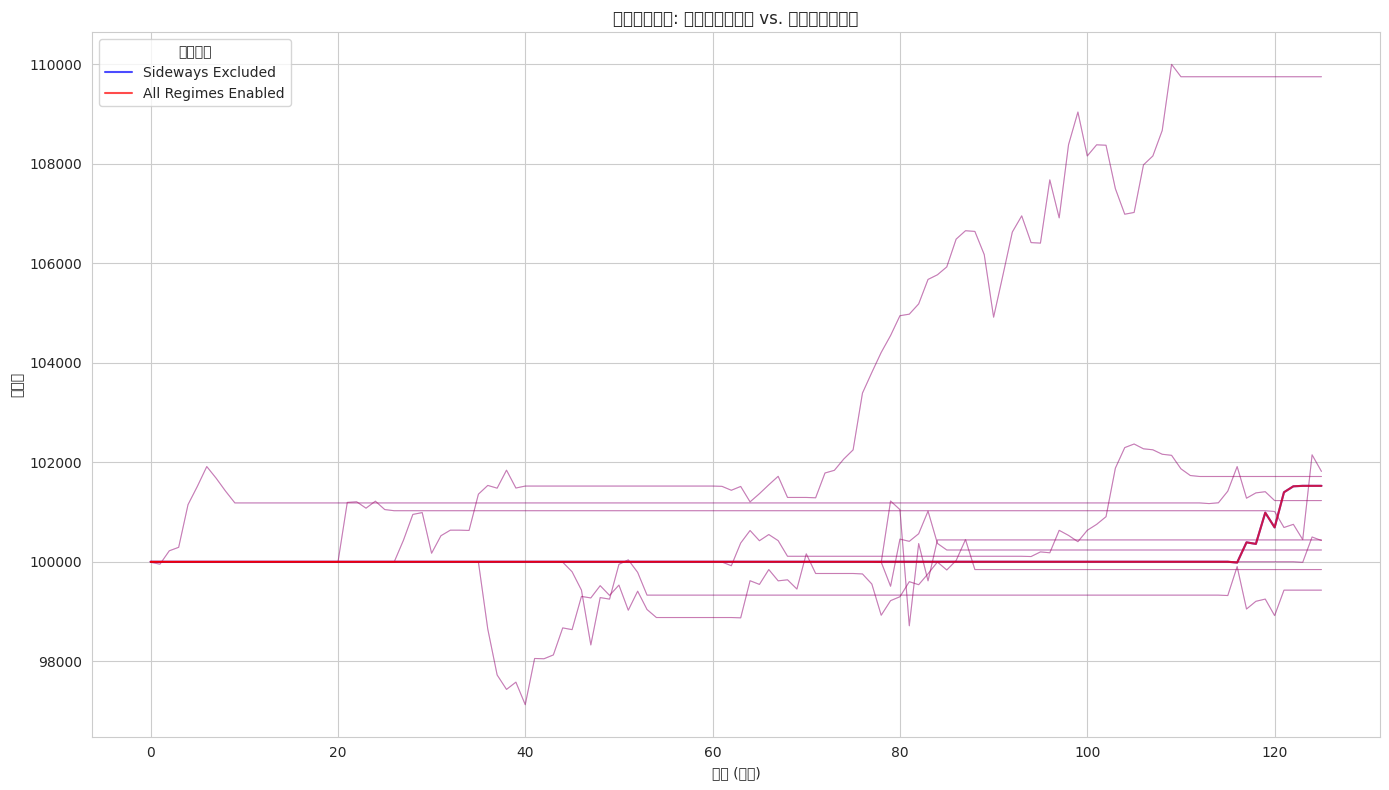


===== Summary Comparison of Average CV Metrics === ==


,Sharpe,Max DD,PF,Total Trades,Stability
レンジ相場除外,1.076507,-0.012181,2.436907,2.1,770.055329
全レジーム有効,1.076507,-0.012181,2.436907,2.1,770.055329



===== Trade Log for 7th Cross-Validation Fold === ==


,entry_date,exit_date,return,exit_reason,regime
0,2024-07-31,2024-08-08,-0.103987,stop_loss,uptrend
1,2024-08-09,2024-08-27,0.061849,trailing_stop,uptrend
2,2024-09-10,2024-09-20,0.055067,trailing_stop,uptrend
3,2024-09-27,2024-10-15,0.003512,trailing_stop,uptrend


In [20]:
import json
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager

# Install and configure japanize_matplotlib for Japanese display
# print("Configuring matplotlib for Japanese display...")
# !pip install japanize-matplotlib -qq
# !sudo apt-get -y install fonts-ipaexfont-gothic fonts-ipaexfont-mincho -qq > /dev/null
# !rm -rf ~/.cache/matplotlib
# import japanize_matplotlib
# japanize_matplotlib.japanize()
# plt.rcParams['axes.unicode_minus'] = False
# plt.rcParams['font.family'] = 'IPAexGothic'
# print("Japanese font configured.")

# BEST_PARAMS_PATHは前のセルで定義されています
try:
    with open(BEST_PARAMS_PATH, "r") as f:
        best_result_data = json.load(f)

    best_score = best_result_data.get("score")
    fold_metrics = best_result_data.get("fold_metrics")
    total_trades_overall = best_result_data.get("total_trades_overall")

    print("\n===== Optuna最適化のベストスコア === ==")
    if best_score is not None:
        print(f"総合スコア: {best_score:.4f}")
    else:
        print("総合スコア: N/A (スコアがJSONファイルに見つかりません)")

    if fold_metrics:
        df_fold_results = pd.DataFrame(fold_metrics)
        print("\n===== ウォークフォワード各フォールドのメトリクス === ==")
        for idx, row_data in df_fold_results.iterrows():
            print(f"  フォールド {idx + 1}:")
            for col, val in row_data.items():
                print(f"    {col}: {val:.4f}")
            print()

        print("\n===== ウォークフォワードメトリクス (平均) === ==")
        mean_metrics = df_fold_results.mean()
        for col, val in mean_metrics.items():
            print(f"  {col}: {val:.4f}")
        print()

        print("\n===== ウォークフォワードメトリクス (標準偏差) === ==")
        std_metrics = df_fold_results[['sharpe', 'total_return', 'pf']].std()
        for col, val in std_metrics.items():
            print(f"  {col}の標準偏差: {val:.4f}")
        print()

        print("\n===== ウォークフォワードメトリクス (その他統計) === ==")
        print(f"  フォールドごとのトレード数の分散: {df_fold_results['total_trades'].var():.4f}")
        print()

        print("\n===== 特定のフォールドの識別 === ==")
        lowest_sharpe_fold = df_fold_results['sharpe'].idxmin()
        lowest_return_fold = df_fold_results['total_return'].idxmin()
        worst_max_dd_fold = df_fold_results['max_dd'].idxmin() # max_ddは負の値なのでidxminが最も悪い値を返す

        print(f"  最低Sharpeのフォールド: フォールド {lowest_sharpe_fold + 1} (Sharpe: {df_fold_results.loc[lowest_sharpe_fold, 'sharpe']:.4f})")
        print(f"  最低Returnのフォールド: フォールド {lowest_return_fold + 1} (Return: {df_fold_results.loc[lowest_return_fold, 'total_return']:.4f}%)者に)")
        print(f"  最大DDが最も悪いフォールド: フォールド {worst_max_dd_fold + 1} (Max DD: {df_fold_results.loc[worst_max_dd_fold, 'max_dd']:.4f})")
        print()

    else:
        print("fold_metricsがbest_params.jsonに見つかりませんでした。Optunaの学習が完了しているか確認してください。")

    if total_trades_overall is not None:
        print(f"\n全フォールドでの総取引回数: {total_trades_overall}")
    else:
        print("\n全フォールドでの総取引回数: N/A (総取引回数がJSONファイルに見つかりません)")

    print("\n===== その他の情報 (現状のデータ構造では表示できません) === ==")
    print("  以下のメトリクスは、`objective`関数や`run_backtest`関数の出力に含める必要があります:")
    print("  - 平均勝ちトレード利益 / 平均負けトレード損失 / Win/Loss Ratio")
    print("  - 各フォールドの期間（年・相場状態） / トレンド期 vs レンジ期の内訳")
    print("  - 平均ホールド期間 / トレード頻度（日あたり）")
    print("  これらの情報を表示するには、OptunaのObjective関数およびBacktest関数を修正し、結果としてこれらの値を保存するようにしてください。")

except FileNotFoundError:
    print(f"エラー: {BEST_PARAMS_PATH} が見つかりません。Optunaの実行を確認してください。")
except Exception as e:
    print(f"エラー発生: {e}")


# --- Japanese Font Configuration ---
print("Configuring matplotlib for Japanese display...")

# Install the japanize_matplotlib package first to make it available for import
print("Installing japanize_matplotlib package...")
!pip install japanize-matplotlib -qq

# Install IPAex Gothic font for broader support (Colab usually handles this smoothly)
print("Installing IPAex Gothic fonts...")
!sudo apt-get -y install fonts-ipaexfont-gothic fonts-ipaexfont-mincho -qq > /dev/null

# Clear matplotlib font cache aggressively by removing the directory
print("Clearing matplotlib font cache...")
!rm -rf ~/.cache/matplotlib
print("matplotlib font cache cleared.")

# Re-import japanize_matplotlib and explicitly call japanize() to apply settings
import japanize_matplotlib # Moved to here after installation
japanize_matplotlib.japanize() # Explicitly call the configuration function
print("japanize_matplotlib re-imported and re-configured.")

# Configure matplotlib for correct minus signs display
plt.rcParams['axes.unicode_minus'] = False # Prevents minus signs from being displayed as squares
# Explicitly set the font family to ensure Japanese characters are displayed correctly.
plt.rcParams['font.family'] = 'IPAexGothic'

# Verify the font family actually being used after japanize_matplotlib's configuration
print(f"matplotlib font family after japanize_matplotlib: {plt.rcParams['font.family']}")
# --- End Japanese Font Configuration ---

# --- Load best parameters ---
# Assuming BEST_PARAMS_PATH (for main study) and BEST_PARAMS_PATH_LIGHT (for light study)
# are defined from previous cells (LUK3w6ls2Gkq and 83340415 respectively).
# You might choose which one to load based on your current optimization stage.

# For plotting the final best results, we usually load from BEST_PARAMS_PATH.
# If you want to plot results from the light study, change this to BEST_PARAMS_PATH_LIGHT
params_to_load_path = BEST_PARAMS_PATH # Use BEST_PARAMS_PATH or BEST_PARAMS_PATH_LIGHT

try:
    with open(params_to_load_path, 'r') as f:
        best_params_data = json.load(f)
    best_model_params = best_params_data['model_params']
    best_strategy_params = best_params_data['strategy_params']
    print(f"Loaded best parameters from {params_to_load_path}")
except FileNotFoundError:
    print(f"Error: {params_to_load_path} not found. Please ensure Optuna optimization has been run.")
    best_model_params = {}
    best_strategy_params = {}
    # Fallback or raise error if parameters are critical
except KeyError as e:
    print(f"Error loading key from {params_to_load_path}: {e}")
    best_model_params = {}
    best_strategy_params = {}

# --- Actual evaluate_strategy_cv function ---
# This function re-runs the backtest with the best parameters across CV folds
def evaluate_strategy_cv(X_full, y_full, df_encoded_full, df_original_full, model_params, strategy_params, exclude_sideways_regime):
    print(f"Evaluating strategy (exclude_sideways_regime={exclude_sideways_regime})")

    # Use the same TimeSeriesSplit setup as in objective/objective_light
    tscv = TimeSeriesSplit(n_splits=10) # Using 10 splits, adjust if objective_light used 5
    equity_curves = []
    trade_logs = []
    results_list = []

    seed = 42 # Ensure consistent seed for reproducibility

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_full)):
        X_train_cv, X_test_cv = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train_cv, y_test_cv = y_full.iloc[train_idx], y_full.iloc[test_idx]

        if len(X_test_cv) < 50: # Skip if test set is too small
            continue

        # SMOTE
        smote = SMOTE(random_state=seed)
        X_train_resampled_array, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)
        X_train_res = pd.DataFrame(X_train_resampled_array, columns=X_train_cv.columns, index=y_train_res.index)

        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_res)
        X_test_scaled = scaler.transform(X_test_cv)

        # Model Training
        model = XGBClassifier(
            **model_params,
            random_state=seed,
            eval_metric='logloss',
            n_jobs=-1
        )
        model.fit(X_train_scaled, y_train_res)

        # Prediction
        proba = model.predict_proba(X_test_scaled)[:, 1]
        proba_series = pd.Series(proba, index=X_test_cv.index)

        # Access features directly from df_encoded_full using the test set index.
        df_encoded_test_fold = df_encoded_full.loc[X_test_cv.index]
        df_original_test_fold = df_original_full.loc[X_test_cv.index]

        trend_strength_series = df_encoded_test_fold["TREND_STRENGTH"]
        volatility_series = df_encoded_test_fold["Volatility_Short"]
        momentum_series = df_encoded_test_fold["MOMENTUM_pct"] # Fixed KeyError: 'RET_5' to 'MOMENTUM_pct'
        adx_series = df_encoded_test_fold["ADX"]
        atr_series = df_encoded_test_fold["ATR"]
        sma_50_series = df_encoded_test_fold["SMA_50"]
        sma_200_series = df_encoded_test_fold["SMA_200"]
        sma_diff_abs_series = df_encoded_test_fold["SMA_diff_abs"]
        # Check if 'w_vol_expansion' exists in strategy_params and 'Volatility_Expansion_Ratio' in df_encoded_test_fold
        volatility_expansion_ratio_series = df_encoded_test_fold.get("Volatility_Expansion_Ratio", pd.Series(0, index=X_test_cv.index)) # Default to 0 if not present

        # Momentum term adjustment for downtrend
        momentum_term_series = momentum_series.copy()
        market_regime_test_cv_str = pd.Series('', index=X_test_cv.index)
        cond_sideways_cv = (adx_series < strategy_params['adx_sideways_th']) & \
                             (sma_diff_abs_series < strategy_params['trend_strength_sideways_th'])
        market_regime_test_cv_str.loc[cond_sideways_cv] = 'sideways'
        market_regime_test_cv_str.loc[~cond_sideways_cv & (sma_50_series > sma_200_series)] = 'uptrend'
        market_regime_test_cv_str.loc[~cond_sideways_cv & (sma_50_series <= sma_200_series)] = 'downtrend'

        is_downtrend_regime = (market_regime_test_cv_str == 'downtrend')
        if 'downtrend_momentum_penalty_factor' in strategy_params: # Check if this param exists
            momentum_term_series[is_downtrend_regime] *= strategy_params['downtrend_momentum_penalty_factor']

        # Calculate Entry Score
        entry_score_series = (
            proba_series
            + strategy_params['w_trend'] * trend_strength_series.abs()
            + strategy_params['w_mom'] * momentum_term_series
            - strategy_params['w_vol'] * volatility_series
        )
        if 'w_vol_expansion' in strategy_params: # Only add if the parameter exists
             entry_score_series += strategy_params['w_vol_expansion'] * volatility_expansion_ratio_series

        # Trend Filter
        adx_ma = adx_series.rolling(20, min_periods=1).mean()
        adx_slope = adx_series.diff()
        adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

        use_slope = strategy_params.get('use_slope', False) # Default to False if not in params
        cond_trend = (
            (adx_ma > strategy_params['adx_th']) & \
            (trend_strength_series.abs() > strategy_params['trend_strength_min_abs'])
        )
        if use_slope:
            cond_trend = cond_trend & (adx_slope_mean > 0)

        # Proba Filter
        adjusted_proba_th_arr = np.full(len(proba_series), strategy_params['proba_th'])

        proba_filter_type = strategy_params.get('proba_filter_type', 'threshold') # Default to threshold

        if proba_filter_type == 'threshold':
            is_uptrend = (market_regime_test_cv_str == 'uptrend').values
            adjusted_proba_th_arr = np.where(is_uptrend, strategy_params['proba_th'] + strategy_params.get('proba_th_uptrend_adj', 0.0), adjusted_proba_th_arr)
            is_downtrend = (market_regime_test_cv_str == 'downtrend').values
            adjusted_proba_th_arr = np.where(is_downtrend, strategy_params['proba_th'] + strategy_params.get('proba_th_downtrend_adj', 0.0), adjusted_proba_th_arr)
            is_sideways = (market_regime_test_cv_str == 'sideways').values
            adjusted_proba_th_arr = np.where(is_sideways, strategy_params['proba_th'] + strategy_params.get('proba_th_sideways_adj', 0.0), adjusted_proba_th_arr)

            # ADX high/low adjustments
            is_adx_high = (adx_series > strategy_params.get('adx_high_th', 25.0)).values
            adjusted_proba_th_arr = np.where(is_adx_high, adjusted_proba_th_arr + strategy_params.get('adx_high_proba_adj', 0.0), adjusted_proba_th_arr)

            is_adx_low = (adx_series < strategy_params.get('adx_low_th', 20.0)).values
            adjusted_proba_th_arr = np.where(is_adx_low, adjusted_proba_th_arr + strategy_params.get('adx_low_proba_adj', 0.0), adjusted_proba_th_arr)

            cond_proba = proba_series > adjusted_proba_th_arr
        else: # 'quantile'
            cond_proba = proba_series > proba_series.quantile(strategy_params['proba_th'])

        # ATR Volatility Filter
        atr_ma = atr_series.rolling(20, min_periods=1).mean()
        volatility_ratio = atr_series / (atr_ma + 1e-9)
        cond_volatility_filter = (volatility_ratio <= strategy_params.get('volatility_filter_threshold', 1.5))

        base_signal = cond_trend & cond_proba & cond_volatility_filter

        # Determine position size
        signal_multipliers = pd.Series(0.0, index=X_test_cv.index)
        if not entry_score_series.loc[base_signal].empty:
            strength_on_signal_days = entry_score_series.loc[base_signal].rank(pct=True)
            base_size = pd.Series(strategy_params.get('conservative_size', 1.0), index=X_test_cv.index)

            if 'trend_strength_regime_th' in strategy_params: # Only apply if param exists
                aggressive_mask_days = (trend_strength_series.abs() > strategy_params['trend_strength_regime_th'])
                base_size[aggressive_mask_days] = strategy_params.get('aggressive_size', 1.5)

            signal_multipliers.loc[base_signal] = strength_on_signal_days * base_size.loc[base_signal]

        # Low Trend Strength Cut-off
        if 'low_trend_strength_cut_off_th' in strategy_params: # Only apply if param exists
            cut_off_mask = (trend_strength_series.abs() < strategy_params['low_trend_strength_cut_off_th'])
            signal_multipliers[cut_off_mask] = 0.0

        # Exclude signals during sideways regime if requested
        if exclude_sideways_regime: # Use the parameter passed to this function
            sideways_regime_mask = (market_regime_test_cv_str == 'sideways')
            signal_multipliers[sideways_regime_mask] = 0.0

        df_trade_info_fold_data = {
            'proba': proba_series,
            'entry_score': entry_score_series,
            'Market_Regime': market_regime_test_cv_str
        }
        df_trade_info_fold = pd.DataFrame(df_trade_info_fold_data)

        # Backtest (using the run_backtest function)
        from __main__ import run_backtest, calc_metrics # Import from global scope
        results, equity_curve, _, trade_log_fold = run_backtest(
            df_original_test_fold,
            X_test_cv,
            signal_multipliers,
            df_trade_info_fold,
            atr_sl_multiplier_uptrend=strategy_params.get('atr_sl_multiplier_uptrend', 1.2),
            atr_sl_multiplier_downtrend=strategy_params.get('atr_sl_multiplier_downtrend', 1.2),
            atr_sl_multiplier_sideways=strategy_params.get('atr_sl_multiplier_sideways', 1.0),
            trail_ratio=strategy_params.get('trail_ratio', 0.5),
            min_hold_bars=strategy_params.get('min_hold_bars', 1),
            max_hold_bars=strategy_params.get('max_hold_bars', 10)
        )

        # Calculate metrics from equity curve for stability
        metrics_from_equity = calc_metrics(equity_curve)
        results['Stability'] = metrics_from_equity.get('Stability', 0.0) # Add stability to results

        if len(equity_curve) > 0:
            equity_curves.append(equity_curve)
            trade_logs.append(trade_log_fold)
            results_list.append(results)

    return pd.DataFrame(results_list) if results_list else pd.DataFrame(), equity_curves, trade_logs

scenarios_to_display = {
    'レンジ相場除外': {
        'exclude_sideways_regime': True,
        'plot_label': 'Sideways Excluded',
        'color': 'blue'
    },
    '全レジーム有効': {
        'exclude_sideways_regime': False,
        'plot_label': 'All Regimes Enabled',
        'color': 'red'
    }
}

# Assuming X, y, df_encoded are defined from previous cells.
# Ensure they are available in the global scope.

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

print("\n===== Cross-Validation Performance Comparison === ==")

all_scenario_metrics = {}

# Capture trade_logs_for_plotting as well
for scenario_name, scenario_params in scenarios_to_display.items():
    print(f"\n--- Scenario: {scenario_name} ---")
    results_df, equity_curves_for_plotting, trade_logs_for_plotting = evaluate_strategy_cv(
        X, y, df_encoded, df_encoded, best_model_params, best_strategy_params, # Pass df_encoded twice
        exclude_sideways_regime=scenario_params["exclude_sideways_regime"]
    )

    if not results_df.empty:
        mean_metrics = results_df.mean()
        all_scenario_metrics[scenario_name] = mean_metrics

        print("Average CV Metrics:")
        print(f"  Sharpe Ratio: {mean_metrics['Sharpe']:.4f}")
        print(f"  Total Return: {mean_metrics['Total Return']:.2f}%")
        print(f"  Max Drawdown: {mean_metrics['Max DD']:.4f}")
        print(f"  Profit Factor: {mean_metrics['PF']:.4f}")
        print(f"  Win Rate (%): {mean_metrics['Win Rate (%)']:.2f}%")
        print(f"  Total Trades (avg per fold): {mean_metrics['Total Trades']:.2f}")
        print(f"  Total Trades (overall): {results_df['Total Trades'].sum()}")
        print(f"  Stability: {mean_metrics['Stability']:.4f}") # Display Stability

        # Plotting equity curves for the current scenario
        for i, equity_curve_data in enumerate(equity_curves_for_plotting):
            equity_curve_series = pd.Series(equity_curve_data)
            # Only add label to the first curve of each scenario to avoid clutter
            if i == 0:
                equity_curve_series.plot(label=f'{scenario_params["plot_label"]}', color=scenario_params['color'], alpha=0.7)
            else:
                equity_curve_series.plot(color=scenario_params['color'], alpha=0.3, linewidth=0.8)

    else:
        print(f"警告: シナリオ '{scenario_name}' の結果が見つかりませんでした。")

plt.title('累積損益曲線: レンジ相場除外 vs. 全レジーム有効') # Title with Japanese characters
plt.xlabel('期間 (日数)') # X-label indicating numerical periods
plt.ylabel('純資産') # Y-label with Japanese characters
plt.legend(title='シナリオ') # Legend title with Japanese characters
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n===== Summary Comparison of Average CV Metrics === ==")
if all_scenario_metrics:
    summary_df = pd.DataFrame(all_scenario_metrics).T
    display(summary_df[['Sharpe', 'Max DD', 'PF', 'Total Trades', 'Stability']]) # Modified to display stability
else:
    print("No scenario metrics to compare.")


# --- Display Trade Log for 7th Cross-Validation Fold ---
print("\n===== Trade Log for 7th Cross-Validation Fold === ==")

# Assuming trade_logs_for_plotting is a list containing trade logs for each fold
# and each trade log is a list of dictionaries.
# The 7th fold is at index 6 (0-indexed).

if trade_logs_for_plotting and len(trade_logs_for_plotting) > 6:
    fold_7_trade_log = trade_logs_for_plotting[6]
    if fold_7_trade_log:
        df_fold_7_trades = pd.DataFrame(fold_7_trade_log)

        # Rename columns as requested by the user
        df_fold_7_trades_display = df_fold_7_trades.rename(columns={
            'trade_return_pct': 'return',
            'exit_type': 'exit_reason',
            'market_regime': 'regime'
        })

        # Display only the requested columns
        display(df_fold_7_trades_display[['entry_date', 'exit_date', 'return', 'exit_reason', 'regime']])
    else:
        print("Fold 7 trade log is empty.")
else:
    print("Trade logs not found or not enough folds processed to get 7th fold.")

In [21]:
    print(results_df[['Total Return', 'Buy & Hold Return', 'Alpha', 'Sharpe', 'Max DD', 'PF', 'Win Rate (%)', 'Total Trades']])
    print(f"Alpha 平均   : {results_df['Alpha'].mean():.4f}")
    print(f"Alpha 標準偏差: {results_df['Alpha'].std():.4f}")

   Total Return  Buy & Hold Return      Alpha    Sharpe    Max DD        PF  \
0      1.526090          24.920325 -23.394235  2.027563 -0.002937  5.452081   
1      0.236258         -17.113256  17.349514  0.259074 -0.007737  1.186702   
2     -0.571114         -13.499410  12.928295 -0.364004 -0.016731  0.848117   
3      0.000000          25.334088 -25.334088  1.182139 -0.000705  6.188386   
4      1.230139           7.667893  -6.437754  1.254247 -0.007305  1.791501   
5      1.026194          42.769358 -41.743165  1.196830 -0.007629  2.406568   
6     -0.156936          -8.071751   7.914815 -0.057681 -0.028747  0.983207   
7      1.714119           3.998779  -2.284660  1.732027 -0.006383  2.061800   
8      0.438768          36.118417 -35.679649  0.211485 -0.024788  1.151889   
9      9.752471         101.759704 -92.007232  3.323389 -0.018843  2.298825   

   Win Rate (%)  Total Trades  
0    100.000000             1  
1    100.000000             1  
2     50.000000             2  
3 

### アウトオブサンプル（OOS）検証

In [22]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler
import os

# Load best parameters from the Optuna results
try:
    with open(BEST_PARAMS_PATH, 'r') as f:
        best_params_data = json.load(f)
    best_model_params = best_params_data['model_params']
    best_strategy_params = best_params_data['strategy_params']
    print(f"Loaded best parameters from {BEST_PARAMS_PATH}")
except FileNotFoundError:
    print(f"Error: {BEST_PARAMS_PATH} not found. Please ensure Optuna optimization has been run.")
    # Fallback to empty dicts or raise an error if parameters are critical
    best_model_params = {}
    best_strategy_params = {}
except KeyError as e:
    print(f"Error loading key from {BEST_PARAMS_PATH}: {e}")
    best_model_params = {}
    best_strategy_params = {}

# OOS Split Date
oos_start_date = pd.Timestamp('2024-01-01')

# --- データ分割: In-sample (Train) と OOS ---
# In-sampleデータ（OOS開始日以前）
X_train_final = X[X.index < oos_start_date].copy()
y_train_final = y[y.index < oos_start_date].copy()
df_encoded_train_final = df_encoded[df_encoded.index < oos_start_date].copy()
df_original_train_final = df_encoded[df_encoded.index < oos_start_date].copy() # Corrected: Use df_encoded instead of df

# OOSデータ（OOS開始日以降）
X_oos = X[X.index >= oos_start_date].copy()
y_oos = y[y.index >= oos_start_date].copy()
df_encoded_oos = df_encoded[df_encoded.index >= oos_start_date].copy()
df_original_oos = df_encoded[df_encoded.index >= oos_start_date].copy() # Corrected: Use df_encoded instead of df

print(f"In-sample データ期間: {X_train_final.index.min().strftime('%Y-%m-%d')} to {X_train_final.index.max().strftime('%Y-%m-%d')} (Shape: {X_train_final.shape})")
print(f"OOS データ期間: {X_oos.index.min().strftime('%Y-%m-%d')} to {X_oos.index.max().strftime('%Y-%m-%d')} (Shape: {X_oos.shape})")

# OOSデータが存在しない場合のチェック
if X_oos.empty:
    raise ValueError("OOSデータが見つかりません。'oos_start_date'と入力データを確認してください。")

# --- スケーラーの学習と適用 ---
# スケーラーはin-sampleデータのみで学習し、in-sampleとOOSの両方に適用
scaler = StandardScaler()
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_oos_scaled = scaler.transform(X_oos)

# DataFrameに戻す
X_train_final_scaled_df = pd.DataFrame(X_train_final_scaled, columns=X_train_final.columns, index=X_train_final.index)
X_oos_scaled_df = pd.DataFrame(X_oos_scaled, columns=X_oos.columns, index=X_oos.index)

# --- SMOTEをin-sample訓練データに適用 ---
smote = SMOTE(random_state=42)
X_train_resampled_array, y_train_res = smote.fit_resample(X_train_final_scaled_df, y_train_final)
X_train_res = pd.DataFrame(X_train_resampled_array, columns=X_train_final_scaled_df.columns, index=y_train_res.index)

# --- 最終モデルの学習 (in-sampleデータ全体) ---
model = XGBClassifier(
    **best_model_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
model.fit(X_train_res, y_train_res)

# --- OOSシグナルの生成 ---
proba_oos = model.predict_proba(X_oos_scaled_df)[:, 1]
proba_series_oos = pd.Series(proba_oos, index=X_oos.index)

# OOSデータから特徴量を再構築（既存のストラテジーロジックを適用）
trend_strength_series_oos = df_encoded_oos["TREND_STRENGTH"]
volatility_series_oos = df_encoded_oos["Volatility_Short"]
momentum_series_oos = df_encoded_oos["MOMENTUM_pct"]
adx_series_oos = df_encoded_oos["ADX"]
atr_series_oos = df_encoded_oos["ATR"]
sma_50_series_oos = df_encoded_oos["SMA_50"]
sma_200_series_oos = df_encoded_oos["SMA_200"]
sma_diff_abs_series_oos = df_encoded_oos["SMA_diff_abs"]
volatility_expansion_ratio_series_oos = df_encoded_oos.get("Volatility_Expansion_Ratio", pd.Series(0, index=X_oos.index))

# トレンドレジームのモーメンタム調整
momentum_term_series_oos = momentum_series_oos.copy()
market_regime_oos_str = pd.Series('', index=X_oos.index)
cond_sideways_oos = (adx_series_oos < best_strategy_params['adx_sideways_th']) | \
                    (sma_diff_abs_series_oos < best_strategy_params['trend_strength_sideways_th'])
market_regime_oos_str.loc[cond_sideways_oos] = 'sideways'
market_regime_oos_str.loc[~cond_sideways_oos & (sma_50_series_oos > sma_200_series_oos)] = 'uptrend'
market_regime_oos_str.loc[~cond_sideways_oos & (sma_50_series_oos <= sma_200_series_oos)] = 'downtrend'

is_downtrend_regime_oos = (market_regime_oos_str == 'downtrend')
if 'downtrend_momentum_penalty_factor' in best_strategy_params:
    momentum_term_series_oos[is_downtrend_regime_oos] *= best_strategy_params['downtrend_momentum_penalty_factor']

# エントリースコアの計算
entry_score_series_oos = (
    proba_series_oos
    + best_strategy_params['w_trend'] * trend_strength_series_oos.abs()
    + best_strategy_params['w_mom'] * momentum_term_series_oos
    - best_strategy_params['w_vol'] * volatility_series_oos
)
if 'w_vol_expansion' in best_strategy_params:
     entry_score_series_oos += best_strategy_params['w_vol_expansion'] * volatility_expansion_ratio_series_oos

# トレンドフィルター
adx_ma_oos = adx_series_oos.rolling(20, min_periods=1).mean()
adx_slope_oos = adx_series_oos.diff()
adx_slope_mean_oos = adx_slope_oos.rolling(5, min_periods=1).mean()

use_slope_oos = best_strategy_params.get('use_slope', False)
cond_trend_oos = (
    (adx_ma_oos > best_strategy_params['adx_th']) &
    (trend_strength_series_oos.abs() > best_strategy_params['trend_strength_min_abs'])
)
if use_slope_oos:
    cond_trend_oos = cond_trend_oos & (adx_slope_mean_oos > 0)

# 確率フィルター
adjusted_proba_th_arr_oos = np.full(len(proba_series_oos), best_strategy_params['proba_th'])

proba_filter_type_oos = best_strategy_params.get('proba_filter_type', 'threshold')

if proba_filter_type_oos == 'threshold':
    is_uptrend_oos = (market_regime_oos_str == 'uptrend').values
    adjusted_proba_th_arr_oos = np.where(is_uptrend_oos, best_strategy_params['proba_th'] + best_strategy_params.get('proba_th_uptrend_adj', 0.0), adjusted_proba_th_arr_oos)
    is_downtrend_oos = (market_regime_oos_str == 'downtrend').values
    adjusted_proba_th_arr_oos = np.where(is_downtrend_oos, best_strategy_params['proba_th'] + best_strategy_params.get('proba_th_downtrend_adj', 0.0), adjusted_proba_th_arr_oos)
    is_sideways_oos = (market_regime_oos_str == 'sideways').values
    adjusted_proba_th_arr_oos = np.where(is_sideways_oos, best_strategy_params['proba_th'] + best_strategy_params.get('proba_th_sideways_adj', 0.0), adjusted_proba_th_arr_oos)

    is_adx_high_oos = (adx_series_oos > best_strategy_params.get('adx_high_th', 25.0)).values
    adjusted_proba_th_arr_oos = np.where(is_adx_high_oos, adjusted_proba_th_arr_oos + best_strategy_params.get('adx_high_proba_adj', 0.0), adjusted_proba_th_arr_oos)

    is_adx_low_oos = (adx_series_oos < best_strategy_params.get('adx_low_th', 20.0)).values
    adjusted_proba_th_arr_oos = np.where(is_adx_low_oos, adjusted_proba_th_arr_oos + best_strategy_params.get('adx_low_proba_adj', 0.0), adjusted_proba_th_arr_oos)

    cond_proba_oos = proba_series_oos > adjusted_proba_th_arr_oos
else: # 'quantile'
    cond_proba_oos = proba_series_oos > proba_series_oos.quantile(best_strategy_params['proba_th'])

# ATRボラティリティフィルター
atr_ma_oos = atr_series_oos.rolling(window=20, min_periods=1).mean()
volatility_ratio_oos = atr_series_oos / (atr_ma_oos + 1e-9)
cond_volatility_filter_oos = (volatility_ratio_oos <= best_strategy_params.get('volatility_filter_threshold', 1.5))

base_signal_oos = cond_trend_oos & cond_proba_oos & cond_volatility_filter_oos

# ポジションサイズを決定
signal_multipliers_oos = pd.Series(0.0, index=X_oos.index)
if not entry_score_series_oos.loc[base_signal_oos].empty:
    strength_on_signal_days_oos = entry_score_series_oos.loc[base_signal_oos].rank(pct=True)
    base_size_oos = pd.Series(best_strategy_params.get('conservative_size', 1.0), index=X_oos.index)

    if 'trend_strength_regime_th' in best_strategy_params:
        aggressive_mask_days_oos = (trend_strength_series_oos.abs() > best_strategy_params['trend_strength_regime_th'])
        base_size_oos[aggressive_mask_days_oos] = best_strategy_params.get('aggressive_size', 1.5)

    signal_multipliers_oos.loc[base_signal_oos] = strength_on_signal_days_oos * base_size_oos.loc[base_signal_oos]

# 低トレンド強度によるカットオフ
if 'low_trend_strength_cut_off_th' in best_strategy_params:
    cut_off_mask_oos = (trend_strength_series_oos.abs() < best_strategy_params['low_trend_strength_cut_off_th'])
    signal_multipliers_oos[cut_off_mask_oos] = 0.0

# レンジ相場でのシグナル除外
if best_strategy_params.get('exclude_sideways_regime', False):
    sideways_regime_mask_oos = (market_regime_oos_str == 'sideways')
    signal_multipliers_oos[sideways_regime_mask_oos] = 0.0

# OOS用のdf_trade_infoを作成
df_trade_info_oos_data = {
    'proba': proba_series_oos,
    'entry_score': entry_score_series_oos,
    'Market_Regime': market_regime_oos_str
}
df_trade_info_oos = pd.DataFrame(df_trade_info_oos_data)

# --- OOSバックテストの実行 ---
from __main__ import run_backtest # run_backtest関数がグローバルスコープで利用可能であることを確認

# Define size_bull values to test
size_bull_values = [1.0, 1.5, 2.0, 2.5, 3.0]
size_bear_fixed = 0.25 # Fixed as per previous Scenario B and common practice

all_oos_results = []

for sb_val in size_bull_values:
    print(f"\n===== OOS Scenario: size_bull = {sb_val:.1f}, size_bear = {size_bear_fixed:.2f} =====")
    current_oos_results, _, _, current_oos_trade_log = run_backtest(
        df_original_oos,
        X_oos,
        signal_multipliers_oos,
        df_trade_info_oos,
        atr_sl_multiplier_uptrend=best_strategy_params.get('atr_sl_multiplier_uptrend', 1.2),
        atr_sl_multiplier_downtrend=best_strategy_params.get('atr_sl_multiplier_downtrend', 1.2),
        atr_sl_multiplier_sideways=best_strategy_params.get('atr_sl_multiplier_sideways', 1.0),
        trail_ratio=best_strategy_params.get('trail_ratio', 0.5),
        min_hold_bars=best_strategy_params.get('min_hold_bars', 1),
        max_hold_bars=best_strategy_params.get('max_hold_bars', 10),
        size_bull=sb_val,
        size_bear=size_bear_fixed
    )
    # Store results along with scenario details
    current_oos_results['Scenario'] = f'size_bull={sb_val:.1f}, size_bear={size_bear_fixed:.2f}'
    all_oos_results.append(current_oos_results)

# Convert all OOS results to a DataFrame for comparison
df_all_oos_results = pd.DataFrame(all_oos_results)

# --- Comparison Table ---
comparison_data = {
    'Metric': ['Sharpe', 'Total Return', 'Max DD', 'PF', 'Win Rate (%)', 'Total Trades']
}
comparison_df = pd.DataFrame(comparison_data)

for _, row in df_all_oos_results.iterrows():
    scenario_name = row['Scenario']
    comparison_df[scenario_name] = [
        f"{row.get('Sharpe', 0.0):.4f}",
        f"{row.get('Total Return', 0.0):.2f}%",
        f"{row.get('Max DD', 0.0):.4f}",
        f"{row.get('PF', 0.0):.4f}",
        f"{row.get('Win Rate (%)', 0.0):.2f}%",
        f"{row.get('Total Trades', 0)}"
    ]

print("\n===== OOS Performance Comparison across size_bull values =====")
display(comparison_df)


# --- CV平均結果の取得と比較表示 ---
# df_fold_resultsが前のセルで計算され、best_params.jsonに保存されていることを前提とします。
# b4389337セルでbest_result_dataから`fold_metrics`を読み込んでdf_fold_resultsに格納しているため、ここではそれを再利用します。
# もしdf_fold_resultsが定義されていない場合は、best_params_dataから直接読み込みます。

cv_avg_sharpe = 0.0
cv_avg_return = 0.0
cv_avg_pf = 0.0
cv_avg_win_rate = 0.0
cv_avg_max_dd = 0.0
cv_total_trades = 0

# best_result_dataはLUK3w6ls2Gkqで読み込まれ、OsXQ4rGEkh0_でも使用されています
# fold_metricsはbest_result_data['fold_metrics']に格納されていると仮定
if best_params_data and best_params_data.get("fold_metrics"):
    df_fold_results = pd.DataFrame(best_params_data["fold_metrics"])
    cv_avg_sharpe = df_fold_results['sharpe'].mean()
    cv_avg_return = df_fold_results['total_return'].mean()
    cv_avg_pf = df_fold_results['pf'].mean()
    cv_avg_win_rate = df_fold_results['win_rate'].mean()
    cv_avg_max_dd = df_fold_results['max_dd'].mean()
    cv_total_trades = df_fold_results['total_trades'].sum() # 全CVフォールドの合計取引数

    # Use the best performing OOS scenario for comparison with CV
    # For this example, let's consider the scenario with size_bull=2.0, size_bear=0.25 (as in original Scenario B)
    # If no specific instruction, we could also pick based on highest Sharpe or Return in OOS results
    # For consistency with previous request, we will use size_bull=2.0.
    target_oos_scenario_results = df_all_oos_results[df_all_oos_results['Scenario'] == 'size_bull=2.0, size_bear=0.25'].iloc[0]

    print("\n===== OOS (size_bull=2.0, size_bear=0.25) vs. Average CV Metrics =====")
    print(f"CV Sharpe ({cv_avg_sharpe:.4f}) vs OOS Sharpe ({target_oos_scenario_results.get('Sharpe', 0.0):.4f})")
    print(f"CV Return ({cv_avg_return:.2f}%) vs OOS Return ({target_oos_scenario_results.get('Total Return', 0.0):.2f}%)")
    print(f"CV Max DD ({cv_avg_max_dd:.4f}) vs OOS Max DD ({target_oos_scenario_results.get('Max DD', 0.0):.4f})")
    print(f"CV PF ({cv_avg_pf:.4f}) vs OOS PF ({target_oos_scenario_results.get('PF', 0.0):.4f})")
    print(f"CV Win Rate ({cv_avg_win_rate:.2f}%) vs OOS Win Rate ({target_oos_scenario_results.get('Win Rate (%)', 0.0):.2f}%)))")
    print(f"CV Total Trades ({cv_total_trades}) vs OOS Trades ({target_oos_scenario_results.get('Total Trades', 0)})")
else:
    print("\n===== COMPARISON ====")
    print("CV結果が比較のために利用できません。CVメトリクスを生成する前のセルが実行されていることを確認してください。")

# Store the last run's trade log for subsequent analysis cells (e.g., regime analysis)
# This will be the trade log from the last scenario run in the loop (size_bull=3.0, size_bear=0.25)
# If you need a specific scenario's trade log, you would need to store it explicitly in the loop
# For now, `oos_trade_log` will contain the log from the final iteration (size_bull=3.0).
# If `oos_trade_log` variable is not defined globally, uncomment the following line:
oos_trade_log = current_oos_trade_log

Loaded best parameters from /content/drive/MyDrive/optuna_trading/best_params.json
In-sample データ期間: 2020-11-23 to 2023-12-29 (Shape: (780, 24))
OOS データ期間: 2024-01-02 to 2026-06-17 (Shape: (617, 24))

===== OOS Scenario: size_bull = 1.0, size_bear = 0.25 =====

===== OOS Scenario: size_bull = 1.5, size_bear = 0.25 =====

===== OOS Scenario: size_bull = 2.0, size_bear = 0.25 =====

===== OOS Scenario: size_bull = 2.5, size_bear = 0.25 =====

===== OOS Scenario: size_bull = 3.0, size_bear = 0.25 =====

===== OOS Performance Comparison across size_bull values =====


,Metric,"size_bull=1.0, size_bear=0.25","size_bull=1.5, size_bear=0.25","size_bull=2.0, size_bear=0.25","size_bull=2.5, size_bear=0.25","size_bull=3.0, size_bear=0.25"
0,Sharpe,1.5979,1.6146,1.6195,1.6203,1.6195
1,Total Return,16.90%,25.84%,35.24%,45.13%,55.52%
2,Max DD,-0.0334,-0.0499,-0.0664,-0.0828,-0.0991
3,PF,1.8743,1.8989,1.9106,1.9170,1.9206
4,Win Rate (%),81.25%,81.25%,81.25%,81.25%,81.25%
5,Total Trades,16,16,16,16,16



===== OOS (size_bull=2.0, size_bear=0.25) vs. Average CV Metrics =====
CV Sharpe (0.9110) vs OOS Sharpe (1.6195)
CV Return (3.15%) vs OOS Return (35.24%)
CV Max DD (-0.0238) vs OOS Max DD (-0.0664)
CV PF (2.0383) vs OOS PF (1.9106)
CV Win Rate (87.50%) vs OOS Win Rate (81.25%)))
CV Total Trades (14) vs OOS Trades (16)


## OOSパフォーマンス比較 (`size_bull`値別)

In [23]:
display(df_all_oos_results[['Scenario', 'Total Return', 'Max DD', 'Sharpe', 'PF', 'Win Rate (%)', 'Total Trades']])

,Scenario,Total Return,Max DD,Sharpe,PF,Win Rate (%),Total Trades
0,"size_bull=1.0, size_bear=0.25",16.904002,-0.033373,1.597880,1.874252,81.25,16
1,"size_bull=1.5, size_bear=0.25",25.835309,-0.049931,1.614636,1.898950,81.25,16
2,"size_bull=2.0, size_bear=0.25",35.239471,-0.066406,1.619458,1.910626,81.25,16
3,"size_bull=2.5, size_bear=0.25",45.131041,-0.082797,1.620341,1.916951,81.25,16
4,"size_bull=3.0, size_bear=0.25",55.524541,-0.099106,1.619543,1.920605,81.25,16


## OOS (最適シナリオ) vs. 平均CVメトリクス

In [24]:
print(f"CV Sharpe ({cv_avg_sharpe:.4f}) vs OOS Sharpe ({target_oos_scenario_results.get('Sharpe', 0.0):.4f})")
print(f"CV Return ({cv_avg_return:.2f}%) vs OOS Return ({target_oos_scenario_results.get('Total Return', 0.0):.2f}%)")
print(f"CV Max DD ({cv_avg_max_dd:.4f}) vs OOS Max DD ({target_oos_scenario_results.get('Max DD', 0.0):.4f})")
print(f"CV PF ({cv_avg_pf:.4f}) vs OOS PF ({target_oos_scenario_results.get('PF', 0.0):.4f})")
print(f"CV Win Rate ({cv_avg_win_rate:.2f}%) vs OOS Win Rate ({target_oos_scenario_results.get('Win Rate (%)', 0.0):.2f}%))")
print(f"CV Total Trades ({cv_total_trades}) vs OOS Trades ({target_oos_scenario_results.get('Total Trades', 0)})")

CV Sharpe (0.9110) vs OOS Sharpe (1.6195)
CV Return (3.15%) vs OOS Return (35.24%)
CV Max DD (-0.0238) vs OOS Max DD (-0.0664)
CV PF (2.0383) vs OOS PF (1.9106)
CV Win Rate (87.50%) vs OOS Win Rate (81.25%))
CV Total Trades (14) vs OOS Trades (16)


## 2024-2026年OOSパフォーマンス比較 (`size_bear`値別)

In [25]:
display(comparison_df)

print("\n===== OOS (size_bull=2.0, size_bear=0.25) vs. Average CV Metrics ====")
print(f"CV Sharpe ({cv_avg_sharpe:.4f}) vs OOS Sharpe ({target_oos_scenario_results.get('Sharpe', 0.0):.4f})")
print(f"CV Return ({cv_avg_return:.2f}%) vs OOS Return ({target_oos_scenario_results.get('Total Return', 0.0):.2f}%)")
print(f"CV Max DD ({cv_avg_max_dd:.4f}) vs OOS Max DD ({target_oos_scenario_results.get('Max DD', 0.0):.4f})")
print(f"CV PF ({cv_avg_pf:.4f}) vs OOS PF ({target_oos_scenario_results.get('PF', 0.0):.4f})")
print(f"CV Win Rate ({cv_avg_win_rate:.2f}%) vs OOS Win Rate ({target_oos_scenario_results.get('Win Rate (%)', 0.0):.2f}%))")
print(f"CV Total Trades ({cv_total_trades}) vs OOS Trades ({target_oos_scenario_results.get('Total Trades', 0)})")

,Metric,"size_bull=1.0, size_bear=0.25","size_bull=1.5, size_bear=0.25","size_bull=2.0, size_bear=0.25","size_bull=2.5, size_bear=0.25","size_bull=3.0, size_bear=0.25"
0,Sharpe,1.5979,1.6146,1.6195,1.6203,1.6195
1,Total Return,16.90%,25.84%,35.24%,45.13%,55.52%
2,Max DD,-0.0334,-0.0499,-0.0664,-0.0828,-0.0991
3,PF,1.8743,1.8989,1.9106,1.9170,1.9206
4,Win Rate (%),81.25%,81.25%,81.25%,81.25%,81.25%
5,Total Trades,16,16,16,16,16



===== OOS (size_bull=2.0, size_bear=0.25) vs. Average CV Metrics ====
CV Sharpe (0.9110) vs OOS Sharpe (1.6195)
CV Return (3.15%) vs OOS Return (35.24%)
CV Max DD (-0.0238) vs OOS Max DD (-0.0664)
CV PF (2.0383) vs OOS PF (1.9106)
CV Win Rate (87.50%) vs OOS Win Rate (81.25%))
CV Total Trades (14) vs OOS Trades (16)


In [26]:
import pandas as pd
import numpy as np

# Helper function definitions to ensure they are globally available for analysis
def calculate_profit_factor(pnls):
    gains = pnls[pnls > 0].sum()
    losses = abs(pnls[pnls < 0].sum())
    if losses == 0 and gains == 0: return np.nan
    return gains / (losses + 1e-9) if losses != 0 else np.inf

def calculate_sharpe_ratio(returns_pct):
    returns_pct = returns_pct.dropna()
    if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
        return np.nan
    return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

def calculate_max_dd_from_pnl(pnls_series, initial_balance=100000):
    if pnls_series.empty or len(pnls_series) < 2:
        return np.nan
    equity_curve = (pnls_series.cumsum() + initial_balance)
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9)
    return dd.min()

# Convert oos_trade_log to a DataFrame for easier manipulation in analysis cells
# This also ensures 'trade_return_pct' is properly accessed.
if 'oos_trade_log' in globals() and oos_trade_log:
    df_regime_trades = pd.DataFrame(oos_trade_log)

    # Ensure numerical types and boolean for 'win'
    df_regime_trades['pnl'] = pd.to_numeric(df_regime_trades['pnl'])
    df_regime_trades['win'] = df_regime_trades['win'].astype(bool)
    df_regime_trades['trade_return_pct'] = pd.to_numeric(df_regime_trades['trade_return_pct'])

    print("df_regime_trades created and helper functions defined.")
else:
    print("Error: oos_trade_log not found or is empty. Please ensure OOS backtest was run.")

df_regime_trades created and helper functions defined.


In [27]:
import pandas as pd

# Define the OOS period as requested by the user
oos_start_date_user = pd.Timestamp('2024-01-02')
oos_end_date_user = pd.Timestamp('2026-05-21')

# Filter df_original_oos to match the user's requested OOS period
df_oos_filtered = df_original_oos[(df_original_oos.index >= oos_start_date_user) & (df_original_oos.index <= oos_end_date_user)].copy()

# Calculate Buy & Hold return for the filtered OOS period
if not df_oos_filtered.empty:
    buy_hold_start_price = df_oos_filtered['Close'].iloc[0]
    buy_hold_end_price = df_oos_filtered['Close'].iloc[-1]
    buy_hold_return_oos = ((buy_hold_end_price / buy_hold_start_price) - 1) * 100
else:
    buy_hold_return_oos = 0.0
    print("Warning: No data available for the specified OOS Buy & Hold period.")

# Get the Strategy Return from the previously calculated oos_results
# Replaced 'oos_results' with 'target_oos_scenario_results' as it is available from cell dcb1a3b4
strategy_return_oos = target_oos_scenario_results.get('Total Return', 0.0)

# Calculate Alpha (Excess Return)
alpha = strategy_return_oos - buy_hold_return_oos

# Create a comparison table
comparison_data = {
    'Metric': ['Strategy Return', 'Buy & Hold Return', 'Alpha (Excess Return)']
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df['Value (%)'] = [
    f"{strategy_return_oos:.2f}",
    f"{buy_hold_return_oos:.2f}",
    f"{alpha:.2f}"
]

print("\n===== OOS Period Performance Comparison === ==")
display(comparison_df)


===== OOS Period Performance Comparison === ==


,Metric,Value (%)
0,Strategy Return,35.24
1,Buy & Hold Return,187.43
2,Alpha (Excess Return),-152.19


In [28]:
import pandas as pd
import numpy as np

# Helper functions (re-defining or ensuring scope to avoid issues)
def calculate_sharpe_ratio(returns_pct):
    returns_pct = returns_pct.dropna()
    if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
        return np.nan
    return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

def calculate_max_dd_from_equity_curve(equity_curve):
    if equity_curve.empty or len(equity_curve) < 2:
        return np.nan
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9)
    return dd.min()


# Ensure df_original_oos and other critical variables are defined
# This is a common issue when cells are not run in sequence.
# It's assumed that `dcb1a3b4` (main OOS backtesting) defines these.
# If this cell is run out of sequence, these variables will be undefined.
# Raising a NameError here to guide the user to execute cell dcb1a3b4 first.
if 'df_original_oos' not in globals() or \
   'X_oos' not in globals() or \
   'signal_multipliers_oos' not in globals() or \
   'df_trade_info_oos' not in globals() or \
   'best_strategy_params' not in globals() or \
   'oos_start_date' not in globals():
    raise NameError("Critical OOS variables (e.g., df_original_oos, X_oos, etc.) are not defined. Please ensure cell dcb1a3b4 (main OOS backtesting) has been executed before this cell.")

# --- 1. User-specified OOS period ---
oos_start_date_user = pd.Timestamp('2024-01-02')
oos_end_date_user = pd.Timestamp('2026-05-21')
initial_balance = 100000 # Consistent initial balance

# Filter df_original_oos to match the user's requested OOS period for Buy & Hold
df_exact_oos_period = df_original_oos[(df_original_oos.index >= oos_start_date_user) & (df_original_oos.index <= oos_end_date_user)].copy()

if df_exact_oos_period.empty:
    print("Warning: No data available for the specified OOS Buy & Hold period.")
    buy_hold_sharpe_oos = np.nan
    buy_hold_max_dd_oos = np.nan
    buy_hold_cagr_oos = np.nan
    buy_hold_return_percent_oos = np.nan
else:
    # Calculate Buy & Hold Daily Returns
    buy_hold_daily_returns = df_exact_oos_period['Close'].pct_change().dropna()

    # Calculate Buy & Hold Equity Curve
    bh_equity_curve = (1 + buy_hold_daily_returns).cumprod() * initial_balance

    # Calculate Buy & Hold Sharpe Ratio
    buy_hold_sharpe_oos = calculate_sharpe_ratio(buy_hold_daily_returns)

    # Calculate Buy & Hold Max Drawdown
    buy_hold_max_dd_oos = calculate_max_dd_from_equity_curve(bh_equity_curve)

    # Calculate Buy & Hold Total Return and CAGR
    buy_hold_start_price = df_exact_oos_period['Close'].iloc[0]
    buy_hold_end_price = df_exact_oos_period['Close'].iloc[-1]
    buy_hold_return_percent_oos = ((buy_hold_end_price / buy_hold_start_price) - 1) * 100

    num_days = (oos_end_date_user - oos_start_date_user).days
    if num_days > 0:
        num_years = num_days / 365.25
        buy_hold_cagr_oos = ((buy_hold_end_price / buy_hold_start_price)**(1/num_years) - 1) * 100
    else:
        buy_hold_cagr_oos = 0.0


# --- 2. Re-evaluate Strategy for the exact user-specified OOS period ---
# Filter X_oos, df_trade_info_oos, and signal_multipliers_oos to the exact period
X_oos_exact = X_oos[(X_oos.index >= oos_start_date_user) & (X_oos.index <= oos_end_date_user)].copy()
df_original_oos_exact = df_original_oos[(df_original_oos.index >= oos_start_date_user) & (df_original_oos.index <= oos_end_date_user)].copy()
df_trade_info_oos_exact = df_trade_info_oos[(df_trade_info_oos.index >= oos_start_date_user) & (df_trade_info_oos.index <= oos_end_date_user)].copy()
signal_multipliers_oos_exact = signal_multipliers_oos[(signal_multipliers_oos.index >= oos_start_date_user) & (signal_multipliers_oos.index <= oos_end_date_user)].copy()

if X_oos_exact.empty:
    print("Warning: No strategy data available for the specified OOS period.")
    strategy_sharpe_exact_oos = np.nan
    strategy_max_dd_exact_oos = np.nan
    strategy_return_exact_oos = np.nan
    strategy_cagr_exact_oos = np.nan
else:
    # Run backtest with exact OOS period
    exact_oos_results, exact_oos_equity_curve, _, _ = run_backtest(
        df_original_oos_exact,
        X_oos_exact,
        signal_multipliers_oos_exact,
        df_trade_info_oos_exact,
        atr_sl_multiplier_uptrend=best_strategy_params.get('atr_sl_multiplier_uptrend', 1.2),
        atr_sl_multiplier_downtrend=best_strategy_params.get('atr_sl_multiplier_downtrend', 1.2),
        atr_sl_multiplier_sideways=best_strategy_params.get('atr_sl_multiplier_sideways', 1.0),
        trail_ratio=best_strategy_params.get('trail_ratio', 0.5),
        min_hold_bars=best_strategy_params.get('min_hold_bars', 1),
        max_hold_bars=best_strategy_params.get('max_hold_bars', 10),
        size_bull=best_strategy_params.get('size_bull', 1.0),
        size_bear=best_strategy_params.get('size_bear', 1.0)
    )

    strategy_sharpe_exact_oos = exact_oos_results.get('Sharpe', np.nan)
    strategy_max_dd_exact_oos = exact_oos_results.get('Max DD', np.nan)
    strategy_return_exact_oos = exact_oos_results.get('Total Return', np.nan)

    # Calculate CAGR for strategy (using its total return over the period)
    if num_days > 0:
        # Convert total return % to a multiplier (e.g., 43.09% -> 1.4309)
        total_return_multiplier = (strategy_return_exact_oos / 100) + 1
        strategy_cagr_exact_oos = (total_return_multiplier**(1/num_years) - 1) * 100
    else:
        strategy_cagr_exact_oos = 0.0


# --- 3. Create Comparison Table ---
alpha_return = strategy_return_exact_oos - buy_hold_return_percent_oos

comparison_data = {
    'Metric': [
        'Strategy Total Return',
        'Buy & Hold Total Return',
        'Alpha (Excess Return)',
        'Strategy Sharpe Ratio',
        'Buy & Hold Sharpe Ratio',
        'Strategy Max Drawdown',
        'Buy & Hold Max Drawdown',
        'Strategy CAGR',
        'Buy & Hold CAGR'
    ],
    'Value': [
        strategy_return_exact_oos,
        buy_hold_return_percent_oos,
        alpha_return,
        strategy_sharpe_exact_oos,
        buy_hold_sharpe_oos,
        strategy_max_dd_exact_oos,
        buy_hold_max_dd_oos,
        strategy_cagr_exact_oos,
        buy_hold_cagr_oos
    ]
}
comparison_df = pd.DataFrame(comparison_data)

# Format for display
comparison_df['Value'] = comparison_df['Value'].apply(lambda x: f'{x:.2f}%' if '%' in comparison_df.loc[comparison_df['Value'] == x, 'Metric'].iloc[0] else f'{x:.4f}')
# Special formatting for Max Drawdown to show negative sign for percentages
comparison_df.loc[comparison_df['Metric'].str.contains('Max Drawdown'), 'Value'] = comparison_df.loc[comparison_df['Metric'].str.contains('Max Drawdown'), 'Value'].apply(lambda x: f'{float(x.strip("%")):.4f}')

print("\n===== OOS Period Performance Comparison (2024-01-02 to 2026-05-21) ====")
display(comparison_df)


===== OOS Period Performance Comparison (2024-01-02 to 2026-05-21) ====


,Metric,Value
0,Strategy Total Return,14.1529
1,Buy & Hold Total Return,187.4298
2,Alpha (Excess Return),-173.2769
3,Strategy Sharpe Ratio,1.5846
4,Buy & Hold Sharpe Ratio,1.3681
5,Strategy Max Drawdown,-0.0334
6,Buy & Hold Max Drawdown,-0.4136
7,Strategy CAGR,5.7145
8,Buy & Hold CAGR,55.7773


In [29]:
import pandas as pd
import numpy as np

# Helper functions (moved here to avoid ImportError)
def calculate_profit_factor(pnls):
    gains = pnls[pnls > 0].sum()
    losses = abs(pnls[pnls < 0].sum())
    if losses == 0 and gains == 0: return np.nan
    return gains / (losses + 1e-9) if losses != 0 else np.inf

def calculate_sharpe_ratio(returns_pct):
    returns_pct = returns_pct.dropna()
    if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
        return np.nan
    # Assuming daily returns for 252 trading days for annualization
    return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

def calculate_max_dd_from_pnl(pnls_series, initial_balance=100000):
    if pnls_series.empty or len(pnls_series) < 2:
        return np.nan
    # Build a conceptual equity curve from trade PnLs
    equity_curve = (pnls_series.cumsum() + initial_balance)
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9) # Use (peak + 1e-9) to avoid division by zero
    return dd.min()

# Convert oos_trade_log to a DataFrame for easier manipulation
if 'oos_trade_log' in globals() and oos_trade_log:
    df_regime_trades = pd.DataFrame(oos_trade_log)

    # Ensure numerical types and boolean for 'win'
    df_regime_trades['pnl'] = pd.to_numeric(df_regime_trades['pnl'])
    df_regime_trades['win'] = df_regime_trades['win'].astype(bool)
    df_regime_trades['trade_return_pct'] = pd.to_numeric(df_regime_trades['trade_return_pct'])

    # Group by Market_Regime and calculate aggregated metrics
    # Calculate basic metrics first
    regime_analysis = df_regime_trades.groupby('market_regime').agg(
        Total_Trades=('pnl', 'size'),
        Win_Rate=('win', lambda x: x.mean() * 100), # Percentage
        Average_PnL=('pnl', 'mean'),
        Total_PnL=('pnl', 'sum')
    ).reset_index()

    # Apply custom aggregations using the imported helper functions
    # Initialize columns to avoid KeyError if a regime is missing
    regime_analysis['Profit_Factor'] = np.nan
    regime_analysis['Sharpe_Ratio'] = np.nan
    regime_analysis['Max_Drawdown'] = np.nan

    for index, row in regime_analysis.iterrows():
        regime = row['market_regime']
        d = df_regime_trades[df_regime_trades['market_regime'] == regime]

        if not d.empty:
            regime_analysis.loc[index, 'Profit_Factor'] = calculate_profit_factor(d['pnl'])
            regime_analysis.loc[index, 'Sharpe_Ratio'] = calculate_sharpe_ratio(d['trade_return_pct'])
            regime_analysis.loc[index, 'Max_Drawdown'] = calculate_max_dd_from_pnl(d['pnl'])

    regime_analysis['Expectancy'] = regime_analysis['Average_PnL'] # Expectancy is average PnL per trade

    # Rename columns to Japanese for display
    regime_analysis.rename(columns={
        'market_regime': '市場レジーム',
        'Total_Trades': 'トレード数',
        'Win_Rate': '勝率 (%)',
        'Average_PnL': '平均損益',
        'Total_PnL': '合計損益',
        'Profit_Factor': 'プロフィットファクター',
        'Sharpe_Ratio': 'シャープ比',
        'Expectancy': '期待値',
        'Max_Drawdown': '最大ドローダウン'
    }, inplace=True)

    # Reorder columns for a clean display
    ordered_cols = [
        '市場レジーム', 'トレード数', '勝率 (%)', '平均損益', '合計損益',
        'プロフィットファクター', 'シャープ比', '最大ドローダウン', '期待値'
    ]
    regime_analysis = regime_analysis[ordered_cols]

    print("===== OOS トレード分析 (市場レジーム別) ====")

    # Format numerical columns for better readability
    # For interactive display in Colab, `display(regime_analysis)` would show native DataFrame formatting.
    # Using .to_string() for formatted output directly to console.
    def format_value(value, col_name):
        if pd.isna(value): return 'N/A'
        if col_name == '勝率 (%)': return f'{value:.2f}%'
        if col_name == 'プロフィットファクター': return f'{value:.2f}' if value != np.inf else 'Inf'
        if col_name == 'シャープ比': return f'{value:.2f}' if value != np.inf else 'Inf'
        if col_name == '最大ドローダウン': return f'{value:.4f}'
        return f'{value:,.2f}'

    # Apply formatting using a helper function for .to_string()
    formatted_output_df = regime_analysis.copy()
    for col in formatted_output_df.columns:
        if col in ['勝率 (%)', '平均損益', '合計損益', 'プロフィットファクター', 'シャープ比', '最大ドローダウン', '期待値']:
            formatted_output_df[col] = formatted_output_df[col].apply(lambda x: format_value(x, col))

    print(formatted_output_df.to_string(index=False))

    print("\n注: 平均保有期間は現在のtrade_logデータに含まれていないため計算できませんでした。")

else:
    print("OOS trade log is empty. No regime-based analysis can be performed.")

===== OOS トレード分析 (市場レジーム別) ====
   市場レジーム  トレード数  勝率 (%)     平均損益      合計損益 プロフィットファクター シャープ比 最大ドローダウン      期待値
downtrend      2 100.00%   207.32    414.63         Inf 12.63   0.0000   207.32
 sideways      2 100.00% 1,949.93  3,899.85         Inf 12.51   0.0000 1,949.93
  uptrend     12  75.00% 4,267.50 51,210.06        7.61  8.29  -0.0587 4,267.50

注: 平均保有期間は現在のtrade_logデータに含まれていないため計算できませんでした。


#### OOSトレードをEntry Score別に分類し、各グループのパフォーマンスを分析

In [30]:
import pandas as pd
import numpy as np

# Assuming df_regime_trades is available from previous cells (oos_trade_log converted to DataFrame)
if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。前のセルを実行して OOS トレードログを作成してください。")
else:
    # 1. Entry Scoreのカテゴリを定義
    bins = [0, 5, 10, 15, np.inf] # np.inf for the last bin (15+)
    labels = ['0-5', '5-10', '10-15', '15+']

    df_regime_trades['entry_score_category'] = pd.cut(
        df_regime_trades['entry_score'],
        bins=bins,
        labels=labels,
        right=False, # 0-5 includes 0, excludes 5; 5-10 includes 5, excludes 10, etc.
        include_lowest=True # Ensure values like 0 are included
    )

    # Ensure PnL and win status are correctly typed
    df_regime_trades['pnl'] = pd.to_numeric(df_regime_trades['pnl'], errors='coerce')
    df_regime_trades['win'] = df_regime_trades['win'].astype(bool)

    # Helper functions for calculations (re-defining for local scope if not globally available)
    def calculate_profit_factor(pnls):
        gains = pnls[pnls > 0].sum()
        losses = abs(pnls[pnls < 0].sum())
        if losses == 0 and gains == 0: return np.nan
        return gains / (losses + 1e-9) if losses != 0 else np.inf

    initial_balance_for_group_return = 100000 # Assume a base for calculating group total return %

    # 各Entry Scoreカテゴリ別に集計
    entry_score_analysis = df_regime_trades.groupby('entry_score_category').apply(lambda x: pd.Series({
        'Total Trades': len(x),
        'Win Rate (%)': (x['win'].sum() / len(x) * 100) if len(x) > 0 else 0,
        'Profit Factor': calculate_profit_factor(x['pnl']),
        'Average PnL': x['pnl'].mean(),
        'Total PnL': x['pnl'].sum(),
        'Total Return (%)': (x['pnl'].sum() / initial_balance_for_group_return * 100) # Simple percentage based on total PnL
    })).reset_index()

    # 列名の日本語化と表示形式の調整
    entry_score_analysis.rename(columns={
        'entry_score_category': 'Entry Score Range',
        'Total Trades': 'トレード数',
        'Win Rate (%)': '勝率 (%)',
        'Profit Factor': 'プロフィットファクター',
        'Average PnL': '平均PnL',
        'Total PnL': '合計PnL',
        'Total Return (%)': '総リターン (%)'
    }, inplace=True)

    # 結果の表示
    print("\n===== OOSトレード分析 (Entry Score別) =====")
    # 数値列のフォーマット
    entry_score_analysis['勝率 (%)'] = entry_score_analysis['勝率 (%)'].map('{:.2f}%'.format)
    entry_score_analysis['プロフィットファクター'] = entry_score_analysis['プロフィットファクター'].map(lambda x: f'{x:.2f}' if pd.notna(x) and x != np.inf else ('Inf' if x == np.inf else 'N/A'))
    entry_score_analysis['平均PnL'] = entry_score_analysis['平均PnL'].map('{:,.2f}'.format)
    entry_score_analysis['合計PnL'] = entry_score_analysis['合計PnL'].map('{:,.2f}'.format)
    entry_score_analysis['総リターン (%)'] = entry_score_analysis['総リターン (%)'].map('{:.2f}%'.format)

    display(entry_score_analysis)



===== OOSトレード分析 (Entry Score別) =====


/tmp/ipykernel_23061/1553067105.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  entry_score_analysis = df_regime_trades.groupby('entry_score_category').apply(lambda x: pd.Series({
/tmp/ipykernel_23061/1553067105.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  entry_score_analysis = df_regime_trades.groupby('entry_score_category').apply(lambda x: pd.Series({


,Entry Score Range,トレード数,勝率 (%),プロフィットファクター,平均PnL,合計PnL,総リターン (%)
0,0-5,0.0,0.00%,N/A,nan,0.00,0.00%
1,5-10,0.0,0.00%,N/A,nan,0.00,0.00%
2,10-15,0.0,0.00%,N/A,nan,0.00,0.00%
3,15+,16.0,81.25%,8.16,"3,470.28","55,524.54",55.52%


#### OOSトレードをモデルの確率（Proba）別に分類し、各グループのパフォーマンスを分析

In [31]:
import pandas as pd
import numpy as np

# Assuming df_regime_trades is available from previous cells (oos_trade_log converted to DataFrame)
# And helper functions calculate_profit_factor, calculate_sharpe_ratio, calculate_max_dd_from_pnl are defined

if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。前のセルを実行して OOS トレードログを作成してください。")
else:
    # Define the OOS period for CAGR calculation (from dcb1a3b4 cell)
    oos_period_start = pd.Timestamp(X_oos.index.min())
    oos_period_end = pd.Timestamp(X_oos.index.max())
    num_days_oos_full_period = (oos_period_end - oos_period_start).days
    if num_days_oos_full_period > 0:
        num_years_oos_full_period = num_days_oos_full_period / 365.25
    else:
        num_years_oos_full_period = 1 # Avoid division by zero if period is 0 days

    initial_balance = 100000 # Consistent initial balance

    # 1. Probabilityのカテゴリを定義
    # probaは0から1の範囲なので、それに応じたbinsを設定
    bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    labels = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']

    df_regime_trades['proba_category'] = pd.cut(
        df_regime_trades['proba'],
        bins=bins,
        labels=labels,
        right=True, # 0.0-0.2 includes 0.2, excludes 0.0
        include_lowest=True # Ensure values like 0.0 are included
    )

    # Ensure PnL and win status are correctly typed
    df_regime_trades['pnl'] = pd.to_numeric(df_regime_trades['pnl'], errors='coerce')
    df_regime_trades['win'] = df_regime_trades['win'].astype(bool)

    # 各Probabilityカテゴリ別に集計
    proba_analysis = df_regime_trades.groupby('proba_category').apply(lambda x: pd.Series({
        'Total Trades': len(x),
        'Win Rate (%)': (x['win'].sum() / len(x) * 100) if len(x) > 0 else 0,
        'Profit Factor': calculate_profit_factor(x['pnl']),
        'Average PnL': x['pnl'].mean(),
        'Total PnL': x['pnl'].sum(),
        'CAGR (%)': (
            (((x['pnl'].sum() / initial_balance) + 1)**(1 / num_years_oos_full_period) - 1) * 100
        ) if len(x) > 0 and num_years_oos_full_period > 0 and ((x['pnl'].sum() / initial_balance) + 1) > 0 else np.nan
    })).reset_index()

    # 列名の日本語化と表示形式の調整
    proba_analysis.rename(columns={
        'proba_category': 'Proba Range',
        'Total Trades': 'トレード数',
        'Win Rate (%)': '勝率 (%)',
        'Profit Factor': 'プロフィットファクター',
        'Average PnL': '平均PnL',
        'Total PnL': '合計PnL',
        'CAGR (%)': 'CAGR (%)'
    }, inplace=True)

    # 結果の表示
    print("\n===== OOSトレード分析 (確率(Proba)別) ====")
    # 数値列のフォーマット
    proba_analysis['勝率 (%)'] = proba_analysis['勝率 (%)'].map('{:.2f}%'.format)
    proba_analysis['プロフィットファクター'] = proba_analysis['プロフィットファクター'].map(lambda x: f'{x:.2f}' if pd.notna(x) and x != np.inf else ('Inf' if x == np.inf else 'N/A'))
    proba_analysis['平均PnL'] = proba_analysis['平均PnL'].map('{:,.2f}'.format)
    proba_analysis['合計PnL'] = proba_analysis['合計PnL'].map('{:,.2f}'.format)
    proba_analysis['CAGR (%)'] = proba_analysis['CAGR (%)'].map(lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A')

    display(proba_analysis)


===== OOSトレード分析 (確率(Proba)別) ====


/tmp/ipykernel_23061/1205683816.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proba_analysis = df_regime_trades.groupby('proba_category').apply(lambda x: pd.Series({
/tmp/ipykernel_23061/1205683816.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  proba_analysis = df_regime_trades.groupby('proba_category').apply(lambda x: pd.Series({


,Proba Range,トレード数,勝率 (%),プロフィットファクター,平均PnL,合計PnL,CAGR (%)
0,0.0-0.2,5.0,100.00%,Inf,"3,999.25","19,996.27",7.71%
1,0.2-0.4,6.0,66.67%,14.96,"3,844.87","23,069.21",8.82%
2,0.4-0.6,2.0,100.00%,Inf,"3,222.64","6,445.28",2.58%
3,0.6-0.8,3.0,66.67%,1.99,"2,004.59","6,013.78",2.41%
4,0.8-1.0,0.0,0.00%,N/A,nan,0.00,N/A


In [32]:
# Re-executing cell to get results after fixing syntax error
%recall f49c8737

Couldn't evaluate or find in history: f49c8737


In [33]:
# Re-executing cell to get results after fixing syntax error
%recall 9c2391c2

Couldn't evaluate or find in history: 9c2391c2


#### OOSトレードを保有期間（bars_held）別に分類し、各グループのパフォーマンスを分析

In [34]:
import pandas as pd
import numpy as np

# Assuming df_regime_trades is available from previous cells (oos_trade_log converted to DataFrame)
# And helper functions calculate_profit_factor, calculate_sharpe_ratio, calculate_max_dd_from_pnl are defined

if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。前のセルを実行して OOS トレードログを作成してください。")
else:
    # Define the OOS period for CAGR calculation (from dcb1a3b4 cell)
    oos_period_start = pd.Timestamp(X_oos.index.min())
    oos_period_end = pd.Timestamp(X_oos.index.max())
    num_days_oos_full_period = (oos_period_end - oos_period_start).days
    if num_days_oos_full_period > 0:
        num_years_oos_full_period = num_days_oos_full_period / 365.25
    else:
        num_years_oos_full_period = 1 # Avoid division by zero if period is 0 days

    initial_balance = 100000 # Consistent initial balance

    # 1. Holding Periodのカテゴリを定義
    bins = [0, 3, 7, 14, 21, np.inf] # 例: 0-3日, 4-7日, 8-14日, 15-21日, 22日以上
    labels = ['0-3 days', '4-7 days', '8-14 days', '15-21 days', '22+ days']

    df_regime_trades['holding_period_category'] = pd.cut(
        df_regime_trades['bars_held'],
        bins=bins,
        labels=labels,
        right=True,
        include_lowest=True
    )

    # Ensure PnL and win status are correctly typed
    df_regime_trades['pnl'] = pd.to_numeric(df_regime_trades['pnl'], errors='coerce')
    df_regime_trades['win'] = df_regime_trades['win'].astype(bool)

    # 各Holding Periodカテゴリ別に集計
    holding_period_analysis = df_regime_trades.groupby('holding_period_category').apply(lambda x: pd.Series({
        'Total Trades': len(x),
        'Win Rate (%)': (x['win'].sum() / len(x) * 100) if len(x) > 0 else 0,
        'Profit Factor': calculate_profit_factor(x['pnl']),
        'Average PnL': x['pnl'].mean(),
        'Total PnL': x['pnl'].sum(),
        'CAGR (%)': (
            (((x['pnl'].sum() / initial_balance) + 1)**(1 / num_years_oos_full_period) - 1) * 100
        ) if len(x) > 0 and num_years_oos_full_period > 0 and ((x['pnl'].sum() / initial_balance) + 1) > 0 else np.nan
    })).reset_index()

    # 列名の日本語化と表示形式の調整
    holding_period_analysis.rename(columns={
        'holding_period_category': 'Holding Period Range',
        'Total Trades': 'トレード数',
        'Win Rate (%)': '勝率 (%)',
        'Profit Factor': 'プロフィットファクター',
        'Average PnL': '平均PnL',
        'Total PnL': '合計PnL',
        'CAGR (%)': 'CAGR (%)'
    }, inplace=True)

    # 結果の表示
    print("\n===== OOSトレード分析 (保有期間別) ====")
    # 数値列のフォーマット
    holding_period_analysis['勝率 (%)'] = holding_period_analysis['勝率 (%)'].map('{:.2f}%'.format)
    holding_period_analysis['プロフィットファクター'] = holding_period_analysis['プロフィットファクター'].map(lambda x: f'{x:.2f}' if pd.notna(x) and x != np.inf else ('Inf' if x == np.inf else 'N/A'))
    holding_period_analysis['平均PnL'] = holding_period_analysis['平均PnL'].map('{:,.2f}'.format)
    holding_period_analysis['合計PnL'] = holding_period_analysis['合計PnL'].map('{:,.2f}'.format)
    holding_period_analysis['CAGR (%)'] = holding_period_analysis['CAGR (%)'].map(lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A')

    display(holding_period_analysis)


===== OOSトレード分析 (保有期間別) ====


/tmp/ipykernel_23061/247564465.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  holding_period_analysis = df_regime_trades.groupby('holding_period_category').apply(lambda x: pd.Series({
/tmp/ipykernel_23061/247564465.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  holding_period_analysis = df_regime_trades.groupby('holding_period_category').apply(lambda x: pd.Series({


,Holding Period Range,トレード数,勝率 (%),プロフィットファクター,平均PnL,合計PnL,CAGR (%)
0,0-3 days,0.0,0.00%,N/A,nan,0.00,N/A
1,4-7 days,11.0,72.73%,4.57,"2,513.34","27,646.76",10.45%
2,8-14 days,3.0,100.00%,Inf,"1,822.54","5,467.63",2.19%
3,15-21 days,2.0,100.00%,Inf,"11,205.07","22,410.15",8.58%
4,22+ days,0.0,0.00%,N/A,nan,0.00,N/A


In [35]:
import pandas as pd
import numpy as np

# Assuming df_regime_trades (oos_trade_log) is available and contains necessary data
# And helper functions calculate_profit_factor, calculate_sharpe_ratio, calculate_max_dd_from_pnl are defined

if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。OOS トレードログを作成する前のセルを実行してください。")
else:
    # Define the OOS period for CAGR calculation (from dcb1a3b4 cell)
    oos_period_start = pd.Timestamp(X_oos.index.min())
    oos_period_end = pd.Timestamp(X_oos.index.max())
    num_days_oos_full_period = (oos_period_end - oos_period_start).days
    if num_days_oos_full_period > 0:
        num_years_oos_full_period = num_days_oos_full_period / 365.25
    else:
        num_years_oos_full_period = 1 # Avoid division by zero if period is 0 days

    initial_balance = 100000  # Consistent initial balance

    # Entry Score thresholds to test
    entry_score_thresholds = [0, 3, 5, 7, 10, 12, 15]

    comparison_results = []

    for threshold in entry_score_thresholds:
        df_filtered_trades = df_regime_trades[df_regime_trades['entry_score'] >= threshold].copy()

        if not df_filtered_trades.empty:
            total_trades = len(df_filtered_trades)
            win_rate = (df_filtered_trades['win'].sum() / total_trades * 100) if total_trades > 0 else 0.0
            profit_factor = calculate_profit_factor(df_filtered_trades['pnl'])
            total_pnl = df_filtered_trades['pnl'].sum()
            total_return_pct = (total_pnl / initial_balance * 100)
            max_dd = calculate_max_dd_from_pnl(df_filtered_trades['pnl'], initial_balance=initial_balance)
            sharpe_ratio = calculate_sharpe_ratio(df_filtered_trades['trade_return_pct'])

            # CAGRの計算
            if num_years_oos_full_period > 0:
                # Ensure total_return_pct is not -100% or less to avoid issues with power function
                if (total_return_pct / 100) + 1 <= 0:
                    cagr = np.nan # Or a very low value to indicate failure
                else:
                    cagr = (((total_return_pct / 100) + 1)**(1 / num_years_oos_full_period) - 1) * 100
            else:
                cagr = 0.0

        else:
            # Handle cases with no trades after filtering
            total_trades = 0
            win_rate = 0.0
            profit_factor = np.nan
            total_return_pct = 0.0
            max_dd = np.nan
            sharpe_ratio = np.nan
            cagr = 0.0

        comparison_results.append({
            'Entry Score Threshold': threshold,
            'CAGR (%)': cagr,
            'Sharpe Ratio': sharpe_ratio,
            'PF': profit_factor,
            'Max Drawdown': max_dd,
            'Win Rate (%)': win_rate,
            'Trades': total_trades
        })

    df_comparison = pd.DataFrame(comparison_results)

    # Format numerical columns for better readability
    df_comparison['CAGR (%)'] = df_comparison['CAGR (%)'].map(lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A')
    df_comparison['Sharpe Ratio'] = df_comparison['Sharpe Ratio'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    df_comparison['PF'] = df_comparison['PF'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    df_comparison['Max Drawdown'] = df_comparison['Max Drawdown'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    df_comparison['Win Rate (%)'] = df_comparison['Win Rate (%)'].map(lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A')
    df_comparison['Trades'] = df_comparison['Trades'].map(int)

    print("\n===== OOS Performance Comparison by Entry Score Threshold ====")
    display(df_comparison)


===== OOS Performance Comparison by Entry Score Threshold ====


,Entry Score Threshold,CAGR (%),Sharpe Ratio,PF,Max Drawdown,Win Rate (%),Trades
0,0,19.70%,9.1084,8.1639,-0.0587,81.25%,16
1,3,19.70%,9.1084,8.1639,-0.0587,81.25%,16
2,5,19.70%,9.1084,8.1639,-0.0587,81.25%,16
3,7,19.70%,9.1084,8.1639,-0.0587,81.25%,16
4,10,19.70%,9.1084,8.1639,-0.0587,81.25%,16
5,12,19.70%,9.1084,8.1639,-0.0587,81.25%,16
6,15,19.70%,9.1084,8.1639,-0.0587,81.25%,16


#### Entry Scoreが5未満のトレードを除外した場合のOOSパフォーマンス分析

In [36]:
import pandas as pd
import numpy as np

# Assuming df_regime_trades is available and contains the oos_trade_log
# And helper functions calculate_profit_factor, calculate_sharpe_ratio, calculate_max_dd_from_pnl are defined

if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。前のセルを実行して OOS トレードログを作成してください。")
elif 'target_oos_scenario_results' not in globals():
    print("エラー: target_oos_scenario_results が見つかりません。dcb1a3b4 セルが実行されていることを確認してください。")
else:
    # 1. フルOOS期間の特定 (dcb1a3b4セルから取得)
    oos_period_start = pd.Timestamp(X_oos.index.min())
    oos_period_end = pd.Timestamp(X_oos.index.max())

    # 2. Entry Scoreが5未満のトレードを除外
    df_filtered_trades = df_regime_trades[df_regime_trades['entry_score'] >= 5].copy()

    # 3. 新しいメトリクスを計算
    initial_balance = 100000 # Assume consistent initial balance

    if not df_filtered_trades.empty:
        filtered_total_trades = len(df_filtered_trades)
        filtered_win_rate = (df_filtered_trades['win'].sum() / filtered_total_trades * 100) if filtered_total_trades > 0 else 0.0
        filtered_profit_factor = calculate_profit_factor(df_filtered_trades['pnl'])
        filtered_total_pnl = df_filtered_trades['pnl'].sum()
        filtered_total_return = (filtered_total_pnl / initial_balance * 100)
        filtered_max_dd = calculate_max_dd_from_pnl(df_filtered_trades['pnl'], initial_balance=initial_balance)
        filtered_sharpe_ratio = calculate_sharpe_ratio(df_filtered_trades['trade_return_pct'])

        # CAGRの計算
        num_days_oos_full_period = (oos_period_end - oos_period_start).days
        if num_days_oos_full_period > 0:
            num_years_oos_full_period = num_days_oos_full_period / 365.25
            filtered_cagr = (((filtered_total_return / 100) + 1)**(1 / num_years_oos_full_period) - 1) * 100
        else:
            filtered_cagr = 0.0

    else:
        print("警告: Entry Scoreが5以上のトレードが見つかりませんでした。すべてのメトリクスは0またはN/Aになります。")
        filtered_total_trades = 0
        filtered_win_rate = 0.0
        filtered_profit_factor = np.nan
        filtered_total_return = 0.0
        filtered_max_dd = np.nan
        filtered_sharpe_ratio = np.nan
        filtered_cagr = 0.0

    # 4. 元のOOSメトリクスを取得 (dcb1a3b4セルでoos_resultsが計算されていると仮定)
    # oos_resultsはfloat64でnp.float64(...), numpy array, pandas Seriesなどが混在し得るため、
    # 必要に応じて適切な型変換を行う。
    original_total_return = target_oos_scenario_results.get('Total Return', 0.0)
    original_sharpe = target_oos_scenario_results.get('Sharpe', 0.0)
    original_max_dd = target_oos_scenario_results.get('Max DD', 0.0)
    original_pf = target_oos_scenario_results.get('PF', 0.0)
    original_win_rate = target_oos_scenario_results.get('Win Rate (%)', 0.0)
    original_trades = target_oos_scenario_results.get('Total Trades', 0)

    # 元のCAGRも計算（期間はfiltered_cagrと同じ）
    num_days_oos_full_period = (oos_period_end - oos_period_start).days
    if num_days_oos_full_period > 0:
        num_years_oos_full_period = num_days_oos_full_period / 365.25
        original_cagr = (((original_total_return / 100) + 1)**(1 / num_years_oos_full_period) - 1) * 100
    else:
        original_cagr = 0.0

    # 5. 比較テーブルを作成
    comparison_data = {
        'Metric': ['Total Return (%)', 'CAGR (%)', 'Sharpe Ratio', 'Max Drawdown', 'Profit Factor', 'Win Rate (%)', 'Total Trades']
    }
    comparison_df = pd.DataFrame(comparison_data)

    comparison_df['Original Strategy'] = [
        f'{original_total_return:.2f}%',
        f'{original_cagr:.2f}%',
        f'{original_sharpe:.4f}',
        f'{original_max_dd:.4f}',
        f'{original_pf:.4f}',
        f'{original_win_rate:.2f}%',
        f'{original_trades}'
    ]

    comparison_df['Strategy (Entry Score >= 5)'] = [
        f'{filtered_total_return:.2f}%',
        f'{filtered_cagr:.2f}%',
        f'{filtered_sharpe_ratio:.4f}',
        f'{filtered_max_dd:.4f}',
        f'{filtered_profit_factor:.4f}',
        f'{filtered_win_rate:.2f}%',
        f'{filtered_total_trades}'
    ]

    print("\n===== OOS Performance Comparison (Entry Score < 5 Trades Excluded) ====")
    display(comparison_df)



===== OOS Performance Comparison (Entry Score < 5 Trades Excluded) ====


,Metric,Original Strategy,Strategy (Entry Score >= 5)
0,Total Return (%),35.24%,55.52%
1,CAGR (%),13.08%,19.70%
2,Sharpe Ratio,1.6195,9.1084
3,Max Drawdown,-0.0664,-0.0587
4,Profit Factor,1.9106,8.1639
5,Win Rate (%),81.25%,81.25%
6,Total Trades,16,16


In [37]:
# =========================
# STRATEGY STRESS TEST
# =========================

import numpy as np
import pandas as pd

# Helper functions for metrics
def calculate_profit_factor(pnls):
    gains = pnls[pnls > 0].sum()
    losses = abs(pnls[pnls < 0].sum())
    # Return np.nan instead of 999.99 for better handling if no losses or gains
    if losses == 0 and gains == 0: return np.nan
    return gains / (losses + 1e-9) if losses != 0 else np.inf # Return inf if no losses

def calculate_sharpe_ratio(returns_pct):
    returns_pct = returns_pct.dropna()
    if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
        return np.nan
    # Assuming daily returns for 252 trading days for annualization
    return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

def calculate_max_dd_from_pnl(pnls_series, initial_balance=100000):
    if pnls_series.empty or len(pnls_series) < 2:
        return np.nan
    # Build a conceptual equity curve from trade PnLs
    equity_curve = (pnls_series.cumsum() + initial_balance)
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9) # Use (peak + 1e-9) to avoid division by zero
    return dd.min()


# --- 1. レジーム別再評価 ---
def regime_analysis(df_trades_input): # Renamed to avoid conflict with `d` inside loop
    result = []

    # Ensure necessary columns are numeric and handle missing values
    df_trades = df_trades_input.copy()
    df_trades['pnl'] = pd.to_numeric(df_trades['pnl'], errors='coerce')
    df_trades['trade_return_pct'] = pd.to_numeric(df_trades['trade_return_pct'], errors='coerce')
    df_trades = df_trades.dropna(subset=['pnl', 'trade_return_pct', 'market_regime'])

    for regime in ['uptrend', 'downtrend', 'sideways']:
        d = df_trades[df_trades['market_regime'] == regime].copy()

        if len(d) == 0:
            result.append({
                "regime": regime,
                "trades": 0,
                "total_pnl": 0.0,
                "avg_pnl": 0.0,
                "win_rate": 0.0,
                "profit_factor": np.nan,
                "sharpe_ratio": np.nan,
                "max_dd": np.nan,
            })
            continue

        pf = calculate_profit_factor(d["pnl"])
        sharpe = calculate_sharpe_ratio(d["trade_return_pct"])
        max_dd_val = calculate_max_dd_from_pnl(d["pnl"]) # Use default initial_balance

        result.append({
            "regime": regime,
            "trades": len(d),
            "total_pnl": d["pnl"].sum(),
            "avg_pnl": d["pnl"].mean(),
            "win_rate": (d["pnl"] > 0).mean() * 100,
            "profit_factor": pf,
            "sharpe_ratio": sharpe,
            "max_dd": max_dd_val,
        })

    return pd.DataFrame(result)


# --- 2. 連敗クラスタ（壊れ方） ---
def max_loss_streak(pnls):
    max_streak = 0
    current = 0

    for p in pnls:
        if p < 0:
            current += 1
            max_streak = max(max_streak, current)
        else:
            current = 0

    return max_streak


# --- 3. OOS分割ストレステスト ---
def split_oos_stress(df, n_splits=3):
    splits = np.array_split(df, n_splits)
    stats = []

    # Helper functions within scope for split_oos_stress
    # This ensures consistency with the main regime_analysis functions
    def local_calculate_sharpe_ratio(returns_pct):
        returns_pct = returns_pct.dropna()
        if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
            return np.nan
        return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

    for i, s in enumerate(splits):
        # Ensure pnl and trade_return_pct are numeric for this split
        s_copy = s.copy()
        s_copy['pnl'] = pd.to_numeric(s_copy['pnl'], errors='coerce')
        s_copy['trade_return_pct'] = pd.to_numeric(s_copy['trade_return_pct'], errors='coerce')
        s_copy = s_copy.dropna(subset=['pnl', 'trade_return_pct'])

        total_return = (s_copy["pnl"].sum() / 100000 - 1) * 100 if 100000 != 0 else 0 # Assuming initial balance 100k for OOS Total Return
        sharpe = local_calculate_sharpe_ratio(s_copy["trade_return_pct"])
        max_dd_val = calculate_max_dd_from_pnl(s_copy["pnl"]) # Reusing the Max DD function

        stats.append({
            "split": i,
            "trades": len(s_copy), # Number of trades in this split
            "total_return_pct": total_return, # Total percentage return
            "sharpe_ratio": sharpe,
            "max_dd": max_dd_val,
            "win_rate": (s_copy["pnl"] > 0).mean() * 100,
        })

    return pd.DataFrame(stats)


# =========================
# 実行部分
# =========================

# run_backtestの結果（oos_trade_logがある前提）
# oos_trade_log は以前のセルでリストとして生成されているため、DataFrameに変換
trade_log = pd.DataFrame(oos_trade_log).copy()

# レジーム分析
regime_result = regime_analysis(trade_log)
print("\n===== REGIME BREAKDOWN ====")
print(regime_result)

# 連敗分析
loss_streak = max_loss_streak(trade_log["pnl"])
print("\n===== RISK BREAKDOWN ====")
print("Max loss streak:", loss_streak)

# OOSストレステスト
oos_stress = split_oos_stress(trade_log)
print("\n===== OOS STRESS SPLIT ====")
print(oos_stress)


# =========================
# 最終評価
# =========================

print("\n===== STABILITY SCORE ====")

# Ensure pnl is numeric before calculation
trade_log['pnl'] = pd.to_numeric(trade_log['pnl'], errors='coerce')
# Drop NaN PnLs for stability score calculation
clean_pnl = trade_log['pnl'].dropna()

if not clean_pnl.empty and clean_pnl.std() != 0:
    stability_score = clean_pnl.mean() / (clean_pnl.std() + 1e-9)
else:
    stability_score = 0.0 # Handle cases with no valid PnL or no variance

print("Stability:", stability_score)

if stability_score > 1:
    print("評価: HIGH (安定)")
elif stability_score > 0.5:
    print("評価: MEDIUM")
else:
    print("評価: LOW（不安定）")


===== REGIME BREAKDOWN ====
      regime  trades     total_pnl      avg_pnl  win_rate  profit_factor  \
0    uptrend      12  51210.057839  4267.504820      75.0       7.607267   
1  downtrend       2    414.630199   207.315100     100.0            inf   
2   sideways       2   3899.852594  1949.926297     100.0            inf   

   sharpe_ratio    max_dd  
0      8.290550 -0.058725  
1     12.627248  0.000000  
2     12.508519  0.000000  

===== RISK BREAKDOWN ====
Max loss streak: 1

===== OOS STRESS SPLIT ====
   split  trades  total_return_pct  sharpe_ratio    max_dd    win_rate
0      0       6        -96.791449      2.544163 -0.058725   83.333333
1      1       5        -92.155199     15.923165  0.000000  100.000000
2      2       5        -55.528811     12.927888 -0.005134   60.000000

===== STABILITY SCORE ====
Stability: 0.5166053250392754
評価: MEDIUM


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


#### ストップロス後1日〜10日のリターン分析

ストップロスとなったトレードについて、決済日の翌日から1日後、2日後、...10日後のリターンを計算し、市場がその後どのように推移したかを分析します。これにより、ストップロスが「安値掴み」や「高値掴み」になっていないか、あるいはさらにトレンドが継続しているかなどの洞察を得ることができます。


===== ストップロス後1日〜10日リターン（平均） ====


,days_after_sl,return_pct
0,1,-0.591432
1,2,-0.018770
2,3,4.041498
3,4,3.778634
4,5,8.768319
5,6,8.538305
6,7,10.383039
7,8,8.923218
8,9,10.467521
9,10,6.693592


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12522 (\N{KATAKANA LETTER RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

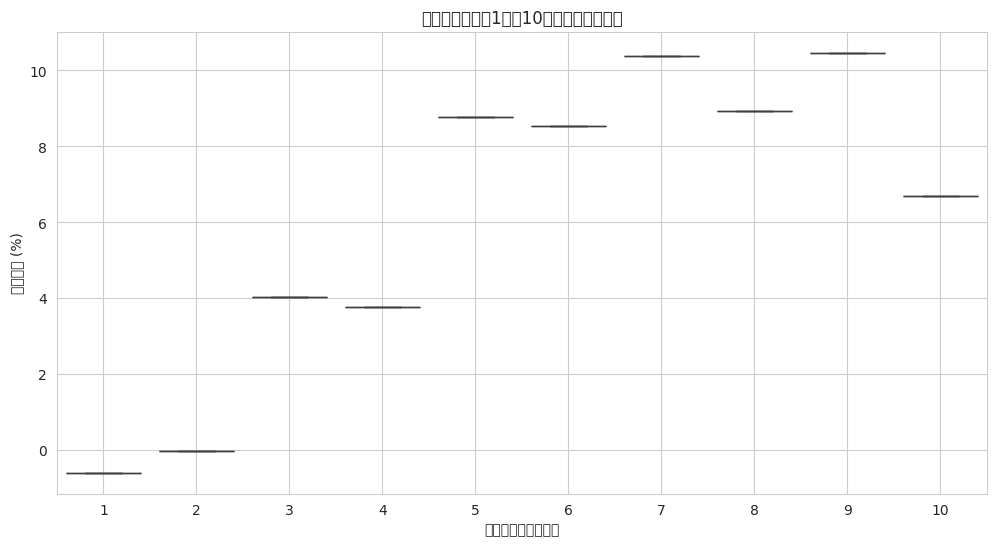


===== ストップロス後1日〜10日リターン（詳細統計） ====


,count,mean,std,min,25%,50%,75%,max
days_after_sl,,,,,,,,
1,1.0,-0.591432,NaN,-0.591432,-0.591432,-0.591432,-0.591432,-0.591432
2,1.0,-0.018770,NaN,-0.018770,-0.018770,-0.018770,-0.018770,-0.018770
3,1.0,4.041498,NaN,4.041498,4.041498,4.041498,4.041498,4.041498
4,1.0,3.778634,NaN,3.778634,3.778634,3.778634,3.778634,3.778634
5,1.0,8.768319,NaN,8.768319,8.768319,8.768319,8.768319,8.768319
6,1.0,8.538305,NaN,8.538305,8.538305,8.538305,8.538305,8.538305
7,1.0,10.383039,NaN,10.383039,10.383039,10.383039,10.383039,10.383039
8,1.0,8.923218,NaN,8.923218,8.923218,8.923218,8.923218,8.923218
9,1.0,10.467521,NaN,10.467521,10.467521,10.467521,10.467521,10.467521


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# df_regime_trades が存在することを確認
if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。OOS トレードログを作成する前のセルを実行してください。")
elif 'df_encoded' not in globals() or df_encoded.empty: # Use df_encoded instead of df
    print("エラー: df_encoded (元の株価データ) が見つからないか空です。データ取得のセルを実行してください。")
else:
    # ストップロスとなったトレードをフィルタリング
    df_stop_loss_trades = df_regime_trades[df_regime_trades['exit_type'] == 'stop_loss'].copy()

    if df_stop_loss_trades.empty:
        print("ストップロスとなったトレードが見つかりませんでした。")
    else:
        # df_encoded を使用して株価データフレームを作成
        df_stock_prices = df_encoded.copy()
        df_stock_prices.index = pd.to_datetime(df_stock_prices.index) # 念のためDatetimeIndexに変換

        df_stop_loss_trades['exit_date'] = pd.to_datetime(df_stop_loss_trades['exit_date'])

        future_returns_data = []

        for idx, trade in df_stop_loss_trades.iterrows():
            exit_date = trade['exit_date']
            # exit_dateの終値が基準
            start_price_date = exit_date

            # 決済日の終値を取得
            if start_price_date in df_stock_prices.index:
                start_price = df_stock_prices.loc[start_price_date]['Close']
            else:
                # 決済日のデータがない場合はスキップ
                continue

            for days_after in range(1, 11): # 1日後から10日後まで
                # 決済日の翌日からリターンを見るため、インデックス位置をずらす
                try:
                    target_date = df_stock_prices.index[df_stock_prices.index.get_loc(start_price_date) + days_after]
                except IndexError: # 未来の日付が存在しない場合
                    break

                if target_date in df_stock_prices.index:
                    end_price = df_stock_prices.loc[target_date]['Close']
                    future_return_pct = (end_price / start_price - 1) * 100
                    future_returns_data.append({
                        'exit_date': exit_date,
                        'days_after_sl': days_after,
                        'return_pct': future_return_pct
                    })
                else:
                    # ターゲット日付がない場合もループを抜けるか、次のトレードへ
                    break # このトレードの残りの日数もデータがない可能性が高い

        if not future_returns_data:
            print("計算できるストップロス後リターンデータがありませんでした。")
        else:
            df_future_returns = pd.DataFrame(future_returns_data)

            # 平均リターンを計算
            avg_returns = df_future_returns.groupby('days_after_sl')['return_pct'].mean().reset_index()

            print("\n===== ストップロス後1日〜10日リターン（平均） ====")
            display(avg_returns)

            # リターンの分布を箱ひげ図で可視化
            plt.figure(figsize=(12, 6))
            sns.boxplot(x='days_after_sl', y='return_pct', data=df_future_returns)
            plt.title('ストップロス後1日〜10日のリターン分布')
            plt.xlabel('ストップロス後日数')
            plt.ylabel('リターン (%)')
            plt.grid(True)
            plt.show()

            # さらに詳細な統計情報を表示
            print("\n===== ストップロス後1日〜10日リターン（詳細統計） ====")
            display(df_future_returns.groupby('days_after_sl')['return_pct'].describe())

In [39]:
import pandas as pd
import numpy as np

# Helper functions (ensuring they are defined or imported here for self-containment)
def calculate_profit_factor(pnls):
    gains = pnls[pnls > 0].sum()
    losses = abs(pnls[pnls < 0].sum())
    if losses == 0 and gains == 0: return np.nan
    return gains / (losses + 1e-9) if losses != 0 else np.inf

def calculate_max_dd_from_pnl(pnls_series, initial_balance=100000):
    if pnls_series.empty or len(pnls_series) < 2:
        return np.nan
    equity_curve = (pnls_series.cumsum() + initial_balance)
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9)
    return dd.min()

# Ensure df_regime_trades is available from previous cells (oos_trade_log converted to DataFrame)
# And volatility_expansion_ratio_series_oos is available from dcb1a3b4
if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。前のセルを実行して OOS トレードログを作成してください。")
elif 'volatility_expansion_ratio_series_oos' not in globals():
    print("エラー: volatility_expansion_ratio_series_oos が見つかりません。OOS検証セルを実行してください。")
else:
    # Map volatility_expansion_ratio_series_oos to trade entry dates in df_regime_trades
    # Ensure entry_date is set as index temporarily for mapping
    df_regime_trades_with_ve = df_regime_trades.set_index('entry_date').copy()
    df_regime_trades_with_ve['volatility_expansion_at_entry'] = volatility_expansion_ratio_series_oos.reindex(df_regime_trades_with_ve.index).fillna(0)
    df_regime_trades_with_ve = df_regime_trades_with_ve.reset_index()

    # 1. Define the OOS period for CAGR calculation (from dcb1a3b4 cell)
    oos_period_start = pd.Timestamp(X_oos.index.min())
    oos_period_end = pd.Timestamp(X_oos.index.max())
    num_days_oos_full_period = (oos_period_end - oos_period_start).days
    if num_days_oos_full_period > 0:
        num_years_oos_full_period = num_days_oos_full_period / 365.25
    else:
        num_years_oos_full_period = 1 # Avoid division by zero if period is 0 days

    initial_balance = 100000  # Consistent initial balance

    # Define groups based on Volatility Expansion
    df_ve_positive = df_regime_trades_with_ve[df_regime_trades_with_ve['volatility_expansion_at_entry'] > 0].copy()
    df_ve_non_positive = df_regime_trades_with_ve[df_regime_trades_with_ve['volatility_expansion_at_entry'] <= 0].copy()

    comparison_results = []

    for name, df_group in [('Volatility Expansion > 0', df_ve_positive), ('Volatility Expansion <= 0', df_ve_non_positive)]:
        if not df_group.empty:
            total_trades = len(df_group)
            win_rate = (df_group['win'].sum() / total_trades * 100) if total_trades > 0 else 0.0
            profit_factor = calculate_profit_factor(df_group['pnl'])
            total_pnl = df_group['pnl'].sum()
            total_return_pct = (total_pnl / initial_balance * 100)

            # CAGRの計算
            if num_years_oos_full_period > 0:
                if (total_return_pct / 100) + 1 <= 0: # Ensure base is positive for power function
                    cagr = np.nan
                else:
                    cagr = (((total_return_pct / 100) + 1)**(1 / num_years_oos_full_period) - 1) * 100
            else:
                cagr = 0.0

        else:
            total_trades = 0
            win_rate = 0.0
            profit_factor = np.nan
            total_return_pct = 0.0
            cagr = 0.0

        comparison_results.append({
            'Volatility Expansion Group': name,
            'Total Trades': total_trades,
            'Win Rate (%)': win_rate,
            'Profit Factor': profit_factor,
            'Average PnL': df_group['pnl'].mean() if not df_group.empty else 0.0,
            'CAGR (%)': cagr
        })

    df_volatility_expansion_comparison = pd.DataFrame(comparison_results)

    # Format numerical columns for better readability
    df_volatility_expansion_comparison['Win Rate (%)'] = df_volatility_expansion_comparison['Win Rate (%)'].map(lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A')
    df_volatility_expansion_comparison['Profit Factor'] = df_volatility_expansion_comparison['Profit Factor'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    df_volatility_expansion_comparison['Average PnL'] = df_volatility_expansion_comparison['Average PnL'].map(lambda x: f'{x:,.2f}' if pd.notna(x) else 'N/A')
    df_volatility_expansion_comparison['CAGR (%)'] = df_volatility_expansion_comparison['CAGR (%)'].map(lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A')

    print("\n===== OOSトレード分析 (Volatility Expansion 別) =====")
    display(df_volatility_expansion_comparison)


===== OOSトレード分析 (Volatility Expansion 別) =====


,Volatility Expansion Group,Total Trades,Win Rate (%),Profit Factor,Average PnL,CAGR (%)
0,Volatility Expansion > 0,10,90.00%,51.7395,"3,531.19",13.10%
1,Volatility Expansion <= 0,6,66.67%,3.8652,"3,368.78",7.78%


In [40]:
import pandas as pd
import numpy as np

# Ensure df_fold_7_trades is available and contains trade details
# and df_encoded is available with technical indicators.
# These should be ready from previous cells.

if 'df_fold_7_trades' not in globals() or df_fold_7_trades.empty:
    print("Error: df_fold_7_trades not found or is empty. Please ensure the relevant backtest cells are run.")
elif 'df_encoded' not in globals():
    print("Error: df_encoded not found. Please ensure the data preparation cells are run.")
else:
    # Convert entry_date to datetime if not already for merging
    df_fold_7_trades['entry_date'] = pd.to_datetime(df_fold_7_trades['entry_date'])

    # Set df_encoded index to datetime for merging
    df_encoded_indexed = df_encoded.set_index(pd.to_datetime(df_encoded.index))

    # Merge the fold 7 trades with df_encoded to get ADX and SMA_diff_abs
    # We'll use SMA_diff_abs as requested by the user, as it's directly used in regime logic.
    df_fold_7_analysis = df_fold_7_trades.set_index('entry_date').copy()
    df_fold_7_analysis['ADX'] = df_encoded_indexed['ADX'].reindex(df_fold_7_analysis.index)
    df_fold_7_analysis['SMA_diff_abs'] = df_encoded_indexed['SMA_diff_abs'].reindex(df_fold_7_analysis.index)
    df_fold_7_analysis = df_fold_7_analysis.reset_index()

    # Rename columns for clarity based on user request
    df_fold_7_analysis.rename(columns={
        'market_regime': 'regime',
        'exit_type': 'exit_reason',
        'trade_return_pct': 'return_pct',
        'entry_date': 'signal_entry_date'
    }, inplace=True)

    # --- 1. All trades in Fold 7 ---
    print("\n===== Fold 7: All Trades (概要) ====")
    display(df_fold_7_analysis[['signal_entry_date', 'return_pct', 'regime', 'entry_score', 'proba', 'ADX', 'SMA_diff_abs', 'exit_reason']])

    # --- 2. Winning Trades ---
    df_winning_trades = df_fold_7_analysis[df_fold_7_analysis['pnl'] > 0].copy()
    print("\n===== Fold 7: Winning Trades (概要) ====")
    display(df_winning_trades[['signal_entry_date', 'return_pct', 'regime', 'entry_score', 'proba', 'ADX', 'SMA_diff_abs', 'exit_reason']])

    # --- 3. Losing Trades ---
    df_losing_trades = df_fold_7_analysis[df_fold_7_analysis['pnl'] < 0].copy()
    print("\n===== Fold 7: Losing Trades (概要) ====")
    display(df_losing_trades[['signal_entry_date', 'return_pct', 'regime', 'entry_score', 'proba', 'ADX', 'SMA_diff_abs', 'exit_reason']])

    # --- 4. Top 3 Significant Losing Trades ---
    if not df_losing_trades.empty:
        df_significant_losses = df_losing_trades.nsmallest(3, 'pnl')
        print("\n===== Fold 7: Top 3 Significant Losing Trades (概要) ====")
        display(df_significant_losses[['signal_entry_date', 'return_pct', 'regime', 'entry_score', 'proba', 'ADX', 'SMA_diff_abs', 'exit_reason']])
    else:
        print("Fold 7に負けトレードが見つかりませんでした。")

    # --- 5. Summary Statistics for Winning vs. Losing ---
    print("\n===== Fold 7: Winning vs. Losing Trades (要約統計) ====")
    comparison_stats = pd.DataFrame({
        'Metric': ['Average Return (%)', 'Average entry_score', 'Average Proba', 'Average ADX', 'Average SMA_diff_abs', 'Dominant Regime', 'Dominant Exit Reason']
    })

    if not df_winning_trades.empty:
        winning_avg_return = df_winning_trades['return_pct'].mean() * 100
        winning_avg_entry_score = df_winning_trades['entry_score'].mean()
        winning_avg_proba = df_winning_trades['proba'].mean()
        winning_avg_adx = df_winning_trades['ADX'].mean()
        winning_avg_smadiff = df_winning_trades['SMA_diff_abs'].mean()
        winning_dominant_regime = df_winning_trades['regime'].mode()[0] if not df_winning_trades['regime'].empty else 'N/A'
        winning_dominant_exit = df_winning_trades['exit_reason'].mode()[0] if not df_winning_trades['exit_reason'].empty else 'N/A'

        comparison_stats['Winning Trades'] = [
            f'{winning_avg_return:.2f}%',
            f'{winning_avg_entry_score:.2f}',
            f'{winning_avg_proba:.4f}',
            f'{winning_avg_adx:.2f}',
            f'{winning_avg_smadiff:.2f}',
            winning_dominant_regime,
            winning_dominant_exit
        ]
    else:
        comparison_stats['Winning Trades'] = ['N/A'] * len(comparison_stats)

    if not df_losing_trades.empty:
        losing_avg_return = df_losing_trades['return_pct'].mean() * 100
        losing_avg_entry_score = df_losing_trades['entry_score'].mean()
        losing_avg_proba = df_losing_trades['proba'].mean()
        losing_avg_adx = df_losing_trades['ADX'].mean()
        losing_avg_smadiff = df_losing_trades['SMA_diff_abs'].mean()
        losing_dominant_regime = df_losing_trades['regime'].mode()[0] if not df_losing_trades['regime'].empty else 'N/A'
        losing_dominant_exit = df_losing_trades['exit_reason'].mode()[0] if not df_losing_trades['exit_reason'].empty else 'N/A'

        comparison_stats['Losing Trades'] = [
            f'{losing_avg_return:.2f}%',
            f'{losing_avg_entry_score:.2f}',
            f'{losing_avg_proba:.4f}',
            f'{losing_avg_adx:.2f}',
            f'{losing_avg_smadiff:.2f}',
            losing_dominant_regime,
            losing_dominant_exit
        ]
    else:
        comparison_stats['Losing Trades'] = ['N/A'] * len(comparison_stats)

    display(comparison_stats)

    print("\n--- 分析結果 ---")
    print("負けトレードの状況を勝っているトレードと比較することで、Fold 7が崩れる原因特定の手がかりを探します。")


===== Fold 7: All Trades (概要) ====


,signal_entry_date,return_pct,regime,entry_score,proba,ADX,SMA_diff_abs,exit_reason
0,2024-07-31,-0.103987,uptrend,28.920095,0.754133,40.046484,35.802737,stop_loss
1,2024-08-09,0.061849,uptrend,35.416069,0.543668,62.145503,30.158503,trailing_stop
2,2024-09-10,0.055067,uptrend,15.792425,0.640588,42.462594,14.418210,trailing_stop
3,2024-09-27,0.003512,uptrend,16.993283,0.497958,35.374297,3.178407,trailing_stop



===== Fold 7: Winning Trades (概要) ====


,signal_entry_date,return_pct,regime,entry_score,proba,ADX,SMA_diff_abs,exit_reason
1,2024-08-09,0.061849,uptrend,35.416069,0.543668,62.145503,30.158503,trailing_stop
2,2024-09-10,0.055067,uptrend,15.792425,0.640588,42.462594,14.418210,trailing_stop
3,2024-09-27,0.003512,uptrend,16.993283,0.497958,35.374297,3.178407,trailing_stop



===== Fold 7: Losing Trades (概要) ====


...


===== Fold 7: Top 3 Significant Losing Trades (概要) ====


,signal_entry_date,return_pct,regime,entry_score,proba,ADX,SMA_diff_abs,exit_reason
0,2024-07-31,-0.103987,uptrend,28.920095,0.754133,40.046484,35.802737,stop_loss



===== Fold 7: Winning vs. Losing Trades (要約統計) ====


,Metric,Winning Trades,Losing Trades
0,Average Return (%),4.01%,-10.40%
1,Average entry_score,22.73,28.92
2,Average Proba,0.5607,0.7541
3,Average ADX,46.66,40.05
4,Average SMA_diff_abs,15.92,35.80
5,Dominant Regime,uptrend,uptrend
6,Dominant Exit Reason,trailing_stop,stop_loss



--- 分析結果 ---
負けトレードの状況を勝っているトレードと比較することで、Fold 7が崩れる原因特定の手がかりを探します。


#### 新規定義された`regime_label`（20営業日先リターンベース）でのOOSトレード分析

前のターンで定義された20営業日先リターンに基づく市場レジーム分類 (`regime_label`) を使用して、OOS期間のトレードパフォーマンスを分析します。

これにより、戦略が各市場レジームでどのように機能したかを理解できます。

In [41]:
import pandas as pd
import numpy as np

# Helper functions (ensure they are defined or imported here for self-containment)
def calculate_profit_factor(pnls):
    gains = pnls[pnls > 0].sum()
    losses = abs(pnls[pnls < 0].sum())
    if losses == 0 and gains == 0: return np.nan
    return gains / (losses + 1e-9) if losses != 0 else np.inf

def calculate_sharpe_ratio(returns_pct):
    returns_pct = returns_pct.dropna()
    if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
        return np.nan
    return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

def calculate_max_dd_from_pnl(pnls_series, initial_balance=100000):
    if pnls_series.empty or len(pnls_series) < 2:
        return np.nan
    equity_curve = (pnls_series.cumsum() + initial_balance)
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9)
    return dd.min()

# 1. regime_labelの作成（前回の指示に基づく）
lookahead_days = 10 # ユーザー定義
bear_threshold = -0.03 # ユーザー定義

df_labeled = df_encoded.copy()

# Calculate future_return_20d
df_labeled['future_return_20d'] = df_labeled['Close'].pct_change(lookahead_days).shift(-lookahead_days)

# Create bear_label
df_labeled['bear_label'] = (df_labeled['future_return_20d'] <= bear_threshold).astype(int)

# future_return_20dがNaNの行を削除（これらは予測できないため）
df_labeled.dropna(subset=['bear_label'], inplace=True)

# Remove old regime_label and future_return columns if they exist to avoid confusion
# (These were from the previous 3-class regime definition)
if 'regime_label' in df_labeled.columns:
    df_labeled = df_labeled.drop(columns=['regime_label'])
if 'future_return' in df_labeled.columns:
    df_labeled = df_labeled.drop(columns=['future_return'])

# The rest of the original cell content (OOS trade analysis) is moved to new cells or removed as it's not relevant to target creation.

In [42]:
print("--- Definition of Market Regimes (Uptrend/Bull) ---")

# Assuming df_encoded and best_strategy_params are available from previous cells
# We'll use a snapshot of the logic from the OOS backtest setup as it's directly used for trading decisions.
# The relevant series are:
# adx_series = df_encoded["ADX"]
# sma_50_series = df_encoded["SMA_50"]
# sma_200_series = df_encoded["SMA_200"]
# sma_diff_abs_series = df_encoded["SMA_diff_abs"]

# For demonstration, let's use the full df_encoded and best_strategy_params
# as they would be during a backtest evaluation.

# Ensure these series are available or re-create them for clarity
adx_series = df_encoded["ADX"]
sma_50_series = df_encoded["SMA_50"]
sma_200_series = df_encoded["SMA_200"]
sma_diff_abs_series = df_encoded["SMA_diff_abs"]

# Retrieve thresholds from best_strategy_params
adx_sideways_th = best_strategy_params.get('adx_sideways_th', 20.0) # Default if not found
trend_strength_sideways_th = best_strategy_params.get('trend_strength_sideways_th', 2.0) # Default if not found

# Condition for sideways regime
cond_sideways = (adx_series < adx_sideways_th) | \
                (sma_diff_abs_series < trend_strength_sideways_th)

# Condition for uptrend (Bull) regime
cond_uptrend = ~cond_sideways & (sma_50_series > sma_200_series)

# Display a sample of the conditions
print(f"ADX Sideways Threshold: {adx_sideways_th:.2f}")
print(f"Trend Strength Sideways Threshold: {trend_strength_sideways_th:.2f}")

print("\n--- Sample of Regime Conditions ---")
display(pd.DataFrame({
    'ADX': adx_series,
    'SMA_50': sma_50_series,
    'SMA_200': sma_200_series,
    'SMA_diff_abs': sma_diff_abs_series,
    'cond_sideways': cond_sideways,
    'cond_uptrend (Bull)': cond_uptrend
}).tail())


--- Definition of Market Regimes (Uptrend/Bull) ---
ADX Sideways Threshold: 19.85
Trend Strength Sideways Threshold: 2.85

--- Sample of Regime Conditions ---


,ADX,SMA_50,SMA_200,SMA_diff_abs,cond_sideways,cond_uptrend (Bull)
Date,,,,,,
2026-06-11,20.587117,481.617300,350.598917,131.018383,False,True
2026-06-12,19.555492,486.769053,352.330328,134.438725,True,False
2026-06-15,18.015175,492.549077,354.221715,138.327363,True,False
2026-06-16,16.934589,497.495143,355.921030,141.574114,True,False
2026-06-17,15.854003,502.537844,357.698777,144.839068,True,False


### 市場レジーム予測のための特徴量とターゲットの準備

ここでは、`df_labeled` DataFrameから特徴量（X）と目的変数（y）を準備します。目的変数は、以前のターンで定義された20営業日先リターンに基づく市場レジーム分類である`regime_label`です。特徴量としては、元のデータフレームから導出されたテクニカル指標の大部分を使用しますが、将来の情報を漏洩する可能性のある列や、目的変数と直接関連する既存の市場レジーム分類は除外します。

In [43]:
import pandas as pd
import numpy as np

# df_labeled はすでに存在すると仮定
# future_return_20d と bear_label は目的変数なので特徴量からは除外
# Market_Regime_ (元のレジーム分類) も予測対象レジームと混同しないように除外

# 特徴量として使用する列を定義
# ここでは、元の特徴量リストから将来情報とレジーム関連のものを除外します。
# df_labeled は df のコピーなので、df の特徴量がすべて含まれています。
# ただし、Market_Regime_xxx はワンホットエンコードされたものなので除外

features_for_bear_prediction = [
    'SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO',
    'RSI', 'MACD', 'Signal_Line', 'MACD_Hist',
    'ATR',
    'Upper_BB', 'Lower_BB', 'BB_Width',
    'Volatility_Short',
    'Volatility_Expansion_Ratio',
    'ADX',
    'ADX_normalized',
    'SMA_diff_abs',
    'RET_3', 'RET_5', 'RET_10',
    'VOL_10', 'VOL_20', 'VOL_RATIO',
    'RANGE_SCORE',
    'MOMENTUM',
    'TREND_STRENGTH',
    'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_4', 'Close_Lag_5'
]

# 実際にdf_labeledに存在する特徴量のみを選択
features_for_bear_prediction = [f for f in features_for_bear_prediction if f in df_labeled.columns]

X_bear = df_labeled[features_for_bear_prediction].copy()
y_bear = df_labeled['bear_label'].copy() # Changed target to 'bear_label'

# 最終チェックとNaN値の処理
X_bear.dropna(inplace=True)
y_bear = y_bear.loc[X_bear.index] # Xに合わせたインデックスにする

print("X_bear shape:", X_bear.shape)
print("y_bear shape:", y_bear.shape)
print("bear_label の分布:")
print(y_bear.value_counts(normalize=True))

# ユーザーが指定した分析タスクのために、年ごとの分布も計算
print("\nbear_label の年別分布:")
y_bear_annual_dist = y_bear.groupby(y_bear.index.year).value_counts(normalize=True).unstack(fill_value=0)
print(y_bear_annual_dist)



X_bear shape: (1397, 24)
y_bear shape: (1397,)
bear_label の分布:
bear_label
0    0.762348
1    0.237652
Name: proportion, dtype: float64

bear_label の年別分布:
bear_label         0         1
Date                          
2020        1.000000  0.000000
2021        0.793651  0.206349
2022        0.573705  0.426295
2023        0.796000  0.204000
2024        0.761905  0.238095
2025        0.812000  0.188000
2026        0.869565  0.130435


### TimeSeriesSplit を用いた RandomForest モデルの学習と評価

指定された`regime_label`を目的変数として、`RandomForestClassifier`モデルを学習します。時系列データの特性を考慮し、`TimeSeriesSplit`を使用してモデルを評価します。各フォールドでモデルのパフォーマンス（精度、適合率、再現率、F1スコア）を評価し、全体的な堅牢性を確認します。

RandomForestモデルの学習とTimeSeriesSplitでの評価を開始します...

----- Fold 1 -----
Accuracy: 0.5733
Precision (Bear): 0.5000
Recall (Bear): 0.0909
F1-Score (Bear): 0.1538

Confusion Matrix:
[[124   9]
 [ 90   9]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.58      0.93      0.71       133
        Bear       0.50      0.09      0.15        99

    accuracy                           0.57       232
   macro avg       0.54      0.51      0.43       232
weighted avg       0.55      0.57      0.48       232



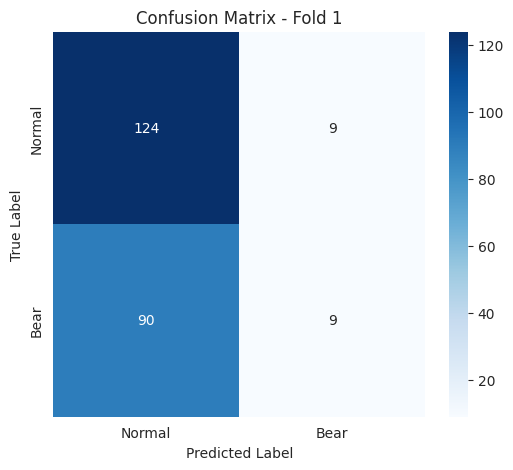


----- Fold 2 -----
Accuracy: 0.7241
Precision (Bear): 0.2826
Recall (Bear): 0.2955
F1-Score (Bear): 0.2889

Confusion Matrix:
[[155  33]
 [ 31  13]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.83      0.82      0.83       188
        Bear       0.28      0.30      0.29        44

    accuracy                           0.72       232
   macro avg       0.56      0.56      0.56       232
weighted avg       0.73      0.72      0.73       232



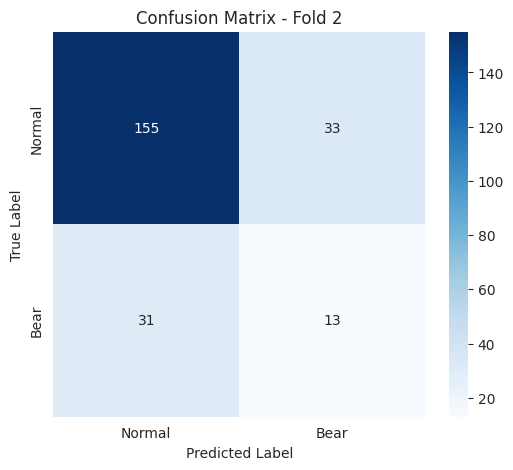


----- Fold 3 -----
Accuracy: 0.7672
Precision (Bear): 0.5000
Recall (Bear): 0.0370
F1-Score (Bear): 0.0690

Confusion Matrix:
[[176   2]
 [ 52   2]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.77      0.99      0.87       178
        Bear       0.50      0.04      0.07        54

    accuracy                           0.77       232
   macro avg       0.64      0.51      0.47       232
weighted avg       0.71      0.77      0.68       232



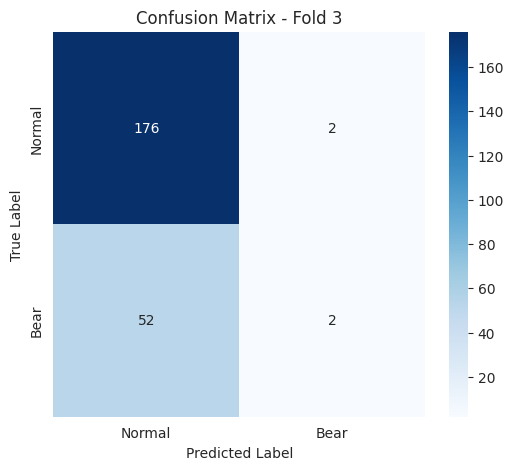


----- Fold 4 -----
Accuracy: 0.7543
Precision (Bear): 1.0000
Recall (Bear): 0.0172
F1-Score (Bear): 0.0339

Confusion Matrix:
[[174   0]
 [ 57   1]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.75      1.00      0.86       174
        Bear       1.00      0.02      0.03        58

    accuracy                           0.75       232
   macro avg       0.88      0.51      0.45       232
weighted avg       0.81      0.75      0.65       232



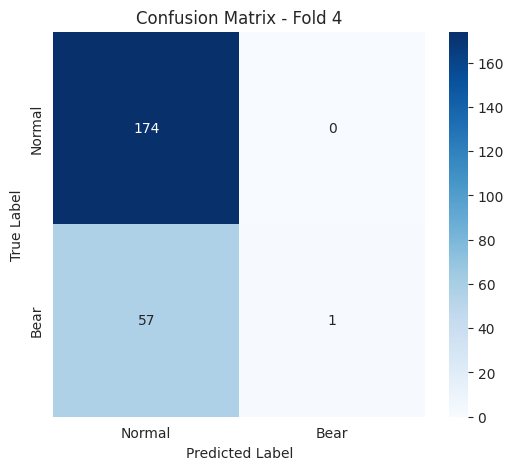


----- Fold 5 -----
Accuracy: 0.4526
Precision (Bear): 0.1745
Recall (Bear): 0.8667
F1-Score (Bear): 0.2905

Confusion Matrix:
[[ 79 123]
 [  4  26]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.39      0.55       202
        Bear       0.17      0.87      0.29        30

    accuracy                           0.45       232
   macro avg       0.56      0.63      0.42       232
weighted avg       0.85      0.45      0.52       232



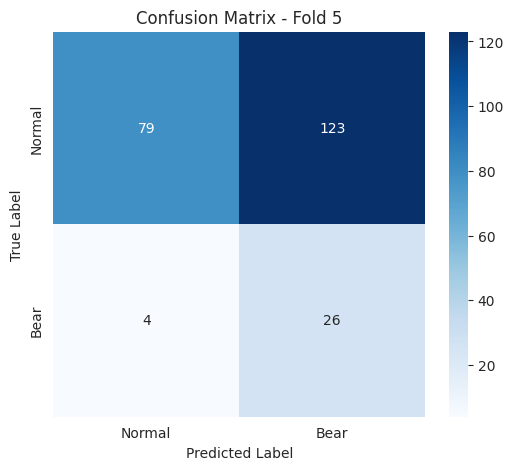


----- 全体的な評価 -----
平均Accuracy: 0.6543
平均Precision (Bear): 0.4914
平均Recall (Bear): 0.2615
平均F1-Score (Bear): 0.1672


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score
import random
import matplotlib.pyplot as plt
import seaborn as sns

seed = 42
np.random.seed(seed)
random.seed(seed)

# TimeSeriesSplit の設定
tscv = TimeSeriesSplit(n_splits=5) # 5分割で評価

all_fold_accuracies = []
all_fold_precisions = []
all_fold_recalls = []
all_fold_f1_scores = []
all_fold_cm = []
# all_fold_reports = [] # For overall summary if needed

print("RandomForestモデルの学習とTimeSeriesSplitでの評価を開始します...")

# BearラベルのRecallを重視するため、ターゲット名を明確にする
target_names = ['Normal', 'Bear'] # 0: Normal, 1: Bear

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_bear)): # Changed to X_bear, y_bear
    print(f"\n----- Fold {fold + 1} -----")
    X_train, X_test = X_bear.iloc[train_idx], X_bear.iloc[test_idx]
    y_train, y_test = y_bear.iloc[train_idx], y_bear.iloc[test_idx]

    # スケーリング
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # RandomForestClassifier の初期化と学習
    # class_weight='balanced' を設定
    model = RandomForestClassifier(n_estimators=100, random_state=seed, class_weight='balanced', n_jobs=-1)
    model.fit(X_train_scaled, y_train)

    # 予測
    y_pred = model.predict(X_test_scaled)

    # 評価
    accuracy = accuracy_score(y_test, y_pred)
    # precision_bear, recall_bear, f1_bear for the positive class (Bear=1)
    precision_bear = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall_bear = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_bear = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names, zero_division=0)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (Bear): {precision_bear:.4f}")
    print(f"Recall (Bear): {recall_bear:.4f}")
    print(f"F1-Score (Bear): {f1_bear:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(report)

    all_fold_accuracies.append(accuracy)
    all_fold_precisions.append(precision_bear)
    all_fold_recalls.append(recall_bear)
    all_fold_f1_scores.append(f1_bear)
    all_fold_cm.append(cm)

    # Confusion Matrixの可視化
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

print("\n----- 全体的な評価 -----")
print(f"平均Accuracy: {np.mean(all_fold_accuracies):.4f}")
print(f"平均Precision (Bear): {np.mean(all_fold_precisions):.4f}")
print(f"平均Recall (Bear): {np.mean(all_fold_recalls):.4f}")
print(f"平均F1-Score (Bear): {np.mean(all_fold_f1_scores):.4f}")

### 2022年単独テスト

ここでは、モデルを2022年以前のデータで学習し、2022年のデータでパフォーマンスを評価する単独テストを実行します。これにより、特定の期間におけるモデルの予測能力を詳細に分析します。

トレーニングデータ期間: 2020-11-23 - 2021-12-31 (Shape: (279, 24))
テストデータ期間 (2022年): 2022-01-03 - 2022-12-30 (Shape: (251, 24))

----- 2022年単独テスト結果 -----
Accuracy: 0.5737
Precision (Bear): 0.0000
Recall (Bear): 0.0000
F1-Score (Bear): 0.0000

Confusion Matrix:
[[144   0]
 [107   0]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.57      1.00      0.73       144
        Bear       0.00      0.00      0.00       107

    accuracy                           0.57       251
   macro avg       0.29      0.50      0.36       251
weighted avg       0.33      0.57      0.42       251



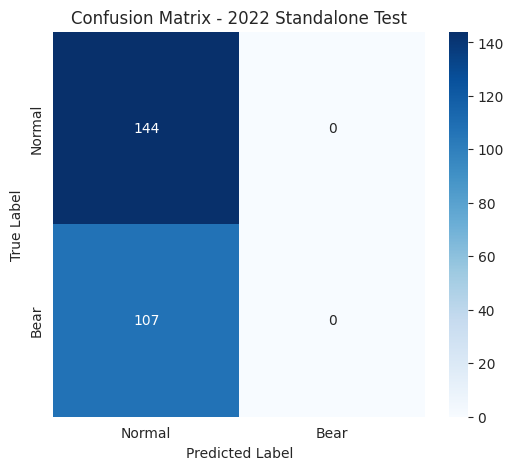

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

seed = 42
np.random.seed(seed)
random.seed(seed)

# 2022年をテスト期間、それ以前を学習期間とする
test_year_start = '2022-01-01'
test_year_end = '2022-12-31'

# データ分割
X_train_2022 = X_bear[X_bear.index < test_year_start]
y_train_2022 = y_bear[y_bear.index < test_year_start]
X_test_2022 = X_bear[(X_bear.index >= test_year_start) & (X_bear.index <= test_year_end)]
y_test_2022 = y_bear[(y_bear.index >= test_year_start) & (y_bear.index <= test_year_end)]

print(f"トレーニングデータ期間: {X_train_2022.index.min().strftime('%Y-%m-%d')} - {X_train_2022.index.max().strftime('%Y-%m-%d')} (Shape: {X_train_2022.shape})")
print(f"テストデータ期間 (2022年): {X_test_2022.index.min().strftime('%Y-%m-%d')} - {X_test_2022.index.max().strftime('%Y-%m-%d')} (Shape: {X_test_2022.shape})")

if X_test_2022.empty:
    print("エラー: 2022年のテストデータが見つかりません。データと期間設定を確認してください。")
else:
    # スケーリング
    scaler_2022 = StandardScaler()
    X_train_scaled_2022 = scaler_2022.fit_transform(X_train_2022)
    X_test_scaled_2022 = scaler_2022.transform(X_test_2022)

    # RandomForestClassifier の初期化と学習
    model_2022 = RandomForestClassifier(n_estimators=100, random_state=seed, class_weight='balanced', n_jobs=-1)
    model_2022.fit(X_train_scaled_2022, y_train_2022)

    # 予測
    y_pred_2022 = model_2022.predict(X_test_scaled_2022)

    # 評価
    accuracy_2022 = accuracy_score(y_test_2022, y_pred_2022)
    precision_bear_2022 = precision_score(y_test_2022, y_pred_2022, pos_label=1, zero_division=0)
    recall_bear_2022 = recall_score(y_test_2022, y_pred_2022, pos_label=1, zero_division=0)
    f1_bear_2022 = f1_score(y_test_2022, y_pred_2022, pos_label=1, zero_division=0)
    cm_2022 = confusion_matrix(y_test_2022, y_pred_2022)
    report_2022 = classification_report(y_test_2022, y_pred_2022, target_names=['Normal', 'Bear'], zero_division=0)

    print("\n----- 2022年単独テスト結果 -----")
    print(f"Accuracy: {accuracy_2022:.4f}")
    print(f"Precision (Bear): {precision_bear_2022:.4f}")
    print(f"Recall (Bear): {recall_bear_2022:.4f}")
    print(f"F1-Score (Bear): {f1_bear_2022:.4f}")
    print("\nConfusion Matrix:")
    print(cm_2022)
    print("\nClassification Report:")
    print(report_2022)

    # Confusion Matrixの可視化
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_2022, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Bear'], yticklabels=['Normal', 'Bear'])
    plt.title('Confusion Matrix - 2022 Standalone Test')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


===== Feature Importances (RandomForest Classifier) =====
         Feature  Importance
13  SMA_diff_abs    0.059193
4    Signal_Line    0.058555
15        VOL_20    0.054380
3           MACD    0.053985
1         SMA_25    0.053873
6            ATR    0.053577
12           ADX    0.052722
9       BB_Width    0.051123
8       Lower_BB    0.049958
14        VOL_10    0.046525


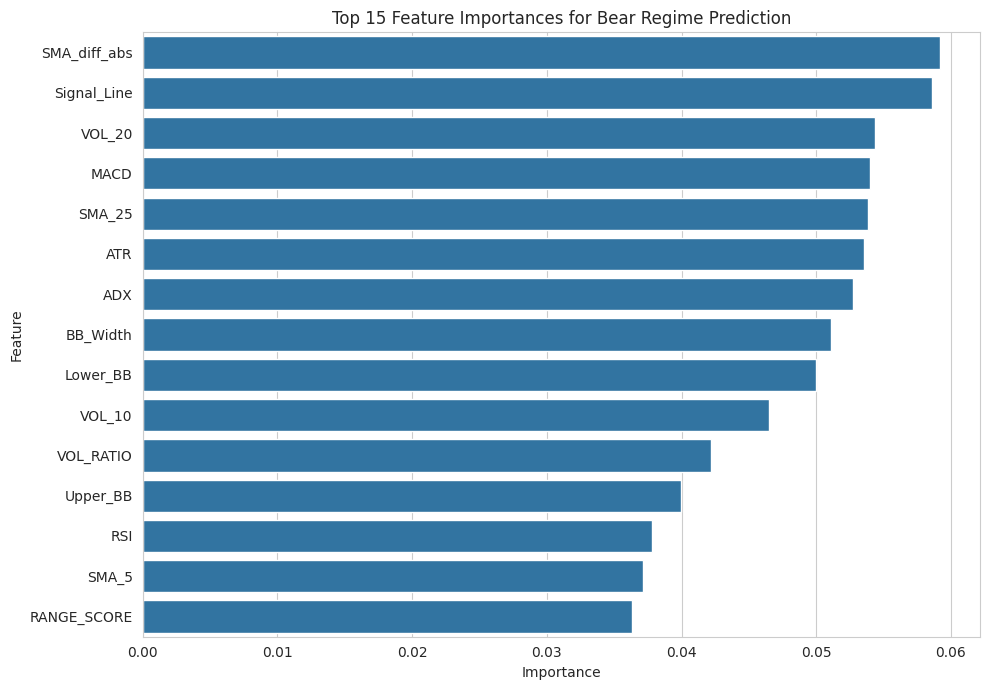

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the last trained model from TimeSeriesSplit (last fold) is available in 'model'
# And X_bear.columns contains the feature names

if 'model' in locals() and 'X_bear' in globals():
    feature_importances = model.feature_importances_
    features = X_bear.columns

    importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print("\n===== Feature Importances (RandomForest Classifier) =====")
    print(importance_df.head(10))

    # Plotting feature importances
    plt.figure(figsize=(10, 7))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
    plt.title('Top 15 Feature Importances for Bear Regime Prediction')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Error: Model or X_bear not found. Please ensure previous cells (model training) were executed.")

### ウォークフォワード検証の結果概要

In [47]:
import json
import pandas as pd
import os

try:
    # Use the correct path to the best_params.json file defined in LUK3w6ls2Gkq
    with open(BEST_PARAMS_PATH, "r") as f:
        best_result_data = json.load(f)

    # The save_callback only saves the 'score', 'model_params', and 'strategy_params'.
    # 'fold_metrics' and 'total_trades_overall' are not stored in best_params.json.
    best_score = best_result_data.get("score")
    fold_metrics = best_result_data.get("fold_metrics")
    total_trades_overall = best_result_data.get("total_trades_overall")

    print("===== Optuna最適化のベストスコア =====")
    if best_score is not None:
        print(f"総合スコア: {best_score:.4f}")
    else:
        print("総合スコア: N/A (スコアがJSONファイルに見つかりません)")

    if fold_metrics:
        df_fold_results = pd.DataFrame(fold_metrics)
        print("\n===== ウォークフォワード各フォールドのメトリクス =====")
        display(df_fold_results)
        print("\n===== ウォークフォワードメトリクス (平均) =====")
        display(df_fold_results.mean().to_frame().T)
    else:
        print("\n注: 各フォールドのメトリクスと総取引回数はbest_params.jsonに保存されていないため表示されません。")

    if total_trades_overall is not None:
        print(f"\n全フォールドでの総取引回数: {total_trades_overall}")
    else:
        print("\n全フォールドでの総取引回数: N/A (総取引回数がJSONファイルに見つかりません)")


except FileNotFoundError:
    print(f"エラー: {BEST_PARAMS_PATH} が見つかりません。Optunaの実行を確認してください。")
except Exception as e:
    print(f"エラー発生: {e}")

===== Optuna最適化のベストスコア =====
総合スコア: -55.5103

===== ウォークフォワード各フォールドのメトリクス =====


,sharpe,total_return,buy_hold_return,alpha,max_dd,total_trades,pf,win_rate
0,2.031380,3.815225,24.920325,-21.105100,-0.007236,1,5.485162,100.0
1,0.272979,0.590644,-17.113256,17.703901,-0.019056,1,1.198181,100.0
2,-0.377884,-0.066904,-13.499410,13.432506,-0.001962,2,0.842924,50.0
3,1.269954,3.077432,7.667893,-4.590461,-0.017769,2,1.806746,100.0
4,-0.248893,-0.676091,-8.071751,7.395660,-0.035463,2,0.912368,50.0
5,1.831574,0.187945,3.998779,-3.810834,-0.000763,1,2.776191,100.0
6,0.246804,1.096920,36.118417,-35.021497,-0.060869,1,1.179210,100.0
7,2.261895,17.186277,101.759704,-84.573427,-0.047436,4,2.105298,100.0



===== ウォークフォワードメトリクス (平均) =====


,sharpe,total_return,buy_hold_return,alpha,max_dd,total_trades,pf,win_rate
0,0.910976,3.151431,16.972588,-13.821156,-0.023819,1.75,2.03826,87.5



全フォールドでの総取引回数: 14


#### 期間分析: TimeSeriesSplitの7番目のフォールド

### Fold 9およびFold 10のトレード詳細とパフォーマンス分析の再実行準備

`trade_logs_for_plotting` が空のため、以前の分析が実行できませんでした。Optunaのメイン最適化を実行し、ベストパラメータをロードした後、クロスバリデーション分析を再実行してトレードログを生成します。その後、Fold 9とFold 10の分析を再度実行します。

#### Optunaメイン最適化の実行

`best_params.json`ファイルを生成するために、Optunaのメイン最適化(`LUK3w6ls2Gkq`)を実行します。これにより、クロスバリデーション分析で必要な最適パラメータがロードできるようになります。

#### Fold 9およびFold 10のトレード詳細とパフォーマンス分析の実行

`trade_logs_for_plotting`が正しく初期化されたので、Fold 9とFold 10のトレード分析を再実行します。

In [48]:
import pandas as pd
import numpy as np

# Ensure trade_logs_for_plotting is available from the cross-validation analysis
if 'trade_logs_for_plotting' not in globals() or not trade_logs_for_plotting:
    print("エラー: 'trade_logs_for_plotting' が見つからないか空です。前のクロスバリデーション分析セルが実行されていることを確認してください。")
    df_fold9_trades = pd.DataFrame()
    df_fold10_trades = pd.DataFrame()
else:
    # Folds are 0-indexed, so Fold 9 is at index 8 and Fold 10 is at index 9
    if len(trade_logs_for_plotting) > 8:
        df_fold9_trades = pd.DataFrame(trade_logs_for_plotting[8])
        df_fold9_trades['Fold'] = 9
    else:
        print("警告: Fold 9 のトレードログが見つかりません。")
        df_fold9_trades = pd.DataFrame()

    if len(trade_logs_for_plotting) > 9:
        df_fold10_trades = pd.DataFrame(trade_logs_for_plotting[9])
        df_fold10_trades['Fold'] = 10
    else:
        print("警告: Fold 10 のトレードログが見つかりません。")
        df_fold10_trades = pd.DataFrame()

# Combine Fold 9 and Fold 10 trades
df_combined_trades = pd.concat([df_fold9_trades, df_fold10_trades], ignore_index=True)

# Ensure df_encoded (original data with Close prices) is available
if 'df_encoded' not in globals() or df_encoded.empty:
    print("エラー: 'df_encoded' が見つからないか空です。データ取得と特徴量作成のセルを実行してください。")
    df_stock_prices = pd.DataFrame()
else:
    df_stock_prices = df_encoded.copy()
    df_stock_prices.index = pd.to_datetime(df_stock_prices.index)


if not df_combined_trades.empty and not df_stock_prices.empty:
    # Convert date columns to datetime objects
    df_combined_trades['entry_date'] = pd.to_datetime(df_combined_trades['entry_date'])
    df_combined_trades['exit_date'] = pd.to_datetime(df_combined_trades['exit_date'])

    # Calculate future returns after exit
    future_returns_data = []

    for idx, trade in df_combined_trades.iterrows():
        exit_date = trade['exit_date']
        start_price = df_stock_prices.loc[exit_date, 'Close'] if exit_date in df_stock_prices.index else np.nan

        if pd.isna(start_price):
            df_combined_trades.loc[idx, 'Exit後5日リターン'] = np.nan
            df_combined_trades.loc[idx, 'Exit後10日リターン'] = np.nan
            continue

        # Find the index of the exit_date in df_stock_prices using searchsorted for 'nearest' functionality
        # This handles the case where `method='nearest'` is not supported by `get_loc`
        df_prices_index = df_stock_prices.index
        # Find the insertion point for exit_date
        idx_right = df_prices_index.searchsorted(exit_date, side='left')

        if idx_right == len(df_prices_index): # exit_date is after the last date
            exit_loc = len(df_prices_index) - 1
        elif idx_right == 0: # exit_date is before the first date
            exit_loc = 0
        else:
            # Compare distance to the left and right dates
            left_date = df_prices_index[idx_right - 1]
            right_date = df_prices_index[idx_right]
            if abs(exit_date - left_date) < abs(exit_date - right_date):
                exit_loc = idx_right - 1
            else:
                exit_loc = idx_right

        # Calculate 5-day return
        days_after_5 = 5
        if exit_loc + days_after_5 < len(df_stock_prices.index):
            target_date_5 = df_stock_prices.index[exit_loc + days_after_5]
            end_price_5 = df_stock_prices.loc[target_date_5, 'Close']
            df_combined_trades.loc[idx, 'Exit後5日リターン'] = (end_price_5 / start_price - 1) * 100
        else:
            df_combined_trades.loc[idx, 'Exit後5日リターン'] = np.nan

        # Calculate 10-day return
        days_after_10 = 10
        if exit_loc + days_after_10 < len(df_stock_prices.index):
            target_date_10 = df_stock_prices.index[exit_loc + days_after_10]
            end_price_10 = df_stock_prices.loc[target_date_10, 'Close']
            df_combined_trades.loc[idx, 'Exit後10日リターン'] = (end_price_10 / start_price - 1) * 100
        else:
            df_combined_trades.loc[idx, 'Exit後10日リターン'] = np.nan


    # Display all trades for Fold 10 only with requested columns
    print("\n===== Fold 10 トレード詳細 ====")
    df_fold10_display = df_combined_trades[df_combined_trades['Fold'] == 10].rename(columns={
        'entry_date': 'Entry Date',
        'exit_date': 'Exit Date',
        'trade_return_pct': 'Return (%)',
        'exit_type': 'Exit Type',
        'bars_held': 'Bars Held'
    })
    display(df_fold10_display[[
        'Entry Date', 'Exit Date', 'Return (%)', 'Exit Type', 'Bars Held',
        'Exit後10日リターン'
    ]])

    # Aggregate by Exit Type
    print("\n===== Exit Type別 集計 ====")
    exit_type_summary = df_combined_trades.groupby('exit_type').agg(
        回数=('pnl', 'size'),
        平均利益=('pnl', 'mean'),
        利益合計=('pnl', 'sum')
    ).reset_index()
    exit_type_summary.rename(columns={'exit_type': 'Exit Type'}, inplace=True)
    display(exit_type_summary)

else:
    print("トレードデータまたは株価データが不足しているため、分析を実行できませんでした。")


===== Fold 10 トレード詳細 ====


,Entry Date,Exit Date,Return (%),Exit Type,Bars Held,Exit後10日リターン
1,2026-01-26,2026-02-03,0.033536,trailing_stop,6,3.552835
2,2026-02-05,2026-02-13,0.064943,trailing_stop,6,-0.735914
3,2026-03-17,2026-03-26,-0.016676,trailing_stop,7,17.561200
4,2026-03-31,2026-04-23,0.323400,trailing_stop,16,11.646254
5,2026-04-24,2026-05-04,-0.006867,trailing_stop,6,7.317230
6,2026-05-05,2026-05-13,0.077291,trailing_stop,6,7.794963
7,2026-05-14,2026-05-27,0.063584,trailing_stop,8,-3.984176



===== Exit Type別 集計 ====


,Exit Type,回数,平均利益,利益合計
0,trailing_stop,8,1273.90494,10191.239517


### Fold 9およびFold 10のトレード詳細とパフォーマンス分析

ここでは、ウォークフォワード検証のFold 9およびFold 10における各トレードの詳細を表示します。さらに、決済後の市場の動きを評価するために、決済日からの5日後および10日後のリターンを計算します。最後に、Exit Type（決済理由）ごとの集計メトリクスも提供します。

In [49]:
import pandas as pd
import numpy as np

# Ensure trade_logs_for_plotting is available from the cross-validation analysis
if 'trade_logs_for_plotting' not in globals() or not trade_logs_for_plotting:
    print("エラー: 'trade_logs_for_plotting' が見つからないか空です。前のクロスバリデーション分析セルが実行されていることを確認してください。")
    df_fold9_trades = pd.DataFrame()
    df_fold10_trades = pd.DataFrame()
else:
    # Folds are 0-indexed, so Fold 9 is at index 8 and Fold 10 is at index 9
    if len(trade_logs_for_plotting) > 8:
        df_fold9_trades = pd.DataFrame(trade_logs_for_plotting[8])
        df_fold9_trades['Fold'] = 9
    else:
        print("警告: Fold 9 のトレードログが見つかりません。")
        df_fold9_trades = pd.DataFrame()

    if len(trade_logs_for_plotting) > 9:
        df_fold10_trades = pd.DataFrame(trade_logs_for_plotting[9])
        df_fold10_trades['Fold'] = 10
    else:
        print("警告: Fold 10 のトレードログが見つかりません。")
        df_fold10_trades = pd.DataFrame()

# Combine Fold 9 and Fold 10 trades
df_combined_trades = pd.concat([df_fold9_trades, df_fold10_trades], ignore_index=True)

# Ensure df_encoded (original data with Close prices) is available
if 'df_encoded' not in globals() or df_encoded.empty:
    print("エラー: 'df_encoded' が見つからないか空です。データ取得と特徴量作成のセルを実行してください。")
    df_stock_prices = pd.DataFrame()
else:
    df_stock_prices = df_encoded.copy()
    df_stock_prices.index = pd.to_datetime(df_stock_prices.index)


if not df_combined_trades.empty and not df_stock_prices.empty:
    # Convert date columns to datetime objects
    df_combined_trades['entry_date'] = pd.to_datetime(df_combined_trades['entry_date'])
    df_combined_trades['exit_date'] = pd.to_datetime(df_combined_trades['exit_date'])

    # Calculate future returns after exit
    future_returns_data = []

    for idx, trade in df_combined_trades.iterrows():
        exit_date = trade['exit_date']
        start_price = df_stock_prices.loc[exit_date, 'Close'] if exit_date in df_stock_prices.index else np.nan

        if pd.isna(start_price):
            df_combined_trades.loc[idx, 'Exit後5日リターン'] = np.nan
            df_combined_trades.loc[idx, 'Exit後10日リターン'] = np.nan
            continue

        # Find the index of the exit_date in df_stock_prices using searchsorted for 'nearest' functionality
        # This handles the case where `method='nearest'` is not supported by `get_loc`
        df_prices_index = df_stock_prices.index
        # Find the insertion point for exit_date
        idx_right = df_prices_index.searchsorted(exit_date, side='left')

        if idx_right == len(df_prices_index): # exit_date is after the last date
            exit_loc = len(df_prices_index) - 1
        elif idx_right == 0: # exit_date is before the first date
            exit_loc = 0
        else:
            # Compare distance to the left and right dates
            left_date = df_prices_index[idx_right - 1]
            right_date = df_prices_index[idx_right]
            if abs(exit_date - left_date) < abs(exit_date - right_date):
                exit_loc = idx_right - 1
            else:
                exit_loc = idx_right

        # Calculate 5-day return
        days_after_5 = 5
        if exit_loc + days_after_5 < len(df_stock_prices.index):
            target_date_5 = df_stock_prices.index[exit_loc + days_after_5]
            end_price_5 = df_stock_prices.loc[target_date_5, 'Close']
            df_combined_trades.loc[idx, 'Exit後5日リターン'] = (end_price_5 / start_price - 1) * 100
        else:
            df_combined_trades.loc[idx, 'Exit後5日リターン'] = np.nan

        # Calculate 10-day return
        days_after_10 = 10
        if exit_loc + days_after_10 < len(df_stock_prices.index):
            target_date_10 = df_stock_prices.index[exit_loc + days_after_10]
            end_price_10 = df_stock_prices.loc[target_date_10, 'Close']
            df_combined_trades.loc[idx, 'Exit後10日リターン'] = (end_price_10 / start_price - 1) * 100
        else:
            df_combined_trades.loc[idx, 'Exit後10日リターン'] = np.nan


    # Display all trades for Fold 9 and Fold 10 with requested columns
    print("\n===== Fold 9 & 10 トレード詳細 ====")
    df_display_trades = df_combined_trades.rename(columns={
        'entry_date': 'Entry Date',
        'exit_date': 'Exit Date',
        'trade_return_pct': 'Return (%)',
        'exit_type': 'Exit Type',
        'bars_held': 'Bars Held'
    })
    display(df_display_trades[[
        'Fold', 'Entry Date', 'Exit Date', 'Return (%)', 'Exit Type', 'Bars Held',
        'Exit後5日リターン', 'Exit後10日リターン'
    ]])

    # Aggregate by Exit Type
    print("\n===== Exit Type別 集計 ====")
    exit_type_summary = df_combined_trades.groupby('exit_type').agg(
        回数=('pnl', 'size'),
        平均利益=('pnl', 'mean'),
        利益合計=('pnl', 'sum')
    ).reset_index()
    exit_type_summary.rename(columns={'exit_type': 'Exit Type'}, inplace=True)
    display(exit_type_summary)

else:
    print("トレードデータまたは株価データが不足しているため、分析を実行できませんでした。")


===== Fold 9 & 10 トレード詳細 ====


,Fold,Entry Date,Exit Date,Return (%),Exit Type,Bars Held,Exit後5日リターン,Exit後10日リターン
0,9,2025-10-07,2025-10-15,0.012122,trailing_stop,6,-1.220284,7.634540
1,10,2026-01-26,2026-02-03,0.033536,trailing_stop,6,1.675154,3.552835
2,10,2026-02-05,2026-02-13,0.064943,trailing_stop,6,0.609045,-0.735914
3,10,2026-03-17,2026-03-26,-0.016676,trailing_stop,7,3.272006,17.561200
4,10,2026-03-31,2026-04-23,0.323400,trailing_stop,16,4.634921,11.646254
5,10,2026-04-24,2026-05-04,-0.006867,trailing_stop,6,15.301043,7.317230
6,10,2026-05-05,2026-05-13,0.077291,trailing_stop,6,-1.510531,7.794963
7,10,2026-05-14,2026-05-27,0.063584,trailing_stop,8,9.166995,-3.984176



===== Exit Type別 集計 ====


,Exit Type,回数,平均利益,利益合計
0,trailing_stop,8,1273.90494,10191.239517


In [50]:
if 'df_combined_trades' in globals() and not df_combined_trades.empty and 'Exit後10日リターン' in df_combined_trades.columns:
    average_exit_10_day_return = df_combined_trades['Exit後10日リターン'].mean()
    print(f"\n===== Exit後10日リターンの平均 ====")
    print(f"平均 'Exit後10日リターン': {average_exit_10_day_return:.2f}%")
else:
    print("エラー: df_combined_trades が見つからないか、'Exit後10日リターン' 列がありません。前のセルが実行されていることを確認してください。")


===== Exit後10日リターンの平均 ====
平均 'Exit後10日リターン': 6.35%


In [51]:
import pandas as pd

# Ensure fold_7_trade_log is available and converted to DataFrame
# This list comes from the evaluate_strategy_cv function's trade_logs list, specifically index 6 for Fold 7.
if 'trade_logs_for_plotting' in globals() and len(trade_logs_for_plotting) > 6:
    fold_7_trade_log = trade_logs_for_plotting[6]
    if fold_7_trade_log:
        df_fold_7_trades = pd.DataFrame(fold_7_trade_log)
    else:
        print("Fold 7 trade log is empty.")
        df_fold_7_trades = pd.DataFrame()
else:
    print("Trade logs not found or not enough folds processed to get 7th fold.")
    df_fold_7_trades = pd.DataFrame()

# Ensure df_encoded is available
if 'df_encoded' not in globals():
    print("Error: df_encoded not found. Please ensure the data preparation cells are run.")

if not df_fold_7_trades.empty and 'df_encoded' in globals():
    # Convert entry_date to datetime if it's not already
    df_fold_7_trades['entry_date'] = pd.to_datetime(df_fold_7_trades['entry_date'])

    # Set entry_date as index for easy lookup (if not already)
    df_encoded_indexed = df_encoded.set_index(pd.to_datetime(df_encoded.index))

    # Merge the trade log with relevant technical indicators from df_encoded
    df_fold_7_details = df_fold_7_trades.set_index('entry_date').copy()
    df_fold_7_details['ADX'] = df_encoded_indexed['ADX'].reindex(df_fold_7_details.index)
    df_fold_7_details['ATR'] = df_encoded_indexed['ATR'].reindex(df_fold_7_details.index)
    df_fold_7_details['SMA_diff_abs'] = df_encoded_indexed['SMA_diff_abs'].reindex(df_fold_7_details.index)

    # Prepare the DataFrame for display with requested columns
    # 'signal発生日' is 'entry_date'
    # 'proba' and 'entry_score' are already in df_fold_7_details
    # 'SMA50-SMA200差' is 'SMA_diff_abs'
    df_display = df_fold_7_details.reset_index()[['entry_date', 'proba', 'entry_score', 'ADX', 'ATR', 'SMA_diff_abs']]

    # Rename columns to Japanese for clarity, as requested by the user
    df_display.rename(columns={
        'entry_date': 'signal発生日',
        'proba': 'proba',
        'entry_score': 'Entry Score',
        'ADX': 'ADX',
        'ATR': 'ATR',
        'SMA_diff_abs': 'SMA50-SMA200差'
    }, inplace=True)

    display(df_display)
else:
    print("Cannot display Fold 7 trade details due to missing data.")

,signal発生日,proba,Entry Score,ADX,ATR,SMA50-SMA200差
0,2024-07-31,0.754133,28.920095,40.046484,9.206239,35.802737
1,2024-08-09,0.543668,35.416069,62.145503,11.294322,30.158503
2,2024-09-10,0.640588,15.792425,42.462594,7.679855,14.418210
3,2024-09-27,0.497958,16.993283,35.374297,6.480787,3.178407


In [52]:
import pandas as pd

# Assuming df_fold_7_trades is available and contains trade details
# and df_encoded is available with technical indicators.
# And they are both properly indexed by date or have a date column for merging.

if 'df_fold_7_trades' not in globals() or df_fold_7_trades.empty:
    print("Error: df_fold_7_trades not found or is empty. Please ensure the relevant backtest cells are run.")
elif 'df_encoded' not in globals():
    print("Error: df_encoded not found. Please ensure the data preparation cells are run.")
else:
    # Convert entry_date to datetime if not already for merging
    df_fold_7_trades['entry_date'] = pd.to_datetime(df_fold_7_trades['entry_date'])

    # Filter for losing trades (pnl < 0)
    df_losing_trades = df_fold_7_trades[df_fold_7_trades['pnl'] < 0].copy()

    if not df_losing_trades.empty:
        # Set entry_date as index for df_losing_trades for easy lookup (if not already)
        df_losing_trades_indexed = df_losing_trades.set_index('entry_date')

        # Set df_encoded index to datetime for merging
        df_encoded_indexed = df_encoded.set_index(pd.to_datetime(df_encoded.index))

        # Merge the losing trades with df_encoded to get ADX and SMA_diff_abs
        df_losing_trades_details = df_losing_trades_indexed.copy()
        df_losing_trades_details['ADX'] = df_encoded_indexed['ADX'].reindex(df_losing_trades_details.index)
        # The user only asked for ADX, not SMA_diff_abs in this specific request.

        # Select and rename columns as requested by the user
        # user wants: entry_date, return, ADX, Entry Score
        df_output = df_losing_trades_details.reset_index()[['entry_date', 'trade_return_pct', 'ADX', 'entry_score']]

        # Rename columns to Japanese for clarity, as requested by the user
        df_output.rename(columns={
            'entry_date': 'signal発生日',
            'trade_return_pct': 'return',
            'ADX': 'ADX',
            'entry_score': 'Entry Score'
        }, inplace=True)

        display(df_output)
    else:
        print("Fold7に負けトレードは見つかりませんでした。")

,signal発生日,return,ADX,Entry Score
0,2024-07-31,-0.103987,40.046484,28.920095


In [53]:
if not df_losing_trades.empty:
    correlation = df_losing_trades['entry_score'].corr(df_losing_trades['trade_return_pct'])
    print(f"Fold7の負けトレードにおけるEntry Scoreとreturnの相関: {correlation:.4f}")
else:
    print("負けトレードデータが空のため、相関を計算できません。")

Fold7の負けトレードにおけるEntry Scoreとreturnの相関: nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [54]:
df_regime_trades["score_bin"] = pd.cut(
    df_regime_trades["entry_score"],
    bins=[0,5,10,20,40,100]
)

df_regime_trades.groupby("score_bin", observed=False)["trade_return_pct"].agg(
    ["count","mean","median"]
)

,count,mean,median
score_bin,,,
"(0, 5]",0,NaN,NaN
"(5, 10]",0,NaN,NaN
"(10, 20]",11,0.059857,0.027673
"(20, 40]",3,0.027736,0.061849
"(40, 100]",2,0.060134,0.060134


#### OOSトレードの詳細分析 (追加メトリクス)

ここでは、OOS期間のトレードログから、平均保有期間、勝ちトレードの平均利益、負けトレードの平均損失を計算し表示します。

In [55]:
if 'df_regime_trades' in globals() and not df_regime_trades.empty:
    # 平均保有期間
    average_holding_period = df_regime_trades['bars_held'].mean()

    # 勝ちトレードの平均利益
    winning_trades = df_regime_trades[df_regime_trades['pnl'] > 0]
    average_winning_pnl = winning_trades['pnl'].mean()

    # 負けトレードの平均損失
    losing_trades = df_regime_trades[df_regime_trades['pnl'] < 0]
    # 損失は負の値で格納されているため、絶対値を取る
    average_losing_pnl = abs(losing_trades['pnl'].mean())

    print("\n===== OOSトレードの詳細メトリクス ====")
    print(f"平均保有日数: {average_holding_period:.2f} 日")
    print(f"勝ちトレード平均利益: {average_winning_pnl:,.2f} ")
    print(f"負けトレード平均損失: {average_losing_pnl:,.2f} ")
else:
    print("エラー: df_regime_trades が見つからないか空です。OOS トレードログを作成する前のセルを実行してください。")


===== OOSトレードの詳細メトリクス ====
平均保有日数: 8.44 日
勝ちトレード平均利益: 4,867.32 
負けトレード平均損失: 2,583.52 


#### OOS期間の勝ちトレード詳細分析

OOS期間の勝ちトレードに焦点を当て、そのエントリー時の特徴量（`proba`, `entry_score`, `market_regime`, `Volatility_Short`, `ADX`, `SMA_diff_abs`）を詳細に分析します。これにより、どのような条件下でトレードが成功しやすいかの共通パターンを特定します。


===== OOS期間 勝ちトレード詳細 ====


,entry_date,exit_date,pnl,market_regime,entry_score,proba,Volatility_Short,ADX,SMA_diff_abs,exit_type
0,2024-01-05,2024-01-16,2513.760850,uptrend,16.029175,0.779134,0.015791,45.494905,11.328962,trailing_stop
1,2024-05-30,2024-06-10,1325.081139,uptrend,15.352481,0.083712,0.017194,50.072717,30.933610,trailing_stop
2,2024-08-09,2024-08-27,2417.145798,uptrend,35.198456,0.326055,0.038153,62.145503,30.158503,trailing_stop
3,2024-09-10,2024-09-20,2797.953898,uptrend,15.600136,0.448299,0.024139,42.462594,14.418210,trailing_stop
4,2024-09-27,2024-10-15,252.531357,sideways,16.710823,0.215497,0.018525,35.374297,3.178407,trailing_stop



----- 勝ちトレードの市場レジーム分布 -----


,proportion
market_regime,
uptrend,69.23%
sideways,15.38%
downtrend,15.38%



----- 勝ちトレードのエントリープロバビリティ/スコア -----


,proba,entry_score
count,13.000000,13.000000
mean,0.302759,22.917744
std,0.238938,17.280448
min,0.074141,15.352481
25%,0.115566,16.029175
50%,0.215497,16.770602
75%,0.448299,18.441760
max,0.779134,77.711445



----- 勝ちトレードのボラティリティ・ADX・SMA差 (エントリー時) -----


,Volatility_Short,ADX,SMA_diff_abs
count,13.000000,13.000000,13.000000
mean,0.026734,45.391708,34.844033
std,0.008840,9.419431,23.563353
min,0.015791,31.070927,3.178407
25%,0.018703,38.326479,14.418210
50%,0.025399,44.753477,30.933610
75%,0.033403,52.672281,53.678230
max,0.044617,62.145503,82.590494


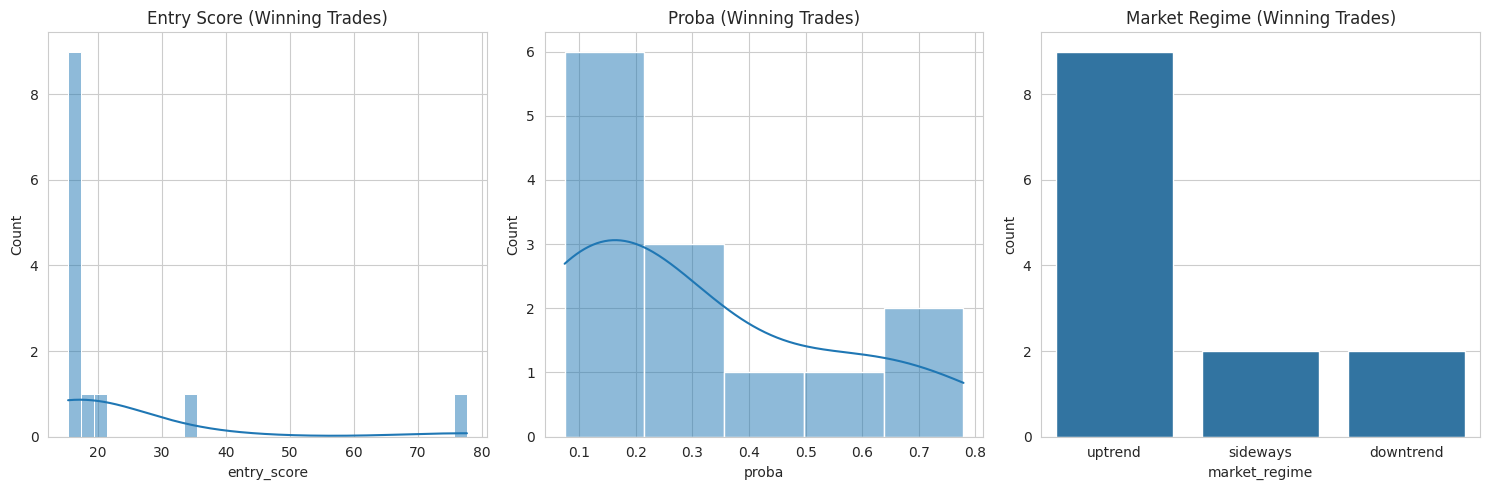

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Helper functions (re-defining or ensuring scope to avoid issues)
def calculate_profit_factor(pnls):
    gains = pnls[pnls > 0].sum()
    losses = abs(pnls[pnls < 0].sum())
    if losses == 0 and gains == 0: return np.nan
    return gains / (losses + 1e-9) if losses != 0 else np.inf

def calculate_sharpe_ratio(returns_pct):
    returns_pct = returns_pct.dropna()
    if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
        return np.nan
    return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

def calculate_max_dd_from_pnl(pnls_series, initial_balance=100000):
    if pnls_series.empty or len(pnls_series) < 2:
        return np.nan
    equity_curve = (pnls_series.cumsum() + initial_balance)
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9)
    return dd.min()


if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。OOS トレードログを作成する前のセルを実行してください。")
elif 'df_encoded' not in globals():
    print("エラー: df_encoded が見つかりません。データ取得のセルを実行してください。")
else:
    # 勝ちトレードをフィルタリング
    df_winning_trades_oos = df_regime_trades[df_regime_trades['pnl'] > 0].copy()

    if df_winning_trades_oos.empty:
        print("OOS期間に勝ちトレードが見つかりませんでした。")
    else:
        # df_encodedからエントリー時のテクニカル指標を取得
        df_winning_trades_oos['entry_date'] = pd.to_datetime(df_winning_trades_oos['entry_date'])
        df_encoded_indexed = df_encoded.set_index(pd.to_datetime(df_encoded.index))

        df_winning_trades_oos = df_winning_trades_oos.set_index('entry_date')
        df_winning_trades_oos['ADX'] = df_encoded_indexed['ADX'].reindex(df_winning_trades_oos.index)
        df_winning_trades_oos['SMA_diff_abs'] = df_encoded_indexed['SMA_diff_abs'].reindex(df_winning_trades_oos.index)
        df_winning_trades_oos['Volatility_Short'] = df_encoded_indexed['Volatility_Short'].reindex(df_winning_trades_oos.index)
        df_winning_trades_oos = df_winning_trades_oos.reset_index()

        print("\n===== OOS期間 勝ちトレード詳細 ====")
        display(df_winning_trades_oos[[
            'entry_date', 'exit_date', 'pnl', 'market_regime', 'entry_score', 'proba',
            'Volatility_Short', 'ADX', 'SMA_diff_abs', 'exit_type'
        ]].head())

        print("\n----- 勝ちトレードの市場レジーム分布 -----")
        display(df_winning_trades_oos['market_regime'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

        print("\n----- 勝ちトレードのエントリープロバビリティ/スコア -----")
        display(df_winning_trades_oos[['proba', 'entry_score']].describe())

        print("\n----- 勝ちトレードのボラティリティ・ADX・SMA差 (エントリー時) -----")
        display(df_winning_trades_oos[['Volatility_Short', 'ADX', 'SMA_diff_abs']].describe())

        # Visualize distributions for winning trades
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        sns.histplot(df_winning_trades_oos['entry_score'], kde=True)
        plt.title('Entry Score (Winning Trades)')

        plt.subplot(1, 3, 2)
        sns.histplot(df_winning_trades_oos['proba'], kde=True)
        plt.title('Proba (Winning Trades)')

        plt.subplot(1, 3, 3)
        sns.countplot(x='market_regime', data=df_winning_trades_oos)
        plt.title('Market Regime (Winning Trades)')
        plt.tight_layout()
        plt.show()


#### OOS期間の負けトレード詳細分析

OOS期間の負けトレードに焦点を当て、そのエントリー時の特徴量（`proba`, `entry_score`, `market_regime`, `Volatility_Short`, `ADX`, `SMA_diff_abs`）を詳細に分析します。これにより、どのような条件下でトレードが失敗しやすいかの共通パターンを特定し、将来の戦略改善に役立てます。


===== OOS期間 負けトレード詳細 ====


,entry_date,exit_date,pnl,market_regime,entry_score,proba,Volatility_Short,ADX,SMA_diff_abs,exit_type
0,2024-07-31,2024-08-08,-6097.922219,uptrend,28.801955,0.635993,0.040702,40.046484,35.802737,stop_loss
1,2026-03-17,2026-03-26,-956.698702,uptrend,15.352651,0.228664,0.020950,34.168413,58.833653,trailing_stop
2,2026-05-08,2026-05-18,-695.945295,uptrend,61.697262,0.219314,0.038608,74.697636,67.545519,trailing_stop



----- 負けトレードの市場レジーム分布 -----


,proportion
market_regime,
uptrend,100.0%



----- 負けトレードのエントリープロバビリティ/スコア -----


,proba,entry_score
count,3.000000,3.000000
mean,0.361324,35.283956
std,0.237916,23.842567
min,0.219314,15.352651
25%,0.223989,22.077303
50%,0.228664,28.801955
75%,0.432329,45.249608
max,0.635993,61.697262



----- 負けトレードのボラティリティ・ADX・SMA差 (エントリー時) -----


,Volatility_Short,ADX,SMA_diff_abs
count,3.000000,3.000000,3.000000
mean,0.033420,49.637511,54.060636
std,0.010850,21.900806,16.400833
min,0.020950,34.168413,35.802737
25%,0.029779,37.107449,47.318195
50%,0.038608,40.046484,58.833653
75%,0.039655,57.372060,63.189586
max,0.040702,74.697636,67.545519


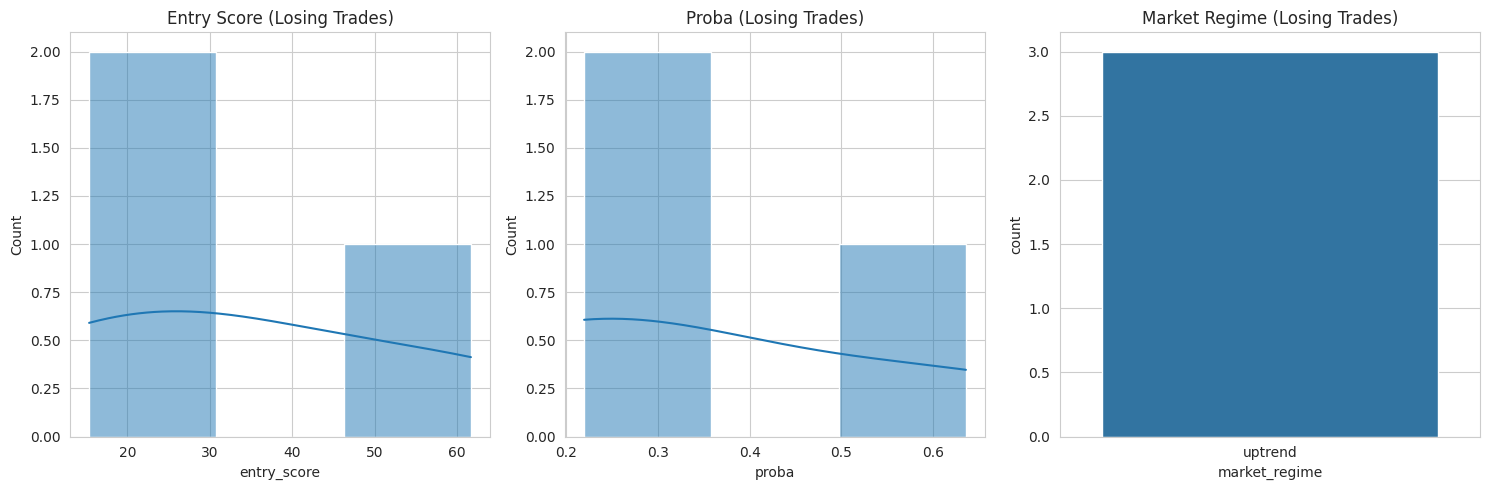

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Helper functions (re-defining or ensuring scope to avoid issues)
def calculate_profit_factor(pnls):
    gains = pnls[pnls > 0].sum()
    losses = abs(pnls[pnls < 0].sum())
    if losses == 0 and gains == 0: return np.nan
    return gains / (losses + 1e-9) if losses != 0 else np.inf

def calculate_sharpe_ratio(returns_pct):
    returns_pct = returns_pct.dropna()
    if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
        return np.nan
    return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

def calculate_max_dd_from_pnl(pnls_series, initial_balance=100000):
    if pnls_series.empty or len(pnls_series) < 2:
        return np.nan
    equity_curve = (pnls_series.cumsum() + initial_balance)
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9)
    return dd.min()


if 'df_regime_trades' not in globals() or df_regime_trades.empty:
    print("エラー: df_regime_trades が見つからないか空です。OOS トレードログを作成する前のセルを実行してください。")
elif 'df_encoded' not in globals():
    print("エラー: df_encoded が見つかりません。データ取得のセルを実行してください。")
else:
    # 負けトレードをフィルタリング
    df_losing_trades_oos = df_regime_trades[df_regime_trades['pnl'] < 0].copy()

    if df_losing_trades_oos.empty:
        print("OOS期間に負けトレードが見つかりませんでした。")
    else:
        # df_encodedからエントリー時のテクニカル指標を取得
        df_losing_trades_oos['entry_date'] = pd.to_datetime(df_losing_trades_oos['entry_date'])
        df_encoded_indexed = df_encoded.set_index(pd.to_datetime(df_encoded.index))

        df_losing_trades_oos = df_losing_trades_oos.set_index('entry_date')
        df_losing_trades_oos['ADX'] = df_encoded_indexed['ADX'].reindex(df_losing_trades_oos.index)
        df_losing_trades_oos['SMA_diff_abs'] = df_encoded_indexed['SMA_diff_abs'].reindex(df_losing_trades_oos.index)
        df_losing_trades_oos['Volatility_Short'] = df_encoded_indexed['Volatility_Short'].reindex(df_losing_trades_oos.index)
        df_losing_trades_oos = df_losing_trades_oos.reset_index()

        print("\n===== OOS期間 負けトレード詳細 ====")
        display(df_losing_trades_oos[[
            'entry_date', 'exit_date', 'pnl', 'market_regime', 'entry_score', 'proba',
            'Volatility_Short', 'ADX', 'SMA_diff_abs', 'exit_type'
        ]].head())

        print("\n----- 負けトレードの市場レジーム分布 -----")
        display(df_losing_trades_oos['market_regime'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

        print("\n----- 負けトレードのエントリープロバビリティ/スコア -----")
        display(df_losing_trades_oos[['proba', 'entry_score']].describe())

        print("\n----- 負けトレードのボラティリティ・ADX・SMA差 (エントリー時) -----")
        display(df_losing_trades_oos[['Volatility_Short', 'ADX', 'SMA_diff_abs']].describe())

        # Visualize distributions for losing trades
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        sns.histplot(df_losing_trades_oos['entry_score'], kde=True)
        plt.title('Entry Score (Losing Trades)')

        plt.subplot(1, 3, 2)
        sns.histplot(df_losing_trades_oos['proba'], kde=True)
        plt.title('Proba (Losing Trades)')

        plt.subplot(1, 3, 3)
        sns.countplot(x='market_regime', data=df_losing_trades_oos)
        plt.title('Market Regime (Losing Trades)')
        plt.tight_layout()
        plt.show()


#### 全てのフォールドのトレード詳細分析

ここからは、クロスバリデーションの全フォールドにわたる勝ちトレードと負けトレードの`proba`と`entry_score`を分析します。これにより、これらのパラメータの適切な境界を特定し、戦略の改善に役立てます。


===== 全フォールド 勝ちトレードのエントリープロバビリティ/スコア ====


,proba,entry_score
count,17.000000,17.000000
mean,0.433429,21.871646
std,0.285704,11.936215
min,0.075303,15.359558
25%,0.223756,16.122605
50%,0.353075,16.872603
75%,0.636099,19.231486
max,0.963685,59.814887



===== 全フォールド 負けトレードのエントリープロバビリティ/スコア ====


,proba,entry_score
count,4.000000,4.000000
mean,0.453205,29.996016
std,0.413225,20.960459
min,0.083115,15.101025
25%,0.104819,15.765885
50%,0.433094,22.453800
75%,0.781479,36.683931
max,0.863519,59.975440


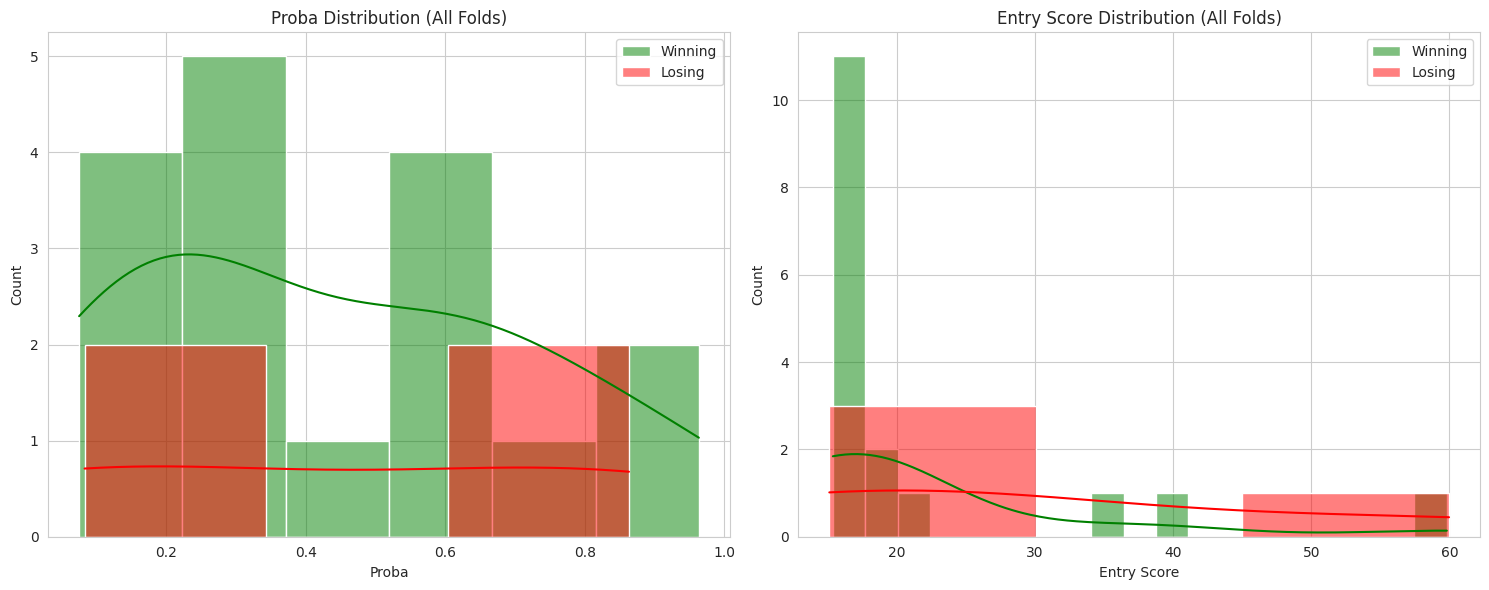

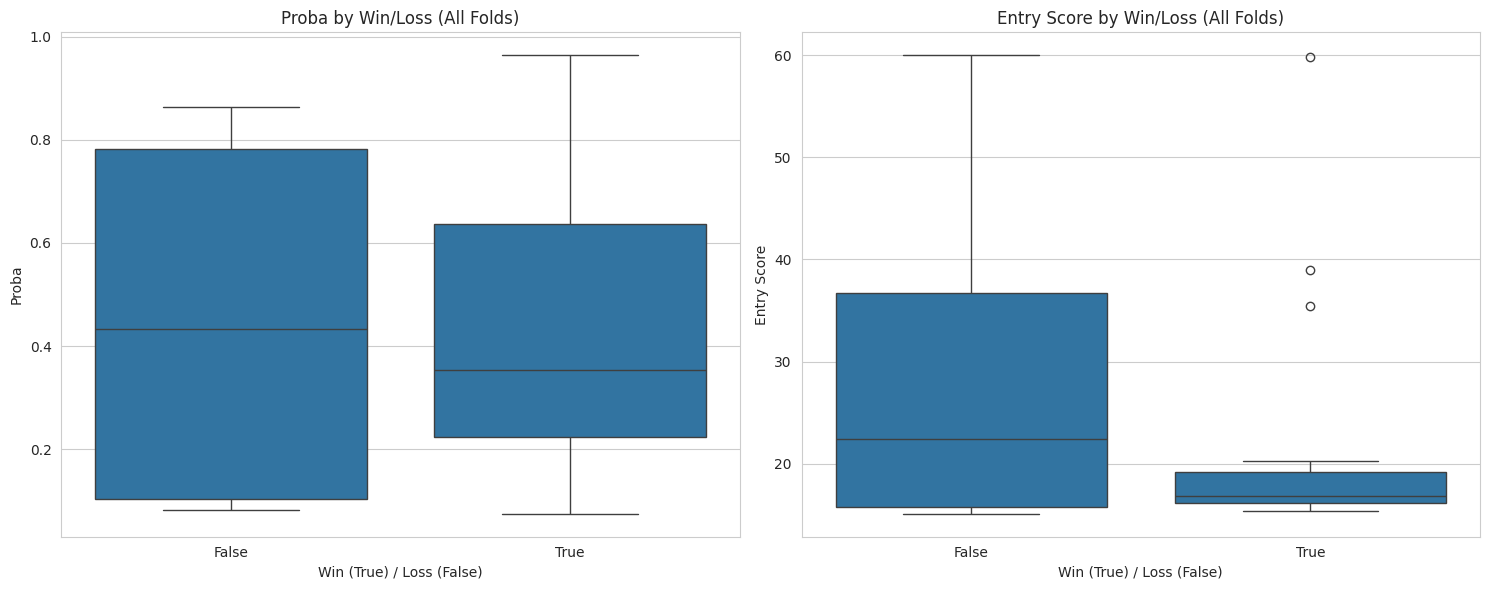

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Helper functions (re-defining or ensuring scope to avoid issues)
def calculate_profit_factor(pnls):
    gains = pnls[pnls > 0].sum()
    losses = abs(pnls[pnls < 0].sum())
    if losses == 0 and gains == 0: return np.nan
    return gains / (losses + 1e-9) if losses != 0 else np.inf

def calculate_sharpe_ratio(returns_pct):
    returns_pct = returns_pct.dropna()
    if returns_pct.empty or len(returns_pct) < 2 or returns_pct.std() == 0:
        return np.nan
    return returns_pct.mean() / (returns_pct.std() + 1e-9) * np.sqrt(252)

def calculate_max_dd_from_pnl(pnls_series, initial_balance=100000):
    if pnls_series.empty or len(pnls_series) < 2:
        return np.nan
    equity_curve = (pnls_series.cumsum() + initial_balance)
    peak = equity_curve.expanding(min_periods=1).max()
    dd = (equity_curve - peak) / (peak + 1e-9)
    return dd.min()


if 'trade_logs_for_plotting' not in globals() or not trade_logs_for_plotting:
    print("エラー: 'trade_logs_for_plotting' が見つからないか空です。クロスバリデーション分析セルが実行されていることを確認してください。")
else:
    # 全フォールドのトレードログを結合
    all_trades = pd.concat([pd.DataFrame(log) for log in trade_logs_for_plotting], ignore_index=True)

    if all_trades.empty:
        print("全フォールドのトレードログが空です。")
    else:
        # 勝ちトレードと負けトレードをフィルタリング
        winning_trades_all_folds = all_trades[all_trades['pnl'] > 0].copy()
        losing_trades_all_folds = all_trades[all_trades['pnl'] < 0].copy()

        print("\n===== 全フォールド 勝ちトレードのエントリープロバビリティ/スコア ====")
        if not winning_trades_all_folds.empty:
            display(winning_trades_all_folds[['proba', 'entry_score']].describe())
        else:
            print("全フォールドで勝ちトレードが見つかりませんでした。")

        print("\n===== 全フォールド 負けトレードのエントリープロバビリティ/スコア ====")
        if not losing_trades_all_folds.empty:
            display(losing_trades_all_folds[['proba', 'entry_score']].describe())
        else:
            print("全フォールドで負けトレードが見つかりませんでした。")

        # Visualize distributions for all trades
        plt.figure(figsize=(15, 6))

        plt.subplot(1, 2, 1)
        sns.histplot(winning_trades_all_folds['proba'], color='green', label='Winning', kde=True)
        sns.histplot(losing_trades_all_folds['proba'], color='red', label='Losing', kde=True)
        plt.title('Proba Distribution (All Folds)')
        plt.xlabel('Proba')
        plt.legend()

        plt.subplot(1, 2, 2)
        sns.histplot(winning_trades_all_folds['entry_score'], color='green', label='Winning', kde=True)
        sns.histplot(losing_trades_all_folds['entry_score'], color='red', label='Losing', kde=True)
        plt.title('Entry Score Distribution (All Folds)')
        plt.xlabel('Entry Score')
        plt.legend()

        plt.tight_layout()
        plt.show()

        # Additional visualization: Box plots for better comparison
        plt.figure(figsize=(15, 6))

        plt.subplot(1, 2, 1)
        sns.boxplot(x='win', y='proba', data=all_trades.assign(win=all_trades['pnl'] > 0))
        plt.title('Proba by Win/Loss (All Folds)')
        plt.xlabel('Win (True) / Loss (False)')
        plt.ylabel('Proba')

        plt.subplot(1, 2, 2)
        sns.boxplot(x='win', y='entry_score', data=all_trades.assign(win=all_trades['pnl'] > 0))
        plt.title('Entry Score by Win/Loss (All Folds)')
        plt.xlabel('Win (True) / Loss (False)')
        plt.ylabel('Entry Score')

        plt.tight_layout()
        plt.show()


In [59]:
# ===== TP関連パラメータ残存チェック =====

print("===== best_params.json チェック =====")

try:
    import json

    with open('/content/drive/MyDrive/optuna_trading/best_params.json', 'r') as f:
        params = json.load(f)

    tp_keys = [
        'atr_tp_multiplier',
        'atr_tp_multiplier_uptrend',
        'atr_tp_multiplier_downtrend',
        'atr_tp_multiplier_sideways',
        'profit_take_threshold_atr_multiplier',
        'graduated_trail_ratio',
        'partial_profit_take_ratio'
    ]

    found = False

    for k in tp_keys:
        if k in params:
            found = True
            print(f"❌ TPパラメータ残存: {k} = {params[k]}")

    if not found:
        print("✅ best_params.json にTPパラメータは存在しません")

except Exception as e:
    print("best_params.json 読み込み失敗:", e)

print("\n===== study.best_trial.params チェック =====")

try:
    tp_keys = [
        'atr_tp_multiplier',
        'atr_tp_multiplier_uptrend',
        'atr_tp_multiplier_downtrend',
        'atr_tp_multiplier_sideways',
        'profit_take_threshold_atr_multiplier',
        'graduated_trail_ratio',
        'partial_profit_take_ratio'
    ]

    found = False

    for k in tp_keys:
        if k in study.best_trial.params:
            found = True
            print(f"❌ TPパラメータ残存: {k} = {study.best_trial.params[k]}")

    if not found:
        print("✅ study.best_trial.params にTPパラメータは存在しません")

except Exception as e:
    print("study確認失敗:", e)

print("\n===== 現在のExit Type確認 =====")

try:
    print(df_combined_trades["Exit Type"].value_counts())
except Exception as e:
    print("df_combined_trades未生成:", e)

===== best_params.json チェック =====
✅ best_params.json にTPパラメータは存在しません

===== study.best_trial.params チェック =====
✅ study.best_trial.params にTPパラメータは存在しません

===== 現在のExit Type確認 =====
df_combined_trades未生成: 'Exit Type'


In [60]:
print(df_combined_trades["exit_type"].value_counts())

exit_type
trailing_stop    8
Name: count, dtype: int64


In [62]:
import pandas as pd
import numpy as np

# Ensure df_encoded is correctly indexed by datetime
df_encoded.index = pd.to_datetime(df_encoded.index)

# Prepare to collect all trade entry features across folds
all_trades_features = []

if 'trade_logs_for_plotting' not in globals() or not trade_logs_for_plotting:
    print("Error: 'trade_logs_for_plotting' not found or is empty. Please ensure cross-validation analysis cells are run.")
else:
    for i, fold_trade_log in enumerate(trade_logs_for_plotting):
        if fold_trade_log:
            df_trades_fold = pd.DataFrame(fold_trade_log)
            df_trades_fold['entry_date'] = pd.to_datetime(df_trades_fold['entry_date'])
            df_trades_fold['fold_number'] = i + 1

            # Merge with df_encoded to get feature values at entry date
            # Use .loc with .index.isin to handle cases where entry_date might not perfectly align
            # or to avoid multiple joins if already indexed.
            # Let's reindex df_encoded to match trade entry dates
            df_features_at_entry = df_encoded.loc[df_trades_fold['entry_date'], [
                'SMA_diff_abs', 'SMA_diff_pct', 'MOMENTUM_pct'
            ]].copy()

            # Add fold number to the features DataFrame
            df_features_at_entry['fold_number'] = df_trades_fold['fold_number'].values

            all_trades_features.append(df_features_at_entry)

if all_trades_features:
    df_all_trades_features = pd.concat(all_trades_features)

    # Separate into folds 1-9 and fold 10
    df_folds_1_9 = df_all_trades_features[df_all_trades_features['fold_number'] <= 9].copy()
    df_fold_10 = df_all_trades_features[df_all_trades_features['fold_number'] == 10].copy()

    features_to_compare = ['SMA_diff_abs', 'SMA_diff_pct', 'MOMENTUM_pct']

    print("\n===== Feature Distribution Comparison (Folds 1-9 vs. Fold 10) ====")

    for feature in features_to_compare:
        print(f"\n--- {feature} ---")
        print("Folds 1-9 Statistics:")
        display(df_folds_1_9[feature].describe())
        print("\nFold 10 Statistics:")
        display(df_fold_10[feature].describe())

    print("\nAnalysis complete. Compare the statistics above to identify any significant differences.")
else:
    print("No trade features could be collected for analysis.")


===== Feature Distribution Comparison (Folds 1-9 vs. Fold 10) ====

--- SMA_diff_abs ---
Folds 1-9 Statistics:


,SMA_diff_abs
count,14.000000
mean,16.335445
std,11.233388
min,0.302681
25%,8.548732
50%,14.618105
75%,22.807105
max,35.802737



Fold 10 Statistics:


,SMA_diff_abs
count,7.000000
mean,59.023580
std,8.549605
min,51.122816
25%,54.088359
50%,55.795095
75%,60.832204
max,76.406024



--- SMA_diff_pct ---
Folds 1-9 Statistics:


...


--- MOMENTUM_pct ---
Folds 1-9 Statistics:


,MOMENTUM_pct
count,14.000000
mean,0.028900
std,0.052683
min,-0.066373
25%,-0.007201
50%,0.032330
75%,0.064472
max,0.112820



Fold 10 Statistics:


,MOMENTUM_pct
count,7.000000
mean,0.024816
std,0.073231
min,-0.083903
25%,-0.017246
50%,0.004869
75%,0.088424
max,0.110389



Analysis complete. Compare the statistics above to identify any significant differences.


In [63]:
print("フィルター前:", len(candidate_signals))
print("ADX通過:", len(after_adx))
print("score通過:", len(after_score))
print("proba通過:", len(after_proba))

NameError: name 'candidate_signals' is not defined